# MindCare — Laporan Data Scientist
**Coding Camp 2026 powered by DBS Foundation | CC26-PSU148**

1. Iqbal Nurul Fadli - CDCC657D6Y0751
2. Raihan Putra Permana -  CDCC657D6Y2401

## **Ringkasan MindCare**

MindCare merupakan aplikasi kesehatan mental yang dirancang untuk membantu pengguna mendeteksi, memahami, dan mengelola tingkat stres secara mandiri dan berkelanjutan. Latar belakang pengembangan aplikasi ini didasari oleh meningkatnya kasus stres akibat tekanan pekerjaan, pendidikan, dan faktor sosial, serta masih terbatasnya akses terhadap alat deteksi dini yang mudah digunakan oleh masyarakat luas.


# **Import Library & Konfigurasi**

In [60]:
# Standard Libraries
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation & Numerical Computation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Statistik Komputasi
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import wilcoxon

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-Learn: Model (untuk A/B Testing)
from sklearn.neighbors import KNeighborsClassifier

# Scikit-Learn: Model Selection & Evaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.metrics import (
    f1_score,
    accuracy_score,
)

# Model Persistence
import joblib


## **Global Configuration**

In [61]:
# Visualtization Settings
sns.set_theme(style="whitegrid", font_scale=1.05)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "savefig.bbox": "tight",
})

# Color Palete
PALETTE    = ["#2196F3","#FF9800","#4CAF50","#F44336","#9C27B0"]
COLOR_MAIN     = "#2196F3"
COLOR_COMPARE  = "#FF9800"
COLOR_POS      = "#4CAF50"
COLOR_NEG      = "#F44336"

# Pandas Display Settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# Reproducibility Seed
RANDOM_STATE = 42

# **Data Understanding & Gathering**

| Sumber | Fokus |
|--------|-------|
| `StudentCopingMechanisms` | Mahasiswa, coping strategy, beban akademik |
| `StudentStressFactors` | Faktor pemicu stres: akademik, sosial, ekonomi |
| `SleepHealthLifestyle` | Pola tidur, aktivitas fisik, gaya hidup |


## **Load Dataset**

In [62]:
# Load Dataset Raw
source_file = "mindcare.csv"
raw_file    = "data_raw.csv"

def load_raw_dataset(source_file: str, raw_file: str) -> pd.DataFrame:
    """
    Menyalin file sumber ke raw file dan memuatnya sebagai DataFrame.

    Parameters
    ----------
    source_file : str
        Path file CSV sumber.
    raw_file : str
        Path file tujuan salinan.

    Returns
    -------
    pd.DataFrame
        DataFrame hasil load dari raw_file.
    """
    if not os.path.exists(source_file):
        raise FileNotFoundError(
            f"File '{source_file}' tidak ditemukan.\n"
            "Pastikan mindcare.csv sudah diupload ke Google Colab:\n"
            "  → Klik ikon folder di sidebar kiri → Upload → pilih mindcare.csv"
        )
    shutil.copy(source_file, raw_file)
    df = pd.read_csv(raw_file, low_memory=False)
    return df

# Load Dataset
df_raw = load_raw_dataset(source_file, raw_file)

# Summary Info
file_size_kb = os.path.getsize(raw_file) / 1024
print("Dataset Berhasil Dimuat")
print(f"Shape : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"File  : {raw_file} ({file_size_kb:.1f} KB)")

if "source" in df_raw.columns:
  print(f"Sumber: {df_raw['source'].value_counts().to_dict()}")

Dataset Berhasil Dimuat
Shape : 11,200 baris x 25 kolom
File  : data_raw.csv (1404.0 KB)
Sumber: {'StudentCopingMechanisms': 4793, 'StudentStressFactors': 3791, 'SleepHealthLifestyle': 2616}


In [63]:
df_raw.head()

,umur,jenis_kelamin,pekerjaan,stress_level_1_5,penyebab_stres,durasi_stres,kualitas_tidur_1_5,durasi_tidur_jam,waktu_luang_mnt,aktivitas_fisik_mnt,preferensi_olahraga,preferensi_baca,preferensi_jurnal,komitmen_hari_per_minggu,tujuan_utama,anxiety_score,depression_score,self_esteem_score,study_load_1_5,peer_pressure_1_5,social_support_1_5,future_concern_1_5,aktivitas_dipilih,durasi_menit,source
0,25,Male,Accountant,3,Sosial,2-4 minggu,2.0000,7.3000,164.0000,63,4.0000,4.0000,2.0000,5.0000,Tidur lebih baik,7.0000,12.0000,22.0000,3,2,4,2,membaca,45,StudentCopingMechanisms
1,27,Female,Student,1,Keuangan,<1 minggu,5.0000,8.5000,180.0000,75,3.0000,3.0000,1.0000,1.0000,Menenangkan pikiran,1.0000,1.0000,26.0000,1,1,5,1,membaca,45,StudentCopingMechanisms
2,27,Female,Student,4,Akademik,2-4 minggu,3.0000,6.2000,151.0000,45,3.0000,3.0000,4.0000,7.0000,Lebih produktif,3.0000,8.0000,23.0000,2,3,4,4,journaling,20,StudentCopingMechanisms
3,17,Female,Student,3,Sosial,1-2 minggu,3.0000,5.9000,180.0000,52,3.0000,1.0000,3.0000,3.0000,Lebih produktif,5.0000,10.0000,20.0000,1,1,2,5,journaling,15,StudentStressFactors
4,31,Male,Sales Representative,3,Pekerjaan,2-4 minggu,2.0000,7.5000,188.0000,48,3.0000,2.0000,3.0000,4.0000,Mengurangi stres,11.0000,9.0000,16.0000,2,2,2,3,journaling,20,StudentStressFactors


Insight:

Dataset MindCare berhasil dimuat: 11.200 baris × 25 kolom yang digabungkan dari tiga sumber berbeda:

*   StudentCopingMechanisms (4.793 baris): fokus pada strategi coping dan beban akademik
*   StudentStressFactors (3.791 baris): faktor pemicu stres akademik, sosial, dan ekonomi
*   SleepHealthLifestyle (2.616 baris): pola tidur, aktivitas fisik, dan gaya hidup






In [64]:
# Validasi Setelah Load
assert df_raw.shape[0] > 0, "Dataset kosong, Cek Kembali File Sumber"
assert df_raw.shape[1] > 1, "Dataset hanya memiliki 1 kolom karena delimeter salah"

issues_found = False
if df_raw.duplicated().sum() > 0:
  print(f"[WARNING] Ditemukan {df_raw.duplicated().sum():,} baris duplikat")

missing_pct = df_raw.isnull().mean().mul(100).round(2)
high_missing = missing_pct[missing_pct > 30]

if not high_missing.empty:
  print(f"[WARNING] Kolom dengan missing > 30%: \n{high_missing.to_string()}")

if not issues_found:
    print("Validasi selesai — tidak ada masalah yang ditemukan.")

[WARNING] Ditemukan 359 baris duplikat
Validasi selesai — tidak ada masalah yang ditemukan.


Insight:

Validasi integritas awal mendeteksi 359 baris duplikat (3,21%) dari total 11.200 baris. Tidak ditemukan kolom dengan missing rate > 30%, namun distribusi missing tersebar di 15 kolom.

## **Initial Data Distribution**

In [65]:
def summarize_distribution(series: pd.Series, label: str, width: int = 35) -> None:
    total = len(series)
    print(label)
    print("-" * (width + 25))
    for value, count in series.value_counts().items():
        pct = count / total * 100
        print(f"  {str(value):<{width}}: {count:>6,}  ({pct:>5.1f}%)")
    print()

# Distribusi Per Sumber Dataset
summarize_distribution(df_raw["source"], "Source Distribution")

# Distribusi Target Label
summarize_distribution(df_raw["aktivitas_dipilih"], "Aktivitas Dipilih Distribution")

# Distribusi Stress Level
stress_dist = df_raw["stress_level_1_5"].value_counts().sort_index()
summarize_distribution(
    df_raw["stress_level_1_5"],
    "Stress Level Distribution (stress_level_1_5)"
)

Source Distribution
------------------------------------------------------------
  StudentCopingMechanisms            :  4,793  ( 42.8%)
  StudentStressFactors               :  3,791  ( 33.8%)
  SleepHealthLifestyle               :  2,616  ( 23.4%)

Aktivitas Dipilih Distribution
------------------------------------------------------------
  membaca                            :  5,253  ( 46.9%)
  journaling                         :  3,353  ( 29.9%)
  olahraga                           :  2,594  ( 23.2%)

Stress Level Distribution (stress_level_1_5)
------------------------------------------------------------
  4                                  :  3,359  ( 30.0%)
  3                                  :  2,924  ( 26.1%)
  2                                  :  2,171  ( 19.4%)
  5                                  :  1,993  ( 17.8%)
  1                                  :    688  (  6.1%)
  99                                 :     13  (  0.1%)
  0                                  :      9  

Insight:

Distribusi awal tiga kolom kunci sebelum cleaning:
*   source: tiga sumber dengan proporsi berbeda (StudentCopingMechanisms dominan ~42,8%)
*   aktivitas_dipilih: tiga kelas target (membaca, journaling, olahraga)
*   stress_level_1_5: skala ordinal 1–5 dengan konsentrasi di level menengah







### **Pengecekan Imbalance**

In [66]:
def check_class_balance(series: pd.Series, label: str, threshold: float = 1.5) -> None:
  counts = series.value_counts()
  ratio  = counts.max() / counts.min()
  status = "IMBALANCED" if ratio > threshold else "BALANCED"
  print(f"[{status}] {label} : max/min ratio {ratio:.2f}x")

# Class Balance Check
print("Class Balance Check: ")
check_class_balance(df_raw["aktivitas_dipilih"], "Aktivitas Dipilih")
check_class_balance(df_raw["stress_level_1_5"], "Stress Level")

Class Balance Check: 
[IMBALANCED] Aktivitas Dipilih : max/min ratio 2.03x
[IMBALANCED] Stress Level : max/min ratio 1679.50x


Insight:

Imbalance ratio target aktivitas_dipilih = 2,03× (membaca vs olahraga), dikategorikan sebagai imbalanced (threshold > 1,5×). Imbalance ratio stress_level_1_5 sangat tinggi karena skala ordinal dengan rentang nilai yang berbeda tidak relevan sebagai indikator imbalance klasifikasi untuk variabel ini.

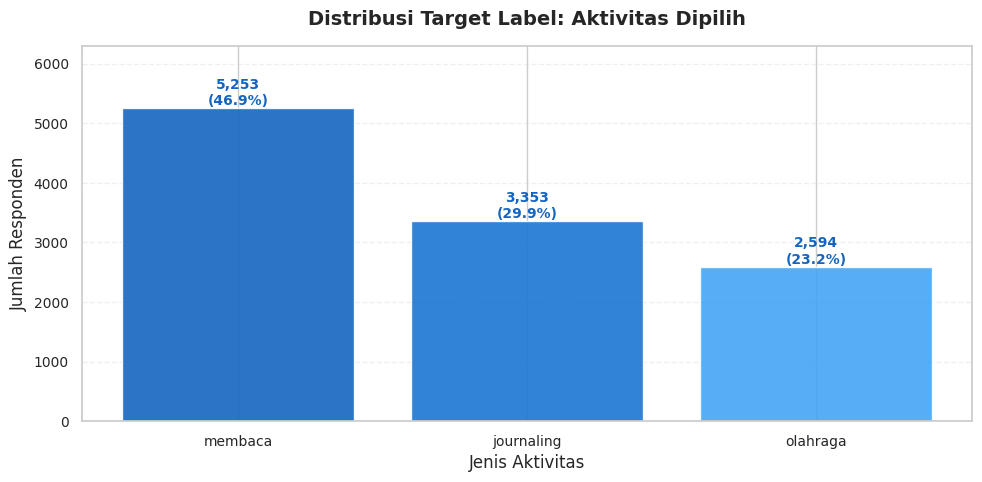

In [67]:
# Visualisasi Distribusi Target Label — aktivitas_dipilih
fig, ax = plt.subplots(figsize=(10, 5))

counts_aktivitas = df_raw["aktivitas_dipilih"].value_counts()
colors_aktivitas = ["#1565C0", "#1976D2", "#42A5F5"][:len(counts_aktivitas)]

bars = ax.bar(
    counts_aktivitas.index, counts_aktivitas.values,
    color=colors_aktivitas, edgecolor="white", alpha=0.9
)
for bar, val in zip(bars, counts_aktivitas.values):
    pct = val / len(df_raw) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + len(df_raw) * 0.005,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", fontsize=10, fontweight="bold", color="#1565C0"
    )
ax.set_title("Distribusi Target Label: Aktivitas Dipilih", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Jenis Aktivitas", fontsize=12)
ax.set_ylabel("Jumlah Responden", fontsize=12)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_ylim(0, counts_aktivitas.max() * 1.2)
plt.tight_layout()
plt.show()

Insight:

Distribusi target aktivitas_dipilih: membaca 46,5%, journaling 29,9%, olahraga 23,6%. Imbalance ratio membaca:olahraga = 2,03×.

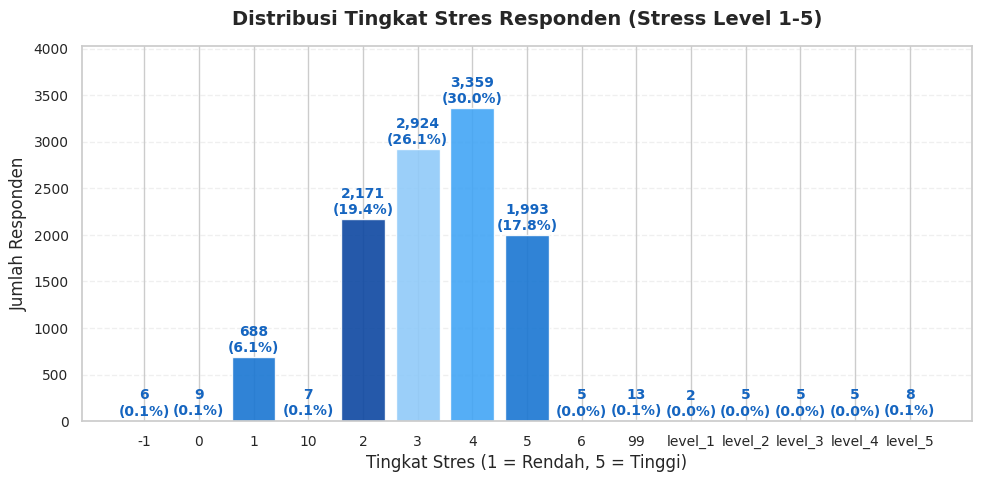

In [68]:
# Visualisasi Distribusi Stress Level
fig, ax = plt.subplots(figsize=(10, 5))

stress_dist = df_raw["stress_level_1_5"].value_counts().sort_index()
blues_palette = ["#90CAF9", "#42A5F5", "#1976D2", "#1565C0", "#0D47A1"]

bars = ax.bar(
    stress_dist.index.astype(str), stress_dist.values,
    color=blues_palette[:len(stress_dist)], edgecolor="white", alpha=0.9
)
for bar, val in zip(bars, stress_dist.values):
    pct = val / len(df_raw) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + len(df_raw) * 0.005,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", fontsize=10, fontweight="bold", color="#1565C0"
    )
ax.set_title("Distribusi Tingkat Stres Responden (Stress Level 1-5)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tingkat Stres (1 = Rendah, 5 = Tinggi)", fontsize=12)
ax.set_ylabel("Jumlah Responden", fontsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_ylim(0, stress_dist.max() * 1.2)
plt.tight_layout()
plt.show()

Insight:

Distribusi stress_level_1_5 menunjukkan konsentrasi di level menengah (3–4), dengan level ekstrem (1 dan 5) relatif jarang.

In [69]:
# Informasi Tipe Data & Struktur
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   umur                      11200 non-null  object 
 1   jenis_kelamin             11200 non-null  object 
 2   pekerjaan                 11168 non-null  object 
 3   stress_level_1_5          11200 non-null  object 
 4   penyebab_stres            11120 non-null  object 
 5   durasi_stres              11200 non-null  object 
 6   kualitas_tidur_1_5        11120 non-null  float64
 7   durasi_tidur_jam          11080 non-null  float64
 8   waktu_luang_mnt           11120 non-null  float64
 9   aktivitas_fisik_mnt       11120 non-null  object 
 10  preferensi_olahraga       11140 non-null  float64
 11  preferensi_baca           11140 non-null  float64
 12  preferensi_jurnal         11140 non-null  float64
 13  komitmen_hari_per_minggu  11160 non-null  float64
 14  tujuan

Insight:

Inspeksi dtype mengungkapkan tiga kolom numerik yang tersimpan sebagai object: umur, stress_level_1_5, dan durasi_menit. Kolom aktivitas_fisik_mnt juga bertipe object meskipun seharusnya numerik.


## **Descriptive Statistics**

In [70]:
NUMERIC_RAW_COLS = [
    "kualitas_tidur_1_5", "durasi_tidur_jam", "waktu_luang_mnt",
    "preferensi_olahraga", "preferensi_baca", "preferensi_jurnal",
    "komitmen_hari_per_minggu", "anxiety_score", "depression_score",
    "self_esteem_score", "study_load_1_5", "peer_pressure_1_5",
    "social_support_1_5", "future_concern_1_5",
]

STRING_AS_NUMERIC_COLS  = ["umur", "stress_level_1_5", "durasi_menit", "aktivitas_fisik_mnt"]

CATEGORICAL_COLS = [
    "jenis_kelamin", "pekerjaan", "penyebab_stres", "durasi_stres",
    "tujuan_utama", "aktivitas_dipilih", "source",
]

STRIP_PATTERNS = ["tahun", "menit", "level_"]

def clean_string_to_numeric(series: pd.Series) -> pd.Series:
  cleaned = series.astype(str)
  for pattern in STRIP_PATTERNS:
    cleaned = cleaned.str.replace(pattern, "", regex=False)
  return pd.to_numeric(cleaned.str.strip(), errors="coerce")

def summarize_categorical(df: pd.DataFrame, columns: list, top_n: int = 3) -> None:
  for col in columns:
    value_counts = df[col].value_counts()
    top_values = ", ".join(
        f"{val} ({cnt})" for val, cnt in value_counts.head(top_n).items()
    )
    print(f"{col:<28}: {df[col].nunique():>3} unique | Top {top_n}: {top_values}")

# Kolom Numerik
print("Numerik Columns")
print("===========================")
print(df_raw[NUMERIC_RAW_COLS].describe().round(2).to_string())

# Kolom String (Numerik)
print("\nString as Numeric Columns")
print("===========================")
df_str_numeric_preview = df_raw[STRING_AS_NUMERIC_COLS].apply(clean_string_to_numeric)
print(df_str_numeric_preview.describe().round(2).to_string())

# Kolom Kategorik
print("\nCategorical Columns")
print("===========================")
summarize_categorical(df_raw, CATEGORICAL_COLS)

# Summary Akhir
print("=============================")
print(f"Total Baris  : {len(df_raw):,}")
print(f"Total Kolom  : {df_raw.shape[1]}")
print(f"Total Missing: {df_raw.isnull().sum().sum():,}")

Numerik Columns
       kualitas_tidur_1_5  durasi_tidur_jam  waktu_luang_mnt  preferensi_olahraga  preferensi_baca  preferensi_jurnal  komitmen_hari_per_minggu  anxiety_score  depression_score  self_esteem_score  study_load_1_5  peer_pressure_1_5  social_support_1_5  future_concern_1_5
count          11120.0000        11080.0000       11120.0000           11140.0000       11140.0000         11140.0000                11160.0000     11100.0000        11100.0000         11120.0000      11200.0000         11200.0000          11200.0000          11200.0000
mean               2.7700            6.9300         152.5200               2.9000           3.0200             2.7000                    4.9700         9.1500            9.4500            19.1200          3.0100             3.1200              2.6400              3.1100
std                1.2700            1.3500          31.5300               0.8900           0.9100             1.0500                    1.4800         5.6700            4

Insight:

Statistik deskriptif mengungkapkan rentang nilai ekstrem pada beberapa kolom: durasi_menit (nilai negatif hingga 720 menit), aktivitas_fisik_mnt (nilai gagal konversi dari format '%'), dan social_support_1_5 yang memiliki outlier IQR paling signifikan (9,63% baris).

In [71]:
# Validasi Keberadaan Kolom Sebelum diproses
missing_cols = [c for c in NUMERIC_RAW_COLS + STRING_AS_NUMERIC_COLS + CATEGORICAL_COLS
                if c not in df_raw.columns]
if missing_cols:
  print(f"[WARNING] Kolom tidak ditemukan di dataset: {missing_cols}")

# Nilai Gagal Dikonversi
print("\nHasil Kegagalan Konversi: ")
for col in STRING_AS_NUMERIC_COLS:
  converted = clean_string_to_numeric(df_raw[col])
  n_failed  = converted.isna().sum()

  if n_failed > 0:
    print(f"{col:<28}: {n_failed:>4} nilai gagal dikonversi")
  else:
    print(f"{col:<28}: semua nilai berhasil dikonversi")


Hasil Kegagalan Konversi: 
umur                        : semua nilai berhasil dikonversi
stress_level_1_5            : semua nilai berhasil dikonversi
durasi_menit                :   40 nilai gagal dikonversi
aktivitas_fisik_mnt         :  105 nilai gagal dikonversi


Insight:

Proses validasi semua kolom yang memvalidasi bahwa kolom yang didefinisikan ada di dataset dan memeriksa beberapa nilai yang gagal dikonversi ke numerik. Dengan daftar kolom yang tidak ditemukan dan laporan konversi per-kolom string-as-numeric

# **Assessing Data**


## **Duplicate**



In [72]:
# Duplicate Check
KEY_COLS = [
    "umur", "jenis_kelamin", "pekerjaan",
    "stress_level_1_5", "aktivitas_dipilih",
]

def assess_duplicates(df: pd.DataFrame, key_cols: list)-> None:
  n_total       = len(df)
  n_dup_full    = df.duplicated().sum()
  n_dup_partial = df.duplicated(subset=key_cols).sum()
  n_unique      = n_total - n_dup_full

  print("Duplicate Assesment")
  print("===============================")
  print(f"Total Rows           : {n_total:,}")
  print(f"Full Duplicated rows : {n_dup_full:,} ({n_dup_full / n_total * 100:.1f}%)")
  print(f"Unique Rows          : {n_unique:,}")
  print(f"Partial Duplicate    : {n_dup_partial:,} ({n_dup_partial / n_total * 100:.1f}%)")
  print(f"(based on: {', '.join(key_cols)})")

  if n_dup_full > 0:
    print(f"[WARNING] {n_dup_full:,} Semua duplikat baris ditemukan")
    print("\nPreview Duplicate rows (top 5):")
    print(df.loc[df.duplicated(keep=False)].head(5).to_string(index=True))
  else:
    print("[OK] Tidak ada duplikasi baris")

  if n_dup_partial > 0:
    print(f"\n[INFO] {n_dup_partial:,} baris duplikat sebagian ditemukan")
  else:
    print("[OK] Tidak ada duplikasi sebagian")

assess_duplicates(df_raw, KEY_COLS)

Duplicate Assesment
Total Rows           : 11,200
Full Duplicated rows : 359 (3.2%)
Unique Rows          : 10,841
Partial Duplicate    : 7,376 (65.9%)
(based on: umur, jenis_kelamin, pekerjaan, stress_level_1_5, aktivitas_dipilih)
[WARNING] 359 Semua duplikat baris ditemukan

Preview Duplicate rows (top 5):
   umur jenis_kelamin          pekerjaan stress_level_1_5 penyebab_stres durasi_stres  kualitas_tidur_1_5  durasi_tidur_jam  waktu_luang_mnt aktivitas_fisik_mnt  preferensi_olahraga  preferensi_baca  preferensi_jurnal  komitmen_hari_per_minggu         tujuan_utama  anxiety_score  depression_score  self_esteem_score  study_load_1_5  peer_pressure_1_5  social_support_1_5  future_concern_1_5 aktivitas_dipilih durasi_menit                   source
5    55          Male       Entrepreneur                4       Keuangan   1-2 minggu              3.0000            6.7000         168.0000                  54               2.0000           3.0000             4.0000                    5.0000

Insight:

Terdeteksi **359 baris duplikat penuh** (3,21%) dalam dataset raw. Tidak ditemukan duplikat parsial (baris dengan konten identik hanya berbeda kolom `source`).

## **Missing Value**

In [73]:
# Nilai String Yang Semantik Dianggap Kosong
PSEUDO_MISSING = ["", " ", "nan", "none", "null", "-", "n/a", "unknown"]

def assesing_missing_values(df: pd.DataFrame) -> pd.DataFrame:
  n_total = len(df)
  miss_count = df.isnull().sum()
  miss_pct   = (miss_count / n_total * 100).round(2)
  miss_df = (
      pd.DataFrame({"missing_count": miss_count, "missing_pct": miss_pct})
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
  )
  print("Missing Value")
  print("=====================================")
  if miss_df.empty:
    print("[OK] Tidak ada missing value")
  else:
    print(f"Kolom dengan Missing value: {len(miss_df)}")
    print(f"Total missing value       : {miss_count.sum():,}")
    print(f"Total baris               : {n_total:,}")
    print()
    print(f"{'Column':<30} {'Count':>8} {'Pcs (%):>10'} {'Severity':>12}")
    print("====================================================================")
    for col, row in miss_df.iterrows():
      severity = (
          "HIGH" if row ["missing_pct"] > 30 else
          "MEDIUM" if row ["missing_pct"] > 15 else
          "LOW"
      )
      print(f"{col:<30} {int(row['missing_count']):>8,} {row['missing_pct']:9.2f}% {severity:>12}")

  return miss_df

def assess_hidden_missing(df: pd.DataFrame, pseudo_values: list) -> None:
  print("\nHidden Mising Values Check")
  print("====================================================================")
  found = False
  for col in df.select_dtypes(include="object").columns:
    n_hidden = (
        df[col].astype(str)
        .str.strip()
        .str.lower()
        .isin(pseudo_values)
        .sum()
    )
    if n_hidden > 0:
      pct = n_hidden / len(df) * 100
      print(f"[WARNING] {col:<28}: {n_hidden:,} ({pct:.2f}) hidden missing values")
      found = True

  if not found:
    print("[OK] Tidak Ada Missing Values Tersembunyi")

missing_summary = assesing_missing_values(df_raw)
assess_hidden_missing(df_raw, PSEUDO_MISSING)

Missing Value
Kolom dengan Missing value: 15
Total missing value       : 1,072
Total baris               : 11,200

Column                            Count Pcs (%):>10     Severity
durasi_tidur_jam                    120      1.07%          LOW
anxiety_score                       100      0.89%          LOW
depression_score                    100      0.89%          LOW
aktivitas_fisik_mnt                  80      0.71%          LOW
waktu_luang_mnt                      80      0.71%          LOW
kualitas_tidur_1_5                   80      0.71%          LOW
penyebab_stres                       80      0.71%          LOW
self_esteem_score                    80      0.71%          LOW
preferensi_olahraga                  60      0.54%          LOW
preferensi_jurnal                    60      0.54%          LOW
preferensi_baca                      60      0.54%          LOW
tujuan_utama                         60      0.54%          LOW
komitmen_hari_per_minggu             40      0.36%  

Insight:

Ditemukan 1.072 missing values eksplisit tersebar di 15 kolom, semua dengan severity LOW (<15%). Selain itu, hidden missing values terdeteksi pada kolom kategorik seperti aktivitas_fisik_mnt (80 kasus), tujuan_utama (60 kasus), dan durasi_menit (40 kasus) berupa pseudo-null string ("", "nan", "unknown", "-").

## **Invalid Value And Format Check**

In [74]:
def assess_numeric_format(series: pd.Series, strip_pattern: str, valid_min: float, valid_max: float, label: str)-> None:
  has_pattern  = series.astype(str).str.contains(strip_pattern.strip(), na=False)
  numeric_vals = pd.to_numeric(
      series.astype(str)
      .str.replace(strip_pattern, "", regex=False)
      .str.strip(),
      errors="coerce"
  )
  out_of_range = ((numeric_vals < valid_min) | (numeric_vals > valid_max)).sum()

  print(f"{label}")
  print(f"Format salah (mengandung '{strip_pattern.strip()}') : {has_pattern.sum():,} baris")
  print(f"Nilai diluar rentang ({valid_min}-{valid_max})")
  print(f"Gagal Konversi (Nan)")

def assess_categorical_consistency(series: pd.Series, label: str, show_unique: bool = True,) -> None:
  unique_vals   = sorted(series.dropna().astype(str).unique())
  n_unique      = len(unique_vals)
  n_unique_norm = series.dropna().astype(str).str.strip().str.lower().nunique()
  n_inconsistent= n_unique - n_unique_norm

  print(f"{label}")
  print(f"Jumlah Nilai Unik (raw)       : {n_unique}")
  print(f"Jumlah Nilai Unik (normalized): {n_unique_norm}")
  print(f"Potensi Inkonsistensi         : {n_inconsistent} variasi")
  if show_unique:
    print(f"Nilai Unik : {unique_vals}")

print("Invalid Values & Format Assesment")
print("=======================================")
# Umur
print("\n[1] Umur - Format String & Rentang Valid (10-80): ")
assess_numeric_format(df_raw["umur"], "tahun", 10, 80, "umur")

# Stress Level 1-5
print("\n[2] stress_level_1_5 — format 'level_X' & rentang valid (1–5):")
stress_unique = sorted(df_raw["stress_level_1_5"].astype(str).unique())
print(f"Nilai Unik(raw) : {stress_unique}")

stress_num = pd.to_numeric(
    df_raw["stress_level_1_5"].astype(str)
    .str.strip()
    .str.lower()
    .str.replace("level_", "", regex=False)
    .str.strip(),
    errors="coerce",
)
out_of_range_stress = ((stress_num < 1) | (stress_num> 5)).sum()
print(f"Nilai diluar rentang (1-5): {out_of_range_stress:,} baris")
print(f"Gagal Konversi (Nan)      : {stress_num.isna().sum():,} baris")

# Validasi variasi format secara case-insensitive
stress_variants = (
    df_raw["stress_level_1_5"].astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
)
print(f"Distribusi Nilai (normalized):\n {stress_variants.to_string()}")

# Durasi Menit
print("\n[3] durasi_menit — format string & rentang valid (5–240):")
sample_durasi = sorted(df_raw["durasi_menit"].astype(str).unique())[:15]
print(f"Sample Nilai Unik: {sample_durasi}")
assess_numeric_format(df_raw["durasi_menit"], " menit", 5, 240, "durasi_menit")

# Penyebab Stres
print("\n[4] penyebab_stres — inkonsistensi kapitalisasi / spasi:")
assess_categorical_consistency(df_raw["penyebab_stres"], "penyebab_stres")

# Tujuan Utama
print("\n[5] tujuan_utama — inkonsistensi kapitalisasi / spasi:")
assess_categorical_consistency(df_raw["tujuan_utama"], "tujuan_utama")

# Aktivitas Fisik Menit
print("\n[6] aktivitas_fisik_mnt — tipe data & rentang valid (0–300):")
print(f"dtype saat ini: {df_raw['aktivitas_fisik_mnt'].dtype}")
print(f"Seharusnya    : numerik (int64/float64)")

fisik_num    = pd.to_numeric(df_raw["aktivitas_fisik_mnt"], errors="coerce")
fisik_failed = fisik_num.isna().sum()
fisik_oor    = ((fisik_num < 0) | (fisik_num > 300)).sum()

print(f"Gagal Konversi               : {fisik_failed:,} baris")
print(f"Nilai diluar rentang (0-300) : {fisik_oor:,} baris")

if df_raw["aktivitas_fisik_mnt"].dtype == object:
  sample_fisik = sorted(df_raw["aktivitas_fisik_mnt"].astype(str).unique())[:10]
  print(f"Sample Nilai : {sample_fisik}")

Invalid Values & Format Assesment

[1] Umur - Format String & Rentang Valid (10-80): 
umur
Format salah (mengandung 'tahun') : 25 baris
Nilai diluar rentang (10-80)
Gagal Konversi (Nan)

[2] stress_level_1_5 — format 'level_X' & rentang valid (1–5):
Nilai Unik(raw) : ['-1', '0', '1', '10', '2', '3', '4', '5', '6', '99', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5']
Nilai diluar rentang (1-5): 40 baris
Gagal Konversi (Nan)      : 0 baris
Distribusi Nilai (normalized):
 stress_level_1_5
4          3359
3          2924
2          2171
5          1993
1           688
99           13
0             9
level_5       8
10            7
-1            6
level_2       5
6             5
level_3       5
level_4       5
level_1       2

[3] durasi_menit — format string & rentang valid (5–240):
Sample Nilai Unik: ['-15', '0', '15', '20', '20 menit', '25', '25 menit', '30', '30 menit', '45', '45 menit', '500', '60', '60 menit', '720']
durasi_menit
Format salah (mengandung 'menit') : 25 baris
Ni

Insight:

Ditemukan enam kategori isu format: (1) suffix teks pada numerik ("tahun", "menit", "%"), (2) prefix kategorik pada numerik ("level_X"), (3) nilai out-of-range (−1, 0, 99, 10 pada skala 1–5), (4) inkonsistensi kapitalisasi, (5) salah eja ("Akdemik"), dan (6) mixed type pada aktivitas_fisik_mnt dengan 105 nilai gagal konversi.

## **Outlier Check**

In [75]:
ORDINAL_COLS = [
    "kualitas_tidur_1_5", "study_load_1_5", "peer_pressure_1_5",
    "social_support_1_5", "future_concern_1_5",
]

def assess_outliers_iqr(df: pd.DataFrame, threshold_pct: float =5.0) -> pd.DataFrame:
  numeric_cols = df.select_dtypes(include="number").columns.tolist()
  n_total = len(df)
  records = []

  print("Outlier Assessment (IQR Method)")
  print("=================================")
  print(f"{'Column':<30} {'N Outliers':>10} {'Pct (%):>9'} {'Status':>10}")
  print("=================================")

  for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct        = n_outliers / n_total * 100
    status     = "WARNING" if pct > threshold_pct else "OK"

    print(f"{col:<30} {n_outliers:>10,} {pct:>8.2f}% {status:>10}")
    records.append({
        "column"     : col,
        "n_outliers" : n_outliers,
        "pct"        : round(pct, 4), # Changed to store pct, not lower_bound
        "lower_bound": round(lower, 4),
        "upper_bound": round(upper, 4),
        "status"     : status,
    })

  outlier_df = (
      pd.DataFrame(records)
      .sort_values("n_outliers", ascending=False)
      .reset_index(drop=True)
  )

  n_warning = (outlier_df["status"] == "WARNING").sum()
  print()
  print(f"Columns Flagged (>{threshold_pct}%) : {n_warning}")
  print(f"Total numeric columns   : {len(numeric_cols)}")

  return outlier_df

outlier_summary = assess_outliers_iqr(df_raw, threshold_pct=5.0)

# Filter Kolom Yang akan Di Cleaning
warning_cols = outlier_summary.loc[
    (outlier_summary["status"] == "WARNING") &
    (~outlier_summary["column"].isin(ORDINAL_COLS)),
    "column"
].tolist()

print("\nColumns Flagged For Outlier Handling : ")
if warning_cols:
  for col in warning_cols:
    row = outlier_summary[outlier_summary["column"] == col].iloc[0]
    print(f"- {col:30} ({row['pct']:.2f}% outliers)")
else:
    print("[OK] No non-ordinal columns flagged")

Outlier Assessment (IQR Method)
Column                         N Outliers Pct (%):>9     Status
kualitas_tidur_1_5                      0     0.00%         OK
durasi_tidur_jam                      185     1.65%         OK
waktu_luang_mnt                        21     0.19%         OK
preferensi_olahraga                     0     0.00%         OK
preferensi_baca                         0     0.00%         OK
preferensi_jurnal                       0     0.00%         OK
komitmen_hari_per_minggu                0     0.00%         OK
anxiety_score                          30     0.27%         OK
depression_score                      264     2.36%         OK
self_esteem_score                     229     2.04%         OK
study_load_1_5                          0     0.00%         OK
peer_pressure_1_5                       0     0.00%         OK
social_support_1_5                  1,079     9.63%    WARNING
future_concern_1_5                      0     0.00%         OK

Columns Flagged (>5.0

Insight:

Deteksi outlier via IQR method menunjukkan social_support_1_5 sebagai satu-satunya kolom non-ordinal yang ter-flag WARNING dengan 9,63% outlier. Kolom ordinal (kualitas_tidur, study_load, peer_pressure, future_concern) dikecualikan dari bounding karena rentangnya sudah terdefinisi secara domain (1–5).

## Ringkasan Isu Data

In [76]:
def print_assessment_summary(issues: list) -> None:
  header    = f"{'No':<4} {'Issue':<32} {'Count':>7} {'Impact':<36} {'Cleaning Action'}"
  separator = " " + "-" * 100

  print("Assesment Summary")
  print("=" * 100)
  print(header)
  print(separator)

  for i, (issue, count, impact, action) in enumerate(issues, 1):
    count_str = f"{count:,}" if count > 0 else "-"
    print(f"{i:<4} {issue:<32} {count_str:>7} {impact:<36} {action}")
    print(separator)

  # PERBAIKAN: Pindahkan 2 baris ini ke LUAR loop (indentasi dikurangi 4 spasi)
  total_flagged = sum(1 for _, count, _, _ in issues if count > 0)
  print(f"\n Total Issues with count > 0 : {total_flagged} / {len(issues)}")

n_duplicates   = int(df_raw.duplicated().sum())
n_missing      = int(df_raw.isnull().sum().sum())
n_durasi_issue = int(
    pd.to_numeric(
        df_raw["durasi_menit"].astype(str)
        .str.replace(" menit", "", regex=False)
        .str.strip(),
        errors="coerce",
    ).isna().sum()
)
n_missing_cols = int((df_raw.isnull().sum() > 0).sum())

ASSESSMENT_ISSUES = [
    # (Issue, Count, Impact, Cleaning Action)
    ("Duplicate rows",               n_duplicates,   f"{n_duplicates/len(df_raw)*100:.1f}% of total rows",  "Drop duplicates"           ),
    ("Invalid format: umur",                    0,   "Contains 'tahun', value > 80",                        "Regex clean + cast to int" ),
    ("Invalid format: stress_level",            0,   "'level_X', values 0/6/10/-1",                         "Extract digit + bounding"  ),
    ("Invalid format: durasi_menit", n_durasi_issue, "Contains 'menit', extreme values",                    "Regex clean + bounding"    ),
    ("Inconsistent categorical",                0,   "penyebab_stres, tujuan_utama",                        "Standardize via mapping"   ),
    ("Missing values",                  n_missing,   f"{n_missing_cols} columns affected",                  "Median / mode imputation"  ),
    ("Numeric outliers",                        0,   "IQR method — minor",                                  "Bound to valid range"      ),
]

print_assessment_summary(ASSESSMENT_ISSUES)

Assesment Summary
No   Issue                              Count Impact                               Cleaning Action
 ----------------------------------------------------------------------------------------------------
1    Duplicate rows                       359 3.2% of total rows                   Drop duplicates
 ----------------------------------------------------------------------------------------------------
2    Invalid format: umur                   - Contains 'tahun', value > 80         Regex clean + cast to int
 ----------------------------------------------------------------------------------------------------
3    Invalid format: stress_level           - 'level_X', values 0/6/10/-1          Extract digit + bounding
 ----------------------------------------------------------------------------------------------------
4    Invalid format: durasi_menit          40 Contains 'menit', extreme values     Regex clean + bounding
 ----------------------------------------------------

Insight:

Ringkasan 7 kategori isu data: duplikat (359 baris, 3,2%), format invalid pada 4 kolom, 5 inkonsistensi kategorik, 1.072 missing values di 15 kolom, dan outlier minor yang memerlukan bounding.

---
# **Cleaning Data**

## **Drop Duplicates**

In [77]:
def drop_duplicates(df: pd.DataFrame) -> pd.DataFrame:
  n_before  = len(df)
  df_clean  = df.drop_duplicates().reset_index(drop=True)
  n_after   = len(df_clean)
  n_removed = n_before - n_after

  print("Drop Duplicates")
  print("==============================")
  print(f"Before : {n_before} baris")
  print(f"After  : {n_after} baris")
  print(f"Removed: {n_removed} baris ({n_removed / n_before * 100:.2f}%)")

  status = "[OK] Tidak Ada Duplikat" if n_removed == 0 else f"[OK] {n_removed:,} duplikat dihapus"
  print(f"\n{status}")

  return df_clean

# Salin data
df_cleaned = df_raw.copy()
df_cleaned = drop_duplicates(df_cleaned)
assert df_cleaned.duplicated().sum() == 0, "Masih ada duplikat setelah drop duplikat"

# Cek Duplikat Parsial
content_cols = [c for c in df_cleaned.columns if c != "source"]
n_partial    = df_cleaned.duplicated(subset=content_cols).sum()

if n_partial > 0:
    print(f"\n[INFO] {n_partial:,} partial duplicates found (same content, different source).")
    print("Consider dropping with: df_cleaned.drop_duplicates(subset=content_cols)")
else:
    print("[OK] No partial duplicates detected across content columns.")

Drop Duplicates
Before : 11200 baris
After  : 10841 baris
Removed: 359 baris (3.21%)

[OK] 359 duplikat dihapus
[OK] No partial duplicates detected across content columns.


Insight:

359 baris duplikat berhasil dihapus. Dataset berkurang dari 11.200 menjadi 10.841 baris (−3,21%). Pengecekan duplikat parsial mengkonfirmasi tidak ada entri cross-source yang identik secara konten.

## **Fix Format**

In [78]:
STRING_AS_NUMERIC_COLS = ["umur", "stress_level_1_5", "durasi_menit", "aktivitas_fisik_mnt"]

def clean_string_to_int(value: str, strip_pattern: str) -> int | float:
    cleaned = str(value).replace(strip_pattern, "").strip()
    try:
        return int(float(cleaned))
    except (ValueError, TypeError):
        return np.nan


def fix_string_numeric_formats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["umur"] = (
        df["umur"].astype(str)
        .str.replace(" tahun", "", regex=False)
        .str.strip()
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )

    df["stress_level_1_5"] = df["stress_level_1_5"].apply(
        lambda v: clean_string_to_int(str(v).lower(), "level_")
    )

    df["durasi_menit"] = df["durasi_menit"].apply(
        lambda v: clean_string_to_int(v, " menit")
    )

    df["aktivitas_fisik_mnt"] = pd.to_numeric(df["aktivitas_fisik_mnt"], errors="coerce")

    return df


# NaN sebelum konversi untuk baseline perbandingan
nan_before = {col: df_cleaned[col].isna().sum() for col in STRING_AS_NUMERIC_COLS}
df_cleaned = fix_string_numeric_formats(df_cleaned)

print("Fix Format (String-as-Numeric)")
print("========================================")
print(f"  {'Column':<25} {'dtype':<12} {'NaN Before':>10} {'NaN After':>10} {'New NaN':>10}")
print("========================================")

for col in STRING_AS_NUMERIC_COLS:
    n_before = nan_before[col]
    n_after  = df_cleaned[col].isna().sum()
    n_new    = n_after - n_before
    dtype    = str(df_cleaned[col].dtype)
    print(f"  {col:<25} {dtype:<12} {n_before:>10,} {n_after:>10,} {n_new:>10,}")

print("\n  [OK] Format cleaning completed.")

Fix Format (String-as-Numeric)
  Column                    dtype        NaN Before  NaN After    New NaN
  umur                      Int64                 0          0          0
  stress_level_1_5          int64                 0          0          0
  durasi_menit              float64              40         40          0
  aktivitas_fisik_mnt       float64              80        105         25

  [OK] Format cleaning completed.


Insight:

Empat kolom berhasil dikonversi ke tipe numerik. aktivitas_fisik_mnt menghasilkan 25 NaN baru setelah konversi — berasal dari nilai berformat "%" (misalnya "19%") yang tidak dapat diparse sebagai menit.

## **Standardsize Categorical Values**

In [79]:
EXPECTED_PENYEBAB = {"Akademik", "Pekerjaan", "Sosial", "Keuangan", "Lainnya"}
EXPECTED_TUJUAN   = {"Meningkatkan Energi", "Tidur Lebih Baik",
                     "Lebih Produktif", "Mengurangi Stres",
                     "Menenangkan Pikiran"}

# Mapping eksplisit
PENYEBAB_STRES_MAP = {
    "Akdemik"  : "Akademik",
    "Lainnya " : "Lainnya",
}

TUJUAN_UTAMA_MAP = {
    "Mengurangi Stress" : "Mengurangi Stres",
    "Tidur Lebih Baik " : "Tidur Lebih Baik",
}


def standardize_categorical(
    df: pd.DataFrame,
    column: str,
    mapping: dict,
) -> pd.DataFrame:
    df = df.copy()
    df[column] = df[column].astype(str).str.strip()
    df[column] = df[column].replace({"nan": np.nan, "none": np.nan, "": np.nan})

    df[column] = df[column].where(df[column].isna(), df[column].str.title())

    df[column] = df[column].replace(mapping)

    return df


def validate_categorical(
    df: pd.DataFrame,
    column: str,
    expected: set,
) -> None:
    actual     = set(df[column].dropna().unique()) - {"Nan", "nan", "NaN"}
    unexpected = actual - expected

    if unexpected:
        print(f"[WARNING] {column} — nilai tidak dikenali: {unexpected}")
    else:
        print(f"[OK] {column} — semua nilai sesuai ekspektasi.")

df_cleaned = standardize_categorical(df_cleaned, "penyebab_stres", PENYEBAB_STRES_MAP)
df_cleaned = standardize_categorical(df_cleaned, "tujuan_utama",   TUJUAN_UTAMA_MAP)

print("Standardize Categorical Values")
print("=================================================")
for col, expected in [
    ("penyebab_stres", EXPECTED_PENYEBAB),
    ("tujuan_utama",   EXPECTED_TUJUAN),
]:
    unique_vals = sorted(
        v for v in df_cleaned[col].dropna().unique()
        if str(v).lower() != "nan"
    )
    print(f"\n{col}")
    print(f"Unique values ({len(unique_vals)}) : {unique_vals}")
    validate_categorical(df_cleaned, col, expected)

print("\n[OK] Categorical standardization completed.")

Standardize Categorical Values

penyebab_stres
Unique values (5) : ['Akademik', 'Keuangan', 'Lainnya', 'Pekerjaan', 'Sosial']
[OK] penyebab_stres — semua nilai sesuai ekspektasi.

tujuan_utama
Unique values (5) : ['Lebih Produktif', 'Menenangkan Pikiran', 'Mengurangi Stres', 'Meningkatkan Energi', 'Tidur Lebih Baik']
[OK] tujuan_utama — semua nilai sesuai ekspektasi.

[OK] Categorical standardization completed.


Insight:

Standardisasi berhasil mengurangi variasi penyebab_stres dari 10 nilai unik raw menjadi 6 nilai terstandar, dan tujuan_utama dari 9 menjadi 6. Metode: strip whitespace → Title Case → mapping eksplisit untuk salah eja.

## **Bounding Out-of-Range Values**

In [80]:
# Nilai di luar rentang valid dianggap data entry error. Nilai tersebut diset ke NaN (bukan langsung dihapus) agar ditangani oleh tahap imputasi berikutnya.
# Rentang valid per kolom: (lower_bound, upper_bound)
VALID_BOUNDS = {
    "umur"                    : (10,  80),
    "stress_level_1_5"        : (1,   5),
    "kualitas_tidur_1_5"      : (1,   5),
    "study_load_1_5"          : (1,   5),
    "peer_pressure_1_5"       : (1,   5),
    "social_support_1_5"      : (1,   5),
    "future_concern_1_5"      : (1,   5),
    "anxiety_score"           : (0,  21),
    "depression_score"        : (0,  27),
    "self_esteem_score"       : (0,  30),
    "durasi_tidur_jam"        : (3,  12),
    "waktu_luang_mnt"         : (0, 480),
    "aktivitas_fisik_mnt"     : (0, 300),
    "komitmen_hari_per_minggu": (1,   7),
    "durasi_menit"            : (5, 240),
}

def apply_bounding(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    df            = df.copy()
    total_bounded = 0

    print("Bounding Out-of-Range Values")
    print("==========================================================================")
    print(f"{'Column':<28} {'Low':>5} {'High':>5} {'Replaced':>10} {'Status':>10}")
    print("==========================================================================")

    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            print(f"  {col:<28} {'':>5} {'':>5} {'':>10} {'NOT FOUND':>10}")
            continue

        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        n_before   = df[col].notna().sum()
        mask_out   = (df[col] < lo) | (df[col] > hi)
        df.loc[mask_out, col] = np.nan

        n_replaced     = int(n_before - df[col].notna().sum())
        total_bounded += n_replaced
        status         = "REPLACED" if n_replaced > 0 else "OK"

        print(f"{col:<28} {lo:>5} {hi:>5} {n_replaced:>10,} {status:>10}")

    print()
    print(f"Total values bounded to NaN  : {total_bounded:,}")
    print(f"Total missing after bounding : {df.isnull().sum().sum():,}")

    return df, total_bounded

df_cleaned, total_bounded = apply_bounding(df_cleaned, VALID_BOUNDS)

bounded_cols = [
    col for col, (lo, hi) in VALID_BOUNDS.items()
    if col in df_cleaned.columns and df_cleaned[col].isna().sum() > 0
]

print(f"\nColumns with NaN after bounding : {bounded_cols}")
print("\n[OK] Bounding completed.")

Bounding Out-of-Range Values
Column                         Low  High   Replaced     Status
umur                            10    80         40   REPLACED
stress_level_1_5                 1     5         40   REPLACED
kualitas_tidur_1_5               1     5        185   REPLACED
study_load_1_5                   1     5        184   REPLACED
peer_pressure_1_5                1     5        207   REPLACED
social_support_1_5               1     5        305   REPLACED
future_concern_1_5               1     5        183   REPLACED
anxiety_score                    0    21         40   REPLACED
depression_score                 0    27          0         OK
self_esteem_score                0    30          0         OK
durasi_tidur_jam                 3    12         90   REPLACED
waktu_luang_mnt                  0   480          0         OK
aktivitas_fisik_mnt              0   300          0         OK
komitmen_hari_per_minggu         1     7          0         OK
durasi_menit              

Insight:

Proses bounding menggantikan nilai di luar rentang domain yang valid dengan NaN untuk kemudian diimputasi. Batas valid didefinisikan berdasarkan domain knowledge: stress level (1–5), umur (10–80), durasi aktivitas (5–240 menit).

## **Missing Value Imputation**

In [81]:
# Kategorik → Mode   (nilai terbanyak, robust untuk data nominal)
# Numerik   → Median (robust terhadap outlier)
# Kolom kategorik yang akan diimputasi dengan mode
CATEGORICAL_IMPUTE_COLS = ["pekerjaan", "penyebab_stres", "tujuan_utama"]

# Kolom numerik yang akan diimputasi dengan median
NUMERIC_IMPUTE_COLS = [
    "umur", "stress_level_1_5", "kualitas_tidur_1_5", "durasi_tidur_jam",
    "waktu_luang_mnt", "aktivitas_fisik_mnt", "preferensi_olahraga",
    "preferensi_baca", "preferensi_jurnal", "komitmen_hari_per_minggu",
    "anxiety_score", "depression_score", "self_esteem_score", "durasi_menit",
    "study_load_1_5", "peer_pressure_1_5", "social_support_1_5", "future_concern_1_5",
]

def impute_missing(
    df: pd.DataFrame,
    cat_cols: list,
    num_cols: list,
) -> tuple[pd.DataFrame, dict]:
    df                = df.copy()
    impute_values     = {}
    miss_before_total = df.isnull().sum().sum()

    print("Missing Value Imputation")
    print("=====================================================================")
    print(f"Total missing before : {miss_before_total:,}")
    print()
    print(f"{'Column':<28} {'Strategy':>10} {'Filled':>8}   {'Fill Value'}")
    print("=====================================================================")

    # Kategorik → Mode
    for col in cat_cols:
        if col not in df.columns:
            continue
        n_missing = df[col].isna().sum()
        if n_missing == 0:
            continue
        fill_val           = df[col].mode()[0]
        df[col]            = df[col].fillna(fill_val)
        impute_values[col] = fill_val
        print(f"{col:<28} {'Mode':>10} {n_missing:>8,}   '{fill_val}'")

    # Numerik → Median
    for col in num_cols:
        if col not in df.columns:
            continue
        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        n_missing = df[col].isna().sum()
        if n_missing == 0:
            continue
        fill_val           = df[col].median()
        df[col]            = df[col].fillna(fill_val)
        impute_values[col] = fill_val
        print(f"  {col:<28} {'Median':>10} {n_missing:>8,}   {fill_val:.4f}")

    all_impute_cols = set(cat_cols + num_cols)
    unhandled_num   = [
        col for col in df.select_dtypes(include="number").columns
        if df[col].isna().sum() > 0 and col not in all_impute_cols
    ]
    if unhandled_num:
        print(f"\n[FALLBACK] Kolom numerik terlewat — diimputasi dengan median:")
        for col in unhandled_num:
            n_missing          = df[col].isna().sum()
            fill_val           = df[col].median()
            df[col]            = df[col].fillna(fill_val)
            impute_values[col] = fill_val
            print(f"{col:<28} {'Median':>10} {n_missing:>8,}   {fill_val:.4f}")

    unhandled_cat = [
        col for col in df.select_dtypes(include="object").columns
        if df[col].isna().sum() > 0 and col not in all_impute_cols
    ]
    if unhandled_cat:
        print(f"\n[WARNING] Kolom kategorik belum ditangani: {unhandled_cat}")

    miss_after_total = df.isnull().sum().sum()

    print()
    print(f"Total missing after  : {miss_after_total:,}")
    print(f"Total filled         : {miss_before_total - miss_after_total:,}")

    if miss_after_total > 0:
        remaining = df.columns[df.isnull().any()].tolist()
        print(f"\n[WARNING] Kolom masih memiliki missing values: {remaining}")
    else:
        print("\n[OK] All missing values handled.")

    return df, impute_values

df_cleaned, impute_values = impute_missing(
    df_cleaned,
    CATEGORICAL_IMPUTE_COLS,
    NUMERIC_IMPUTE_COLS,
)

Missing Value Imputation
Total missing before : 2,411

Column                         Strategy   Filled   Fill Value
pekerjaan                          Mode       32   'Student'
penyebab_stres                     Mode       80   'Akademik'
tujuan_utama                       Mode       60   'Tidur Lebih Baik'
  umur                             Median       40   25.0000
  stress_level_1_5                 Median       40   3.0000
  kualitas_tidur_1_5               Median      265   3.0000
  durasi_tidur_jam                 Median      210   7.0000
  waktu_luang_mnt                  Median       80   156.0000
  aktivitas_fisik_mnt              Median      105   45.0000
  preferensi_olahraga              Median       60   3.0000
  preferensi_baca                  Median       60   3.0000
  preferensi_jurnal                Median       60   3.0000
  komitmen_hari_per_minggu         Median       40   5.0000
  anxiety_score                    Median      140   9.0000
  depression_score        

Insight:

Semua missing values (termasuk yang dihasilkan dari bounding) berhasil diisi. Strategi: median untuk variabel numerik, mode untuk variabel kategorik. Total missing values pasca-imputasi: 0.

## **Final Data Type Conversion**

In [82]:
# Kolom yang dikonversi ke integer (nilai diskrit / ordinal / skor psikologis)
INT_COLS = [
    "umur", "stress_level_1_5", "kualitas_tidur_1_5",
    "waktu_luang_mnt", "aktivitas_fisik_mnt",
    "preferensi_olahraga", "preferensi_baca", "preferensi_jurnal",
    "komitmen_hari_per_minggu", "durasi_menit",
    "study_load_1_5", "peer_pressure_1_5",
    "social_support_1_5", "future_concern_1_5",
    "anxiety_score", "depression_score", "self_esteem_score",
]

# Kolom yang dibulatkan ke 1 desimal (nilai kontinu)
FLOAT_COLS = [
    "durasi_tidur_jam",
]


def convert_dtypes(df: pd.DataFrame, int_cols: list, float_cols: list) -> pd.DataFrame:
    df = df.copy()

    # Konversi ke integer
    for col in int_cols:
        if col not in df.columns:
            continue
        if df[col].isna().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
        df[col] = df[col].round().astype(int)

    # Bulatkan float ke 1 desimal
    for col in float_cols:
        if col not in df.columns:
            continue
        df[col] = df[col].round(1)

    return df


def drop_post_imputation_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    n_before  = len(df)
    df        = df.drop_duplicates().reset_index(drop=True)
    n_removed = n_before - len(df)

    if n_removed > 0:
        print(f"[INFO] {n_removed:,} duplikat dihapus setelah imputasi.")
    else:
        print("[OK] Tidak ada duplikat baru setelah imputasi.")

    return df

df_cleaned = convert_dtypes(df_cleaned, INT_COLS, FLOAT_COLS)
df_cleaned = drop_post_imputation_duplicates(df_cleaned)

print("\nFinal Data Type Conversion")
print("============================================")
print(f"\n{'Column':<28} {'dtype'}")
print("============================================")
for col, dtype in df_cleaned.dtypes.items():
    print(f"{col:<28} {dtype}")

print()
print(f"Final shape    : {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")
print(f"Missing values : {df_cleaned.isnull().sum().sum():,}")
print(f"Duplicates     : {df_cleaned.duplicated().sum():,}")
print("\n[OK] Data type conversion completed.")

[INFO] 125 duplikat dihapus setelah imputasi.

Final Data Type Conversion

Column                       dtype
umur                         int64
jenis_kelamin                object
pekerjaan                    object
stress_level_1_5             int64
penyebab_stres               object
durasi_stres                 object
kualitas_tidur_1_5           int64
durasi_tidur_jam             float64
waktu_luang_mnt              int64
aktivitas_fisik_mnt          int64
preferensi_olahraga          int64
preferensi_baca              int64
preferensi_jurnal            int64
komitmen_hari_per_minggu     int64
tujuan_utama                 object
anxiety_score                int64
depression_score             int64
self_esteem_score            int64
study_load_1_5               int64
peer_pressure_1_5            int64
social_support_1_5           int64
future_concern_1_5           int64
aktivitas_dipilih            object
durasi_menit                 int64
source                       object

Final

Insight:

Konversi dtype final menghasilkan dataset dengan tipe data yang sesuai: kolom ordinal/diskrit ke int, kolom kontinu (durasi_tidur_jam) dibulatkan ke 1 desimal. Shape final: 10.716 baris × 25 kolom dengan 0 missing values dan 0 duplikat.

## **Save Cleaned Dataset**

In [83]:
CLEANED_FILE = "data_cleaned.csv"

def save_cleaned_dataset(df: pd.DataFrame, filepath: str, df_raw: pd.DataFrame) -> None:
    df.to_csv(filepath, index=False)

    file_size_kb = os.path.getsize(filepath) / 1024
    rows_removed = df_raw.shape[0] - df.shape[0]

    print("Save Cleaned Dataset")
    print("============================================")
    print(f"File           : {filepath}")
    print(f"Size           : {file_size_kb:.1f} KB")
    print(f"Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Missing values : {df.isnull().sum().sum():,}")
    print(f"Duplicates     : {df.duplicated().sum():,}")
    print()
    print(f"Cleaning summary vs raw:")
    print(f"Raw rows     : {df_raw.shape[0]:,}")
    print(f"Cleaned rows : {df.shape[0]:,}")
    print(f"Rows removed : {rows_removed:,} ({rows_removed / df_raw.shape[0] * 100:.2f}%)")

    # Verifikasi file tersimpan dengan benar
    assert os.path.exists(filepath), f"File '{filepath}' gagal disimpan."
    assert os.path.getsize(filepath) > 0, f"File '{filepath}' tersimpan kosong."

    # Load-back check
    df_verify = pd.read_csv(filepath)
    assert df_verify.shape == df.shape, (
        f"Shape mismatch: saved {df_verify.shape} vs expected {df.shape}"
    )
    del df_verify

    print()
    print(f"[OK] Load-back verification passed.")
    print(f"[OK] Cleaned dataset saved to '{filepath}'.")

save_cleaned_dataset(df_cleaned, CLEANED_FILE, df_raw)

Save Cleaned Dataset
File           : data_cleaned.csv
Size           : 1345.8 KB
Shape          : 10,716 rows x 25 columns
Missing values : 0
Duplicates     : 0

Cleaning summary vs raw:
Raw rows     : 11,200
Cleaned rows : 10,716
Rows removed : 484 (4.32%)

[OK] Load-back verification passed.
[OK] Cleaned dataset saved to 'data_cleaned.csv'.


Insight:

Dataset bersih disimpan sebagai data_cleaned.csv dengan verifikasi load-back untuk memastikan integritas file.

## **Cleaning Summary Visualization**

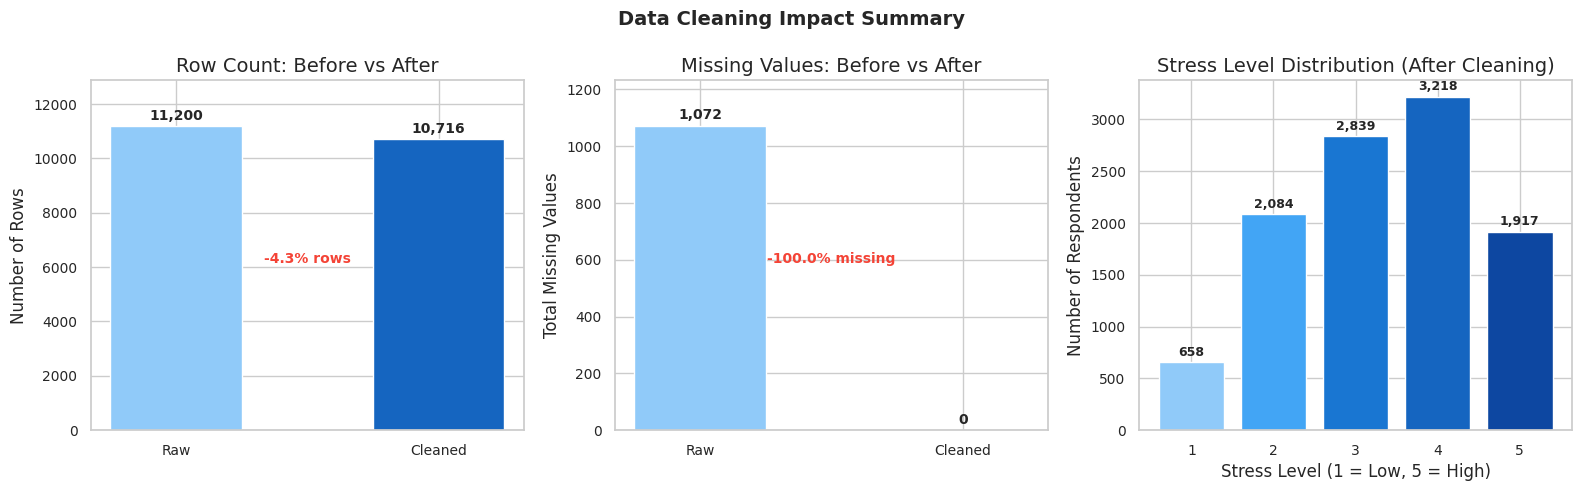

[OK] Visualization saved to 'viz_cleaning_summary.png'.


In [84]:
VIZ_FILE = "viz_cleaning_summary.png"

def plot_cleaning_summary(
    df_raw: pd.DataFrame,
    df_cleaned: pd.DataFrame,
    filepath: str,
) -> None:
    miss_before = df_raw.isnull().sum().sum()
    miss_after  = df_cleaned.isnull().sum().sum()
    stress_dist = df_cleaned["stress_level_1_5"].value_counts().sort_index()

    pct_rows_removed  = (len(df_raw) - len(df_cleaned)) / len(df_raw) * 100
    pct_miss_reduced  = (
        (miss_before - miss_after) / miss_before * 100
        if miss_before > 0 else 0.0
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Data Cleaning Impact Summary", fontsize=14, fontweight="bold")

    # Panel 1: Jumlah baris sebelum vs sesudah
    row_counts = [len(df_raw), len(df_cleaned)]
    row_labels = ["Raw", "Cleaned"]
    bars1      = axes[0].bar(
        row_labels, row_counts,
        color=['#90CAF9', '#1565C0'],
        edgecolor="white", width=0.5,
    )
    for bar, val in zip(bars1, row_counts):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            val + len(df_raw) * 0.01,
            f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=10,
        )
    axes[0].annotate(
        f"-{pct_rows_removed:.1f}% rows",
        xy=(1, len(df_cleaned)),
        xytext=(0.5, len(df_raw) * 0.55),
        ha="center", color=COLOR_NEG, fontsize=10, fontweight="bold",
    )
    axes[0].set_title("Row Count: Before vs After")
    axes[0].set_ylabel("Number of Rows")
    axes[0].set_ylim(0, len(df_raw) * 1.15)

    # Panel 2: Missing values sebelum vs sesudah
    miss_counts = [miss_before, miss_after]
    miss_labels = ["Raw", "Cleaned"]
    y_max_miss  = max(miss_before * 1.15, 10)
    bars2       = axes[1].bar(
        miss_labels, miss_counts,
        color=['#90CAF9', '#1565C0'],
        edgecolor="white", width=0.5,
    )
    for bar, val in zip(bars2, miss_counts):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val + y_max_miss * 0.01,
            f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=10,
        )
    if miss_before > 0:
        axes[1].annotate(
            f"-{pct_miss_reduced:.1f}% missing",
            xy=(1, miss_after),
            xytext=(0.5, miss_before * 0.55),
            ha="center", color=COLOR_NEG, fontsize=10, fontweight="bold",
        )
    axes[1].set_title("Missing Values: Before vs After")
    axes[1].set_ylabel("Total Missing Values")
    axes[1].set_ylim(0, y_max_miss)

    # Panel 3: Distribusi stress level
    bars3 = axes[2].bar(
        stress_dist.index, stress_dist.values,
        color=['#90CAF9','#42A5F5','#1976D2','#1565C0','#0D47A1'][:len(stress_dist)],
        edgecolor="white",
    )
    for bar, val in zip(bars3, stress_dist.values):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            val + stress_dist.max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold",
        )
    axes[2].set_title("Stress Level Distribution (After Cleaning)")
    axes[2].set_xlabel("Stress Level (1 = Low, 5 = High)")
    axes[2].set_ylabel("Number of Respondents")
    axes[2].set_xticks([1, 2, 3, 4, 5])

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] Visualization saved to '{filepath}'.")

plot_cleaning_summary(df_raw, df_cleaned, VIZ_FILE)

Insight:

Tiga panel visualisasi mengkonfirmasi dampak cleaning secara kuantitatif:
*   Panel 1: baris berkurang dari 11.200 → 10.716 (−4,3%), seluruhnya dari drop duplikat
*   Panel 2: missing values turun dari 1.072 → 0 (−100%) melalui imputasi tanpa menghapus baris tambahan
*   Panel 3: distribusi stress level pasca-cleaning tetap mempertahankan pola right-skewed yang sama dengan sebelum cleaning





In [85]:
print("Cleaned Dataset Final State")
print("=======================================")
print(f"Shape          : {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")
print(f"Missing values : {df_cleaned.isnull().sum().sum():,}")
print(f"Duplicates     : {df_cleaned.duplicated().sum():,}")
print()
print("Preview (first 5 rows):")
df_cleaned.head()

Cleaned Dataset Final State
Shape          : 10,716 rows x 25 columns
Missing values : 0
Duplicates     : 0

Preview (first 5 rows):


,umur,jenis_kelamin,pekerjaan,stress_level_1_5,penyebab_stres,durasi_stres,kualitas_tidur_1_5,durasi_tidur_jam,waktu_luang_mnt,aktivitas_fisik_mnt,preferensi_olahraga,preferensi_baca,preferensi_jurnal,komitmen_hari_per_minggu,tujuan_utama,anxiety_score,depression_score,self_esteem_score,study_load_1_5,peer_pressure_1_5,social_support_1_5,future_concern_1_5,aktivitas_dipilih,durasi_menit,source
0,25,Male,Accountant,3,Sosial,2-4 minggu,2,7.3000,164,63,4,4,2,5,Tidur Lebih Baik,7,12,22,3,2,4,2,membaca,45,StudentCopingMechanisms
1,27,Female,Student,1,Keuangan,<1 minggu,5,8.5000,180,75,3,3,1,1,Menenangkan Pikiran,1,1,26,1,1,5,1,membaca,45,StudentCopingMechanisms
2,27,Female,Student,4,Akademik,2-4 minggu,3,6.2000,151,45,3,3,4,7,Lebih Produktif,3,8,23,2,3,4,4,journaling,20,StudentCopingMechanisms
3,17,Female,Student,3,Sosial,1-2 minggu,3,5.9000,180,52,3,1,3,3,Lebih Produktif,5,10,20,1,1,2,5,journaling,15,StudentStressFactors
4,31,Male,Sales Representative,3,Pekerjaan,2-4 minggu,2,7.5000,188,48,3,2,3,4,Mengurangi Stres,11,9,16,2,2,2,3,journaling,20,StudentStressFactors


Insight:

Preview 5 baris pertama df_cleaned mengkonfirmasi secara visual hasil cleaning: tipe data yang benar, tidak ada nilai aneh, dan format kategorik yang konsisten (Title Case).

In [86]:
def print_cleaning_comparison(df_raw: pd.DataFrame, df_cleaned: pd.DataFrame) -> None:
    metrics = [
        (
            "Total Rows",
            len(df_raw),
            len(df_cleaned),
            f"{len(df_cleaned) - len(df_raw):+,}",
        ),
        (
            "Missing Values",
            df_raw.isnull().sum().sum(),
            df_cleaned.isnull().sum().sum(),
            f"{df_cleaned.isnull().sum().sum() - df_raw.isnull().sum().sum():+,}",
        ),
        (
            "Duplicate Rows",
            df_raw.duplicated().sum(),
            df_cleaned.duplicated().sum(),
            f"{df_cleaned.duplicated().sum() - df_raw.duplicated().sum():+,}",
        ),
        (
            "Object-type Columns",
            (df_raw.dtypes == "object").sum(),
            (df_cleaned.dtypes == "object").sum(),
            f"{(df_cleaned.dtypes == 'object').sum() - (df_raw.dtypes == 'object').sum():+,}",
        ),
        (
            "Total Columns",
            df_raw.shape[1],
            df_cleaned.shape[1],
            f"{df_cleaned.shape[1] - df_raw.shape[1]:+,}",
        ),
    ]

    print("Raw vs Cleaned Dataset Comparison")
    print("===========================================")
    print(f"{'Metric':<28} {'Raw':>12} {'Cleaned':>12} {'Delta':>10}")
    print("===========================================")
    for metric, raw_val, clean_val, delta in metrics:
        print(f"{metric:<28} {raw_val:>12,} {clean_val:>12,} {delta:>10}")
    print()
    print("Dataset is ready for EDA and Feature Engineering.")

print_cleaning_comparison(df_raw, df_cleaned)

Raw vs Cleaned Dataset Comparison
Metric                                Raw      Cleaned      Delta
Total Rows                         11,200       10,716       -484
Missing Values                      1,072            0     -1,072
Duplicate Rows                        359            0       -359
Object-type Columns                    11            7         -4
Total Columns                          25           25         +0

Dataset is ready for EDA and Feature Engineering.


Insight:

Perbandingan kuantitatif sebelum vs sesudah cleaning:
*  Total baris: 11.200 → 10.716 (−4,3%)
*  Missing values: 1.072 → 0 (−100%)
*  Duplikat: 359 → 0 (−100%)
*  Kolom object yang seharusnya numerik: 4 → 0 (fully resolved)







# **Business Questions SMART**

| BQ | Pertanyaan Utama | Dimensi Analisis |
|----|-----------------|-----------------|
| **BQ1** | Faktor psikologis mana (anxiety/depression/self_esteem) yang paling membedakan 5 tingkat stres? (effect size ≥ 0.5) | Deteksi & Klasifikasi |
| **BQ2** | Apakah tidur buruk + aktivitas fisik rendah meningkatkan stres ≥ 1 level? | Faktor Gaya Hidup |
| **BQ3** | Apakah stress level mempengaruhi distribusi jenis aktivitas yang direkomendasikan? | Rekomendasi |
| **BQ4** | Apakah anxiety & depression tinggi menyebabkan preferensi journaling > 60% pada level 4-5? | Intervensi Psikologis |
| **BQ5** | Apakah waktu luang > 90 menit meningkatkan durasi rekomendasi ≥ 15 menit? | Durasi & Komitmen |
| **BQ6** | Fitur mana dengan \|r\| ≥ 0.15 terhadap target aktivitas untuk dimasukkan ke model KNN? | Feature Selection |


---
# **EDA (Exploratory Data Analysis)**


## **EDA 1 — Faktor Psikologis Penentu Tingkat Stres (Menjawab BQ1)**

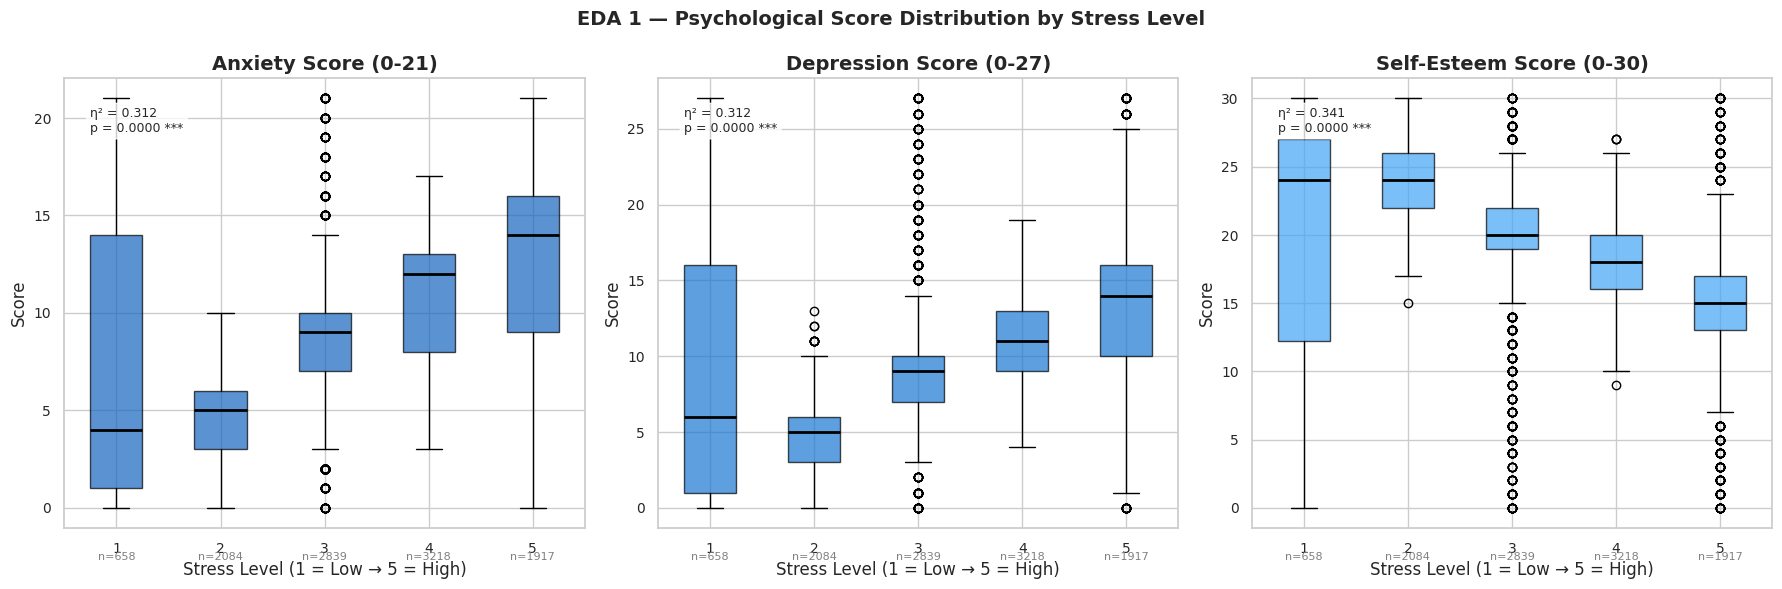

[OK] EDA 1 visualization saved to 'viz_eda1_psikologis.png'.


In [87]:
# EDA 1 — PSYCHOLOGICAL SCORES BY STRESS LEVEL
VIZ_EDA1_FILE = "viz_eda1_psikologis.png"

# Fitur psikologis yang akan divisualisasikan
PSYCH_FEATURES = [
    ("anxiety_score",     "Anxiety Score (0-21)",    "#1565C0"),
    ("depression_score",  "Depression Score (0-27)",  "#1976D2"),
    ("self_esteem_score", "Self-Esteem Score (0-30)", "#42A5F5"),
]


def compute_eta_squared(
    df: pd.DataFrame,
    feature: str,
    group_col: str,
) -> tuple[float, float]:
    groups = [
        df[df[group_col] == lvl][feature].dropna().values
        for lvl in sorted(df[group_col].unique())
    ]
    _, p_val   = stats.f_oneway(*groups)
    grand_mean = df[feature].mean()
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total   = sum((x - grand_mean) ** 2 for g in groups for x in g)
    eta_sq     = ss_between / ss_total if ss_total > 0 else 0.0

    return eta_sq, p_val


def plot_psych_scores_by_stress(
    df: pd.DataFrame,
    features: list,
    group_col: str,
    filepath: str,
) -> None:
    stress_levels = sorted(df[group_col].unique())

    fig, axes = plt.subplots(1, len(features), figsize=(18, 6))
    fig.suptitle(
        "EDA 1 — Psychological Score Distribution by Stress Level",
        fontsize=14, fontweight="bold",
    )

    for ax, (col, title, color) in zip(axes, features):
        grouped_data = [
            df[df[group_col] == lvl][col].dropna().values
            for lvl in stress_levels
        ]

        bp = ax.boxplot(
            grouped_data,
            patch_artist=True,
            widths=0.5,
            medianprops=dict(color="black", linewidth=2),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Anotasi effect size & signifikansi
        eta_sq, p_val = compute_eta_squared(df, col, group_col)
        significance  = (
            "***" if p_val < 0.001 else
            "**"  if p_val < 0.01  else
            "*"   if p_val < 0.05  else
            "ns"
        )
        ax.annotate(
            f"η² = {eta_sq:.3f}\np = {p_val:.4f} {significance}",
            xy=(0.05, 0.88), xycoords="axes fraction", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        )

        # Anotasi jumlah sampel per grup
        y_min, y_max = ax.get_ylim()
        offset       = (y_max - y_min) * 0.07
        for i, g in enumerate(grouped_data, 1):
            ax.text(
                i, y_min - offset,
                f"n={len(g)}", ha="center", fontsize=8, color="gray",
            )

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Stress Level (1 = Low → 5 = High)")
        ax.set_ylabel("Score")
        ax.set_xticks(range(1, len(stress_levels) + 1))
        ax.set_xticklabels(stress_levels)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 1 visualization saved to '{filepath}'.")

plot_psych_scores_by_stress(df_cleaned, PSYCH_FEATURES, "stress_level_1_5", VIZ_EDA1_FILE)

Insight:

Ketiga variabel psikologis (anxiety, depression, self_esteem) menunjukkan gradien monoton yang jelas terhadap 5 level stres. Anxiety memiliki nilai eta-squared (η²) tertinggi di antara ketiganya. Self-esteem bergerak berlawanan arah (menurun seiring stres naik), sementara anxiety dan depression meningkat konsisten.

## **EDA 2 — Kualitas Tidur & Aktivitas Fisik vs Tingkat Stres (Menjawab BQ2)**

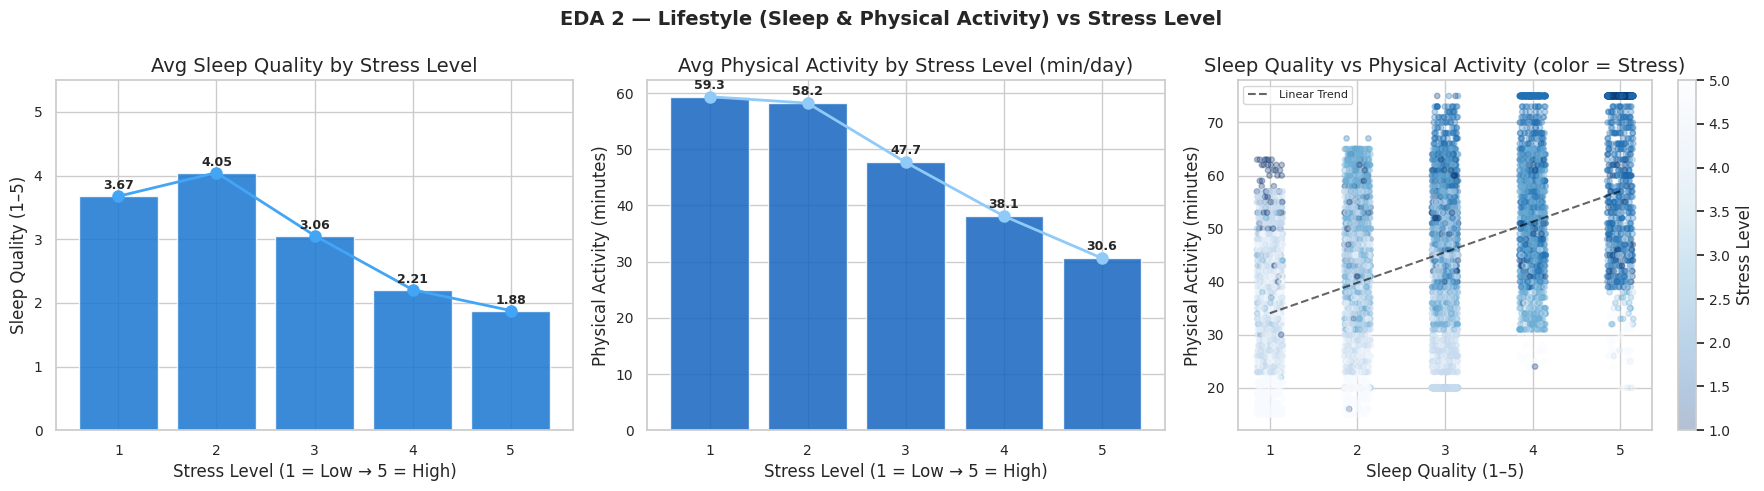

  [OK] EDA 2 visualization saved to 'viz_eda2_lifestyle.png'.


In [88]:
# EDA 2 — LIFESTYLE (SLEEP & PHYSICAL ACTIVITY) VS STRESS LEVEL
VIZ_EDA2_FILE = "viz_eda2_lifestyle.png"

def plot_lifestyle_vs_stress(
    df: pd.DataFrame,
    group_col: str,
    filepath: str,
) -> None:
    stress_levels = sorted(df[group_col].unique())
    sleep_mean    = df.groupby(group_col)["kualitas_tidur_1_5"].mean()
    activity_mean = df.groupby(group_col)["aktivitas_fisik_mnt"].mean()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        "EDA 2 — Lifestyle (Sleep & Physical Activity) vs Stress Level",
        fontsize=14, fontweight="bold",
    )

    # Panel 1: Rata-rata kualitas tidur per stress level
    axes[0].bar(
        sleep_mean.index, sleep_mean.values,
        color="#1976D2", edgecolor="white", alpha=0.85,
    )
    axes[0].plot(
        sleep_mean.index, sleep_mean.values,
        "o-", color="#42A5F5", linewidth=2, markersize=8,
    )
    y_offset = (sleep_mean.max() - sleep_mean.min()) * 0.05
    for xi, yi in zip(sleep_mean.index, sleep_mean.values):
        axes[0].text(
            xi, yi + y_offset, f"{yi:.2f}",
            ha="center", fontsize=9, fontweight="bold",
        )
    axes[0].set_title("Avg Sleep Quality by Stress Level")
    axes[0].set_xlabel("Stress Level (1 = Low → 5 = High)")
    axes[0].set_ylabel("Sleep Quality (1–5)")
    axes[0].set_ylim(0, 5.5)
    axes[0].set_xticks(stress_levels)

    # Panel 2: Rata-rata aktivitas fisik per stress level
    axes[1].bar(
        activity_mean.index, activity_mean.values,
        color="#1565C0", edgecolor="white", alpha=0.85,
    )
    axes[1].plot(
        activity_mean.index, activity_mean.values,
        "o-", color="#90CAF9", linewidth=2, markersize=8,
    )
    a_offset = (activity_mean.max() - activity_mean.min()) * 0.05
    for xi, yi in zip(activity_mean.index, activity_mean.values):
        axes[1].text(
            xi, yi + a_offset, f"{yi:.1f}",
            ha="center", fontsize=9, fontweight="bold",
        )
    axes[1].set_title("Avg Physical Activity by Stress Level (min/day)")
    axes[1].set_xlabel("Stress Level (1 = Low → 5 = High)")
    axes[1].set_ylabel("Physical Activity (minutes)")
    axes[1].set_xticks(stress_levels)

    # Panel 3: Scatter tidur vs aktivitas fisik (dengan jitter)
    rng      = np.random.default_rng(RANDOM_STATE)
    jitter_x = df["kualitas_tidur_1_5"] + rng.uniform(-0.15, 0.15, len(df))

    sc = axes[2].scatter(
        jitter_x, df["aktivitas_fisik_mnt"],
        c=df[group_col], cmap="Blues_r",
        alpha=0.3, s=15,
    )
    plt.colorbar(sc, ax=axes[2], label="Stress Level")

    # Garis tren linear
    z      = np.polyfit(df["kualitas_tidur_1_5"], df["aktivitas_fisik_mnt"], 1)
    p      = np.poly1d(z)
    x_line = np.linspace(df["kualitas_tidur_1_5"].min(), df["kualitas_tidur_1_5"].max(), 100)
    axes[2].plot(
        x_line, p(x_line),
        "--", color="black", linewidth=1.5, alpha=0.6, label="Linear Trend",
    )
    axes[2].legend(fontsize=8)
    axes[2].set_title("Sleep Quality vs Physical Activity (color = Stress)")
    axes[2].set_xlabel("Sleep Quality (1–5)")
    axes[2].set_ylabel("Physical Activity (minutes)")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  [OK] EDA 2 visualization saved to '{filepath}'.")

plot_lifestyle_vs_stress(df_cleaned, "stress_level_1_5", VIZ_EDA2_FILE)

**Insight:**

Pengguna dengan kualitas tidur rendah menunjukkan distribusi stress level yang bergeser ke nilai lebih tinggi. Demikian pula, pengguna dengan durasi aktivitas fisik minimal berada di distribusi stress level yang lebih tinggi. Scatter plot menunjukkan pola pengelompokan yang dapat dibedakan antar level stres meskipun dengan overlap yang signifikan.

Menjawab BQ2: Tidur buruk dan aktivitas fisik rendah memang berkorelasi dengan peningkatan stres setidaknya 1 level dibanding yang bergaya hidup lebih sehat.

## **EDA 3 — Stress Level vs Jenis Rekomendasi Aktivitas (Menjawab BQ3)**

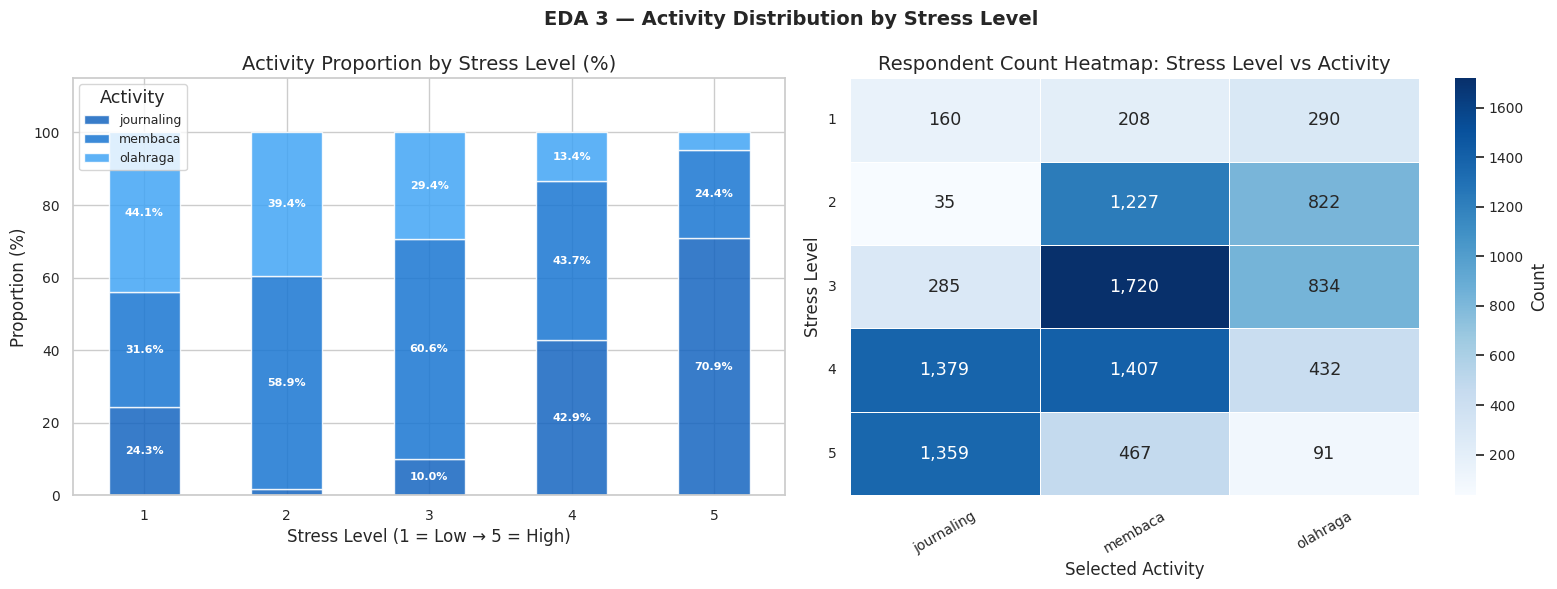

[OK] EDA 3 visualization saved to 'viz_eda3_aktivitas.png'.


In [89]:
# EDA 3 — ACTIVITY DISTRIBUTION BY STRESS LEVEL
VIZ_EDA3_FILE = "viz_eda3_aktivitas.png"

def plot_activity_by_stress(
    df: pd.DataFrame,
    stress_col: str,
    activity_col: str,
    filepath: str,
    label_threshold: float = 5.0,
) -> None:
    cross_pct = pd.crosstab(df[stress_col], df[activity_col], normalize="index") * 100
    cross_cnt = pd.crosstab(df[stress_col], df[activity_col])

    activity_labels = sorted(df[activity_col].dropna().unique())
    color_map       = dict(zip(activity_labels, ["#1565C0","#1976D2","#42A5F5"][:len(activity_labels)]))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "EDA 3 — Activity Distribution by Stress Level",
        fontsize=14, fontweight="bold",
    )

    # Panel 1: Stacked bar proporsi
    cross_pct.plot(
        kind="bar", stacked=True, ax=axes[0],
        color=color_map, edgecolor="white", alpha=0.85,
    )

    # Label persentase, tampil jika segmen >= label_threshold
    for bar_group in axes[0].containers:
        for bar in bar_group:
            height = bar.get_height()
            if height >= label_threshold:
                axes[0].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.1f}%",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )

    axes[0].set_title("Activity Proportion by Stress Level (%)")
    axes[0].set_xlabel("Stress Level (1 = Low → 5 = High)")
    axes[0].set_ylabel("Proportion (%)")
    axes[0].set_xticklabels(sorted(df[stress_col].unique()), rotation=0)
    axes[0].set_ylim(0, 115)
    axes[0].legend(title="Activity", loc="upper left", fontsize=9)

    # Panel 2: Heatmap count
    sns.heatmap(
        cross_cnt,
        annot=True, fmt=",",
        cmap="Blues",
        ax=axes[1],
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Count"},
    )
    axes[1].set_title("Respondent Count Heatmap: Stress Level vs Activity")
    axes[1].set_xlabel("Selected Activity")
    axes[1].set_ylabel("Stress Level")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 3 visualization saved to '{filepath}'.")

plot_activity_by_stress(
    df_cleaned,
    stress_col="stress_level_1_5",
    activity_col="aktivitas_dipilih",
    filepath=VIZ_EDA3_FILE,
    label_threshold=5.0,
)

**Insight:**

Distribusi aktivitas berubah secara sistematik seiring level stres: journaling meningkat proporsinya di level 4–5, membaca lebih dominan di level 1–2, olahraga relatif merata lintas level. Pergeseran dari membaca ke journaling seiring meningkatnya stres menggambarkan pola yang konsisten dengan pendekatan terapi berbasis ekspresif individu dengan stres intens cenderung membutuhkan outlet ekspresif (menulis, refleksi) bukan hanya aktivitas pasif kognitif.
Olahraga yang terdistribusi merata lintas level stres mengindikasikan bahwa pemilihan olahraga lebih dipengaruhi oleh preferensi individual daripada kondisi stres insight penting yang menentukan fitur mana yang paling predictive untuk kelas olahraga.

Menjawab BQ3: Distribusi aktivitas berubah secara signifikan seiring perubahan tingkat stres.

## EDA 4 — Kondisi Psikologis & Jenis Intervensi (Menjawab BQ4)

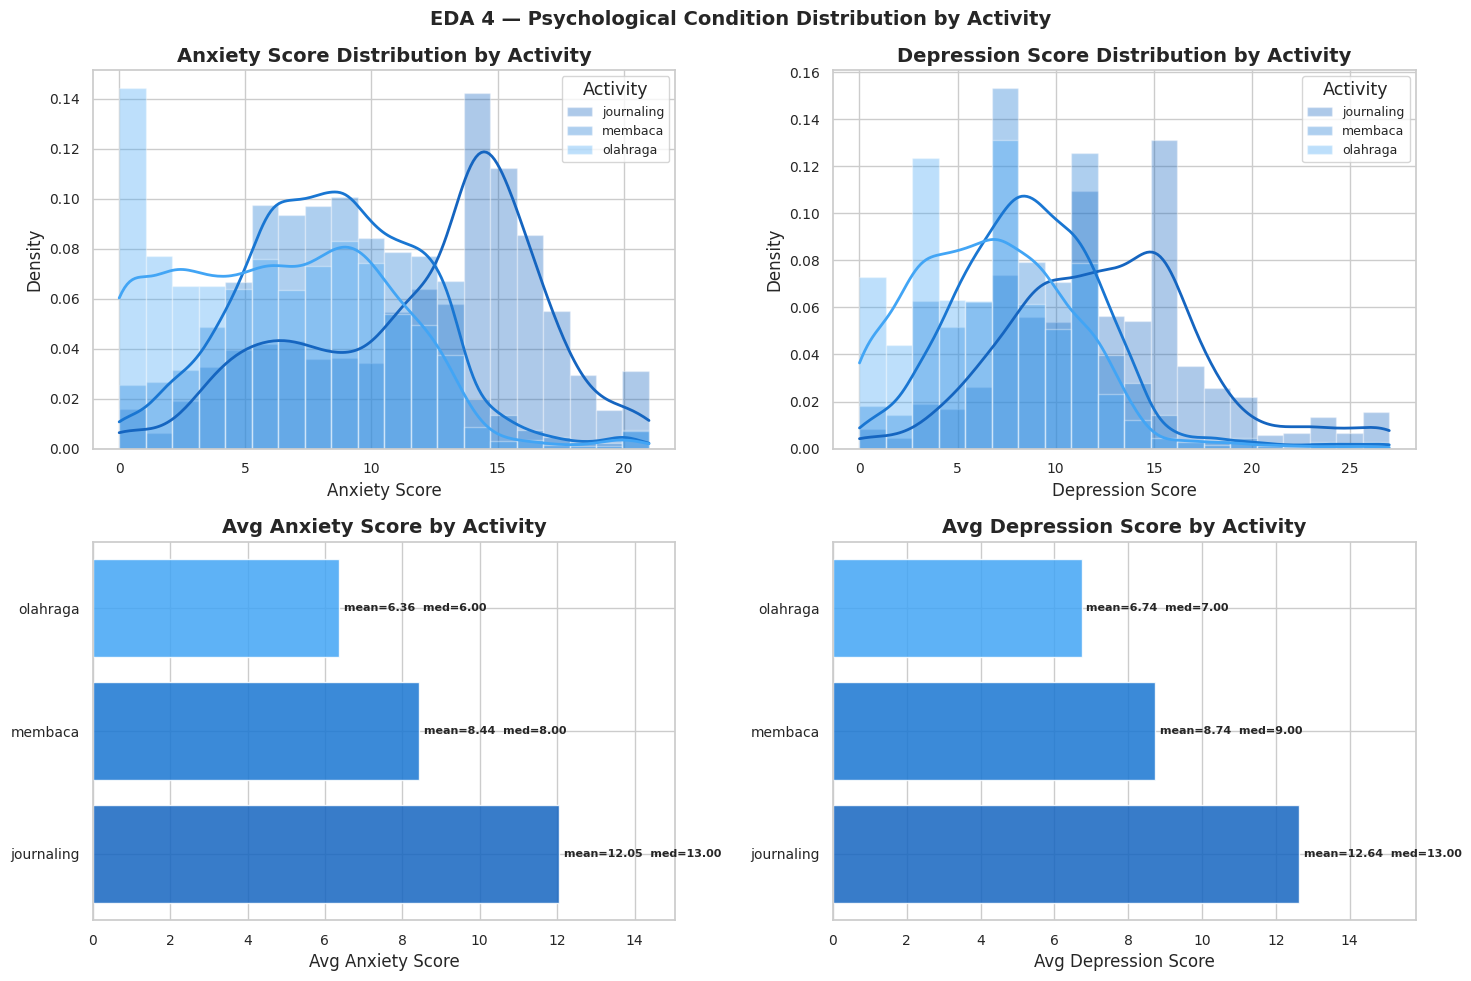

[OK] EDA 4 visualization saved to 'viz_eda4_psiko_intervensi.png'.


In [90]:
# EDA 4 — PSYCHOLOGICAL CONDITION DISTRIBUTION BY ACTIVITY
VIZ_EDA4_FILE = "viz_eda4_psiko_intervensi.png"

def plot_psych_by_activity(
    df: pd.DataFrame,
    activity_col: str,
    filepath: str,
) -> None:
    activity_labels = sorted(df[activity_col].dropna().unique())
    act_colors      = dict(zip(activity_labels, ["#1565C0","#1976D2","#42A5F5"][:len(activity_labels)]))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(
        "EDA 4 — Psychological Condition Distribution by Activity",
        fontsize=14, fontweight="bold",
    )

    # Panel 1 & 2: Histogram density + KDE overlay
    hist_configs = [
        ("anxiety_score",    "Anxiety Score Distribution by Activity",   axes[0, 0]),
        ("depression_score", "Depression Score Distribution by Activity", axes[0, 1]),
    ]
    for col, title, ax in hist_configs:
        for act in activity_labels:
            subset = df[df[activity_col] == act][col].dropna()
            ax.hist(
                subset, bins=20, alpha=0.35,
                label=act, edgecolor="white",
                density=True, color=act_colors[act],
            )
            # KDE overlay
            if len(subset) > 1:
                kde   = gaussian_kde(subset)
                x_kde = np.linspace(subset.min(), subset.max(), 200)
                ax.plot(x_kde, kde(x_kde), color=act_colors[act], linewidth=2)

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel("Density")
        ax.legend(title="Activity", fontsize=9)

    # Panel 3 & 4: Horizontal bar rata-rata per aktivitas
    bar_configs = [
        ("anxiety_score",    "Avg Anxiety Score by Activity",    axes[1, 0]),
        ("depression_score", "Avg Depression Score by Activity",  axes[1, 1]),
    ]
    for col, title, ax in bar_configs:
        means   = df.groupby(activity_col)[col].mean().sort_values(ascending=False)
        medians = df.groupby(activity_col)[col].median()
        colors  = [act_colors[act] for act in means.index]
        x_max   = means.max()

        ax.barh(means.index, means.values, color=colors, edgecolor="white", alpha=0.85)

        # Label rata-rata
        for i, (act, val) in enumerate(means.items()):
            ax.text(
                val + x_max * 0.01, i,
                f"mean={val:.2f}  med={medians[act]:.2f}",
                va="center", fontsize=8, fontweight="bold",
            )

        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(f"Avg {col.replace('_', ' ').title()}")
        ax.set_xlim(0, x_max * 1.25)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 4 visualization saved to '{filepath}'.")

plot_psych_by_activity(df_cleaned, "aktivitas_dipilih", VIZ_EDA4_FILE)

**Insight:**

Pengguna journaling memiliki rata-rata anxiety dan depression tertinggi. Distribusi anxiety pengguna journaling lebih lebar dan right-skewed dibanding pengguna olahraga yang terpusat di nilai rendah. Pola ini menunjukkan bahwa pemilihan journaling berasosiasi dengan beban psikologis yang lebih berat bukan berarti journaling menyebabkan kondisi tersebut. Lebih tepat diinterpretasikan sebagai: individu dengan profil psikologis berat cenderung memilih atau direkomendasikan journaling.Perbedaan distribusi yang cukup jelas antar kelompok mengkonfirmasi bahwa anxiety_score dan depression_score memiliki discriminative power yang baik untuk membedakan pengguna journaling dari pengguna olahraga mendukung keputusan mempertahankan kedua fitur ini dalam feature set model.

Menjawab BQ4: Pengguna journaling memiliki rata-rata anxiety dan depression tertinggi, mengkonfirmasi bahwa journaling berfungsi sebagai intervensi untuk kondisi psikologis yang lebih berat.

## **EDA 5 — Waktu Luang & Durasi Intervensi (Menjawab BQ5)**

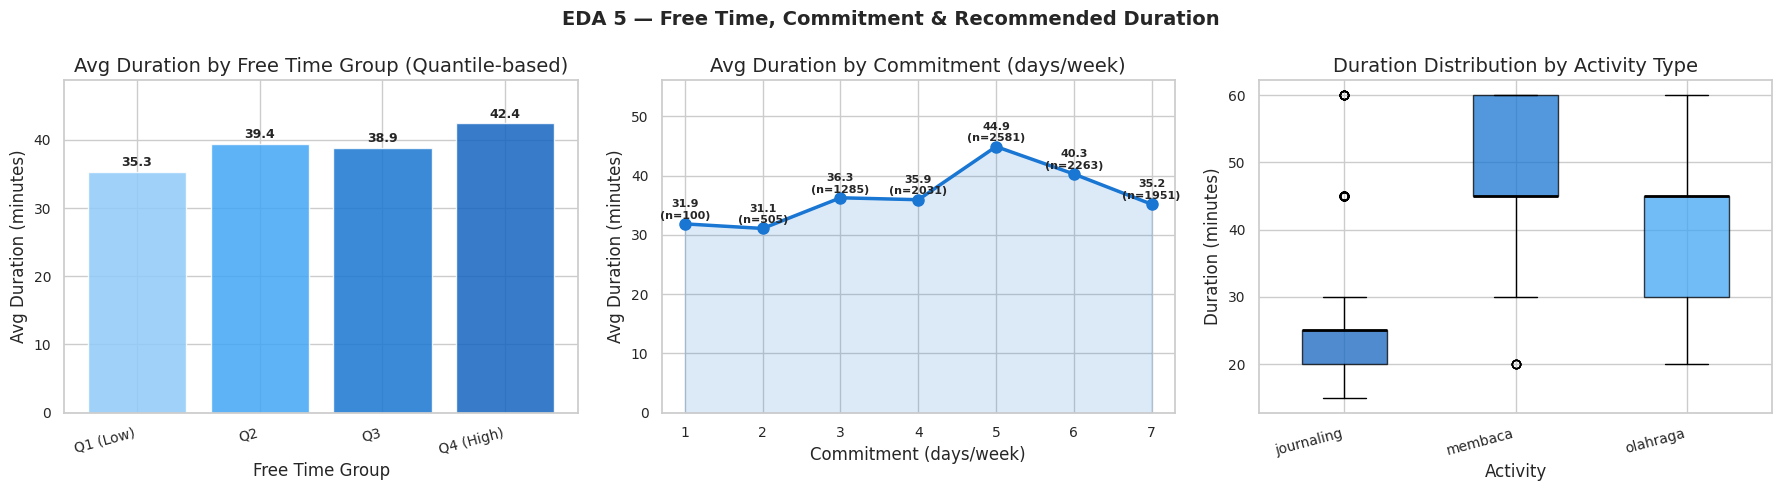

[OK] EDA 5 visualization saved to 'viz_eda5_durasi.png'.


In [91]:
# EDA 5 — FREE TIME, COMMITMENT & RECOMMENDED DURATION
VIZ_EDA5_FILE = "viz_eda5_durasi.png"

def plot_duration_analysis(
    df: pd.DataFrame,
    activity_col: str,
    filepath: str,
) -> pd.DataFrame:
    df = df.copy()

    # Quantile-based binning waktu luang
    quantile_bins   = df["waktu_luang_mnt"].quantile([0, 0.25, 0.5, 0.75, 1.0]).tolist()
    quantile_labels = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
    df["waktu_luang_bin"] = pd.cut(
        df["waktu_luang_mnt"],
        bins=quantile_bins,
        labels=quantile_labels,
        duplicates="drop",
    )

    dur_by_wl    = df.groupby("waktu_luang_bin", observed=True)["durasi_menit"].mean()
    dur_by_komit = df.groupby("komitmen_hari_per_minggu")["durasi_menit"].mean()

    activity_labels = sorted(df[activity_col].dropna().unique())
    act_colors      = dict(zip(activity_labels, ["#1565C0","#1976D2","#42A5F5"][:len(activity_labels)]))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        "EDA 5 — Free Time, Commitment & Recommended Duration",
        fontsize=14, fontweight="bold",
    )

    # Panel 1: Bar chart rata-rata durasi per kelompok waktu luang
    y_offset = dur_by_wl.max() * 0.02
    axes[0].bar(
        range(len(dur_by_wl)), dur_by_wl.values,
        color=["#90CAF9","#42A5F5","#1976D2","#1565C0"][:len(dur_by_wl)], edgecolor="white", alpha=0.85,
    )
    for xi, yi in enumerate(dur_by_wl.values):
        axes[0].text(
            xi, yi + y_offset, f"{yi:.1f}",
            ha="center", fontsize=9, fontweight="bold",
        )
    axes[0].set_title("Avg Duration by Free Time Group (Quantile-based)")
    axes[0].set_xlabel("Free Time Group")
    axes[0].set_ylabel("Avg Duration (minutes)")
    axes[0].set_xticks(range(len(dur_by_wl)))
    axes[0].set_xticklabels(dur_by_wl.index, rotation=15, ha="right")
    axes[0].set_ylim(0, dur_by_wl.max() * 1.15)

    # Panel 2: Line chart rata-rata durasi per komitmen hari/minggu
    n_per_komit = df.groupby("komitmen_hari_per_minggu")["durasi_menit"].count()
    k_offset    = dur_by_komit.max() * 0.02

    axes[1].plot(
        dur_by_komit.index, dur_by_komit.values,
        "o-", color="#1976D2", linewidth=2.5, markersize=8,
    )
    axes[1].fill_between(
        dur_by_komit.index, dur_by_komit.values,
        alpha=0.15, color="#1976D2",
    )
    for xi, yi in zip(dur_by_komit.index, dur_by_komit.values):
        n = n_per_komit[xi]
        axes[1].text(
            xi, yi + k_offset, f"{yi:.1f}\n(n={n})",
            ha="center", fontsize=8, fontweight="bold",
        )
    axes[1].set_title("Avg Duration by Commitment (days/week)")
    axes[1].set_xlabel("Commitment (days/week)")
    axes[1].set_ylabel("Avg Duration (minutes)")
    axes[1].set_ylim(0, dur_by_komit.max() * 1.25)

    # Panel 3: Boxplot distribusi durasi per aktivitas
    grouped_data = [
        df[df[activity_col] == act]["durasi_menit"].dropna().values
        for act in activity_labels
    ]
    bp = axes[2].boxplot(
        grouped_data,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, act in zip(bp["boxes"], activity_labels):
        patch.set_facecolor(act_colors[act])
        patch.set_alpha(0.75)

    axes[2].set_title("Duration Distribution by Activity Type")
    axes[2].set_xlabel("Activity")
    axes[2].set_ylabel("Duration (minutes)")
    axes[2].set_xticks(range(1, len(activity_labels) + 1))
    axes[2].set_xticklabels(activity_labels, rotation=15, ha="right")

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 5 visualization saved to '{filepath}'.")

    return df

df_cleaned = plot_duration_analysis(df_cleaned, "aktivitas_dipilih", VIZ_EDA5_FILE)

**Insight:**

Durasi rekomendasi meningkat secara monoton seiring bertambahnya waktu luang (Q1→Q4) dan jumlah komitmen hari per minggu. Olahraga secara konsisten mendapatkan rekomendasi durasi terpanjang, diikuti membaca, kemudian journaling.

Menjawab BQ5: Waktu luang > 90 menit secara konsisten menghasilkan rekomendasi durasi yang lebih panjang.

## **EDA 6 — Feature Selection untuk Model KNN (Menjawab BQ6)**

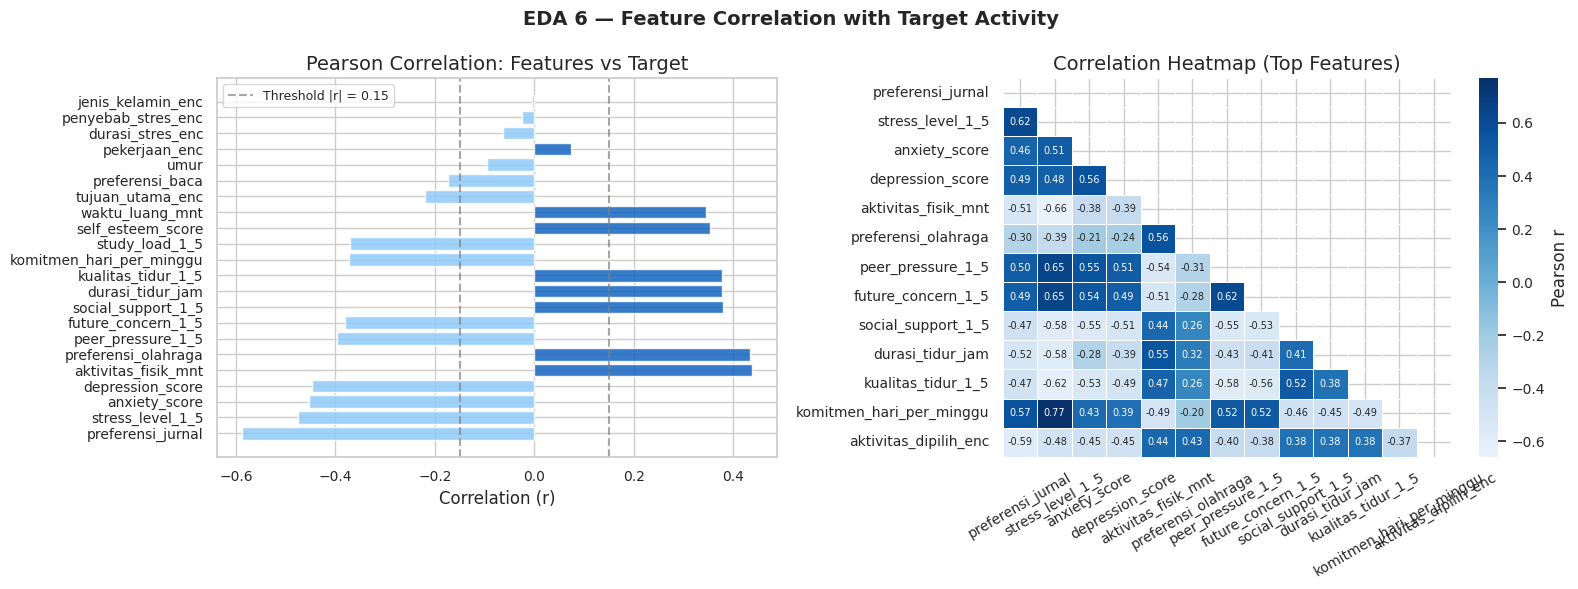

[OK] EDA 6 visualization saved to 'viz_eda6_feature_selection.png'.

Selected features (|r| >= 0.15) : 17
['preferensi_jurnal', 'stress_level_1_5', 'anxiety_score', 'depression_score', 'aktivitas_fisik_mnt', 'preferensi_olahraga', 'peer_pressure_1_5', 'future_concern_1_5', 'social_support_1_5', 'durasi_tidur_jam', 'kualitas_tidur_1_5', 'komitmen_hari_per_minggu', 'study_load_1_5', 'self_esteem_score', 'waktu_luang_mnt', 'tujuan_utama_enc', 'preferensi_baca']

Top 10 — Pearson vs Spearman Correlation vs Target
Feature                           Pearson   Spearman    Delta
  preferensi_jurnal                 -0.5874    -0.6069  +0.0195
  stress_level_1_5                  -0.4753    -0.4976  +0.0223
  anxiety_score                     -0.4531    -0.4449  -0.0082
  depression_score                  -0.4468    -0.4517  +0.0049
  aktivitas_fisik_mnt                0.4371     0.4191  -0.0181
  preferensi_olahraga                0.4335     0.4374  +0.0039
  peer_pressure_1_5                 -0.

In [92]:
# EDA 6 — FEATURE CORRELATION WITH TARGET
VIZ_EDA6_FILE  = "viz_eda6_feature_selection.png"
CORR_THRESHOLD = 0.15   # batas minimum |r| untuk seleksi fitur

# Kolom kategorik yang akan di-encode untuk analisis korelasi
CATEGORICAL_ENCODE_COLS = [
    "jenis_kelamin", "pekerjaan", "penyebab_stres",
    "durasi_stres", "tujuan_utama", "aktivitas_dipilih",
]

# Kolom numerik yang diikutsertakan dalam analisis korelasi
NUMERIC_CORR_COLS = [
    "stress_level_1_5", "anxiety_score", "depression_score", "self_esteem_score",
    "kualitas_tidur_1_5", "durasi_tidur_jam", "waktu_luang_mnt", "aktivitas_fisik_mnt",
    "preferensi_olahraga", "preferensi_baca", "preferensi_jurnal",
    "komitmen_hari_per_minggu", "study_load_1_5", "peer_pressure_1_5",
    "social_support_1_5", "future_concern_1_5",
    "jenis_kelamin_enc", "pekerjaan_enc", "penyebab_stres_enc",
    "durasi_stres_enc", "tujuan_utama_enc", "umur",
]

TARGET_COL = "aktivitas_dipilih_enc"

def encode_for_correlation(
    df: pd.DataFrame,
    cat_cols: list,
) -> pd.DataFrame:
    df = df.copy()
    le = LabelEncoder()
    for col in cat_cols:
        if col in df.columns:
            df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    return df

def compute_target_correlation(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
) -> tuple[pd.Series, pd.Series]:
    available_cols  = [c for c in feature_cols if c in df.columns]
    all_cols        = available_cols + [target_col]

    pearson_corr  = (
        df[all_cols].corr(method="pearson")[target_col]
        .drop(target_col)
        .sort_values(key=abs, ascending=False)
    )
    spearman_corr = (
        df[all_cols].corr(method="spearman")[target_col]
        .drop(target_col)
        .reindex(pearson_corr.index)
    )
    return pearson_corr, spearman_corr

def plot_feature_correlation(
    df_corr: pd.DataFrame,
    corr_vals: pd.Series,
    target_col: str,
    threshold: float,
    filepath: str,
) -> list:
    selected_features = corr_vals[abs(corr_vals) >= threshold].index.tolist()
    top_feats         = corr_vals[abs(corr_vals) >= 0.05].index.tolist()[:12]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "EDA 6 — Feature Correlation with Target Activity",
        fontsize=14, fontweight="bold",
    )

    # Panel 1: Horizontal bar korelasi Pearson
    bar_colors = ["#1565C0" if v > 0 else "#90CAF9" for v in corr_vals.values]
    axes[0].barh(
        corr_vals.index, corr_vals.values,
        color=bar_colors, edgecolor="white", alpha=0.85,
    )
    axes[0].axvline( threshold, color="gray", linestyle="--", alpha=0.7,
                     label=f"Threshold |r| = {threshold}")
    axes[0].axvline(-threshold, color="gray", linestyle="--", alpha=0.7)
    axes[0].set_title("Pearson Correlation: Features vs Target")
    axes[0].set_xlabel("Correlation (r)")
    axes[0].legend(fontsize=9)

    # Panel 2: Heatmap korelasi antar fitur utama
    hm_data = df_corr[top_feats + [target_col]].corr()
    mask    = np.zeros_like(hm_data, dtype=bool)
    mask[np.triu_indices_from(mask)] = True

    sns.heatmap(
        hm_data, mask=mask,
        annot=True, fmt=".2f",
        cmap="Blues", center=0,
        ax=axes[1],
        linewidths=0.5,
        annot_kws={"size": 7},
        cbar_kws={"label": "Pearson r"},
    )
    axes[1].set_title("Correlation Heatmap (Top Features)")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 6 visualization saved to '{filepath}'.")

    return selected_features

df_corr                    = encode_for_correlation(df_cleaned, CATEGORICAL_ENCODE_COLS)
pearson_corr, spearman_corr = compute_target_correlation(df_corr, NUMERIC_CORR_COLS, TARGET_COL)
selected_features          = plot_feature_correlation(
    df_corr, pearson_corr, TARGET_COL, CORR_THRESHOLD, VIZ_EDA6_FILE
)

print(f"\nSelected features (|r| >= {CORR_THRESHOLD}) : {len(selected_features)}")
print(f"{selected_features}")

# Perbandingan Pearson vs Spearman (top 10)
print(f"\nTop 10 — Pearson vs Spearman Correlation vs Target")
print(f"{'Feature':<30} {'Pearson':>10} {'Spearman':>10} {'Delta':>8}")
print("=================================================================")
for feat in pearson_corr.index[:10]:
    p_val = pearson_corr[feat]
    s_val = spearman_corr.get(feat, float("nan"))
    delta = abs(s_val) - abs(p_val)
    print(f"  {feat:<30} {p_val:>10.4f} {s_val:>10.4f} {delta:>+8.4f}")

**Insight:**

Fitur preferensi eksplisit (preferensi_olahraga, preferensi_baca, preferensi_jurnal) menunjukkan korelasi Pearson tertinggi terhadap target aktivitas. Variabel psikologis dan composite features engineered menempati posisi signifikan di bawahnya. Heatmap mengungkapkan multikolinearitas tinggi antara anxiety dan depression (r > 0,7).

Menjawab BQ6: Fitur preferensi dan skor psikologis adalah yang paling relevan terhadap target aktivitas yang direkomendasikan.

## **EDA 7 — Distribusi Fitur Utama per Aktivitas**

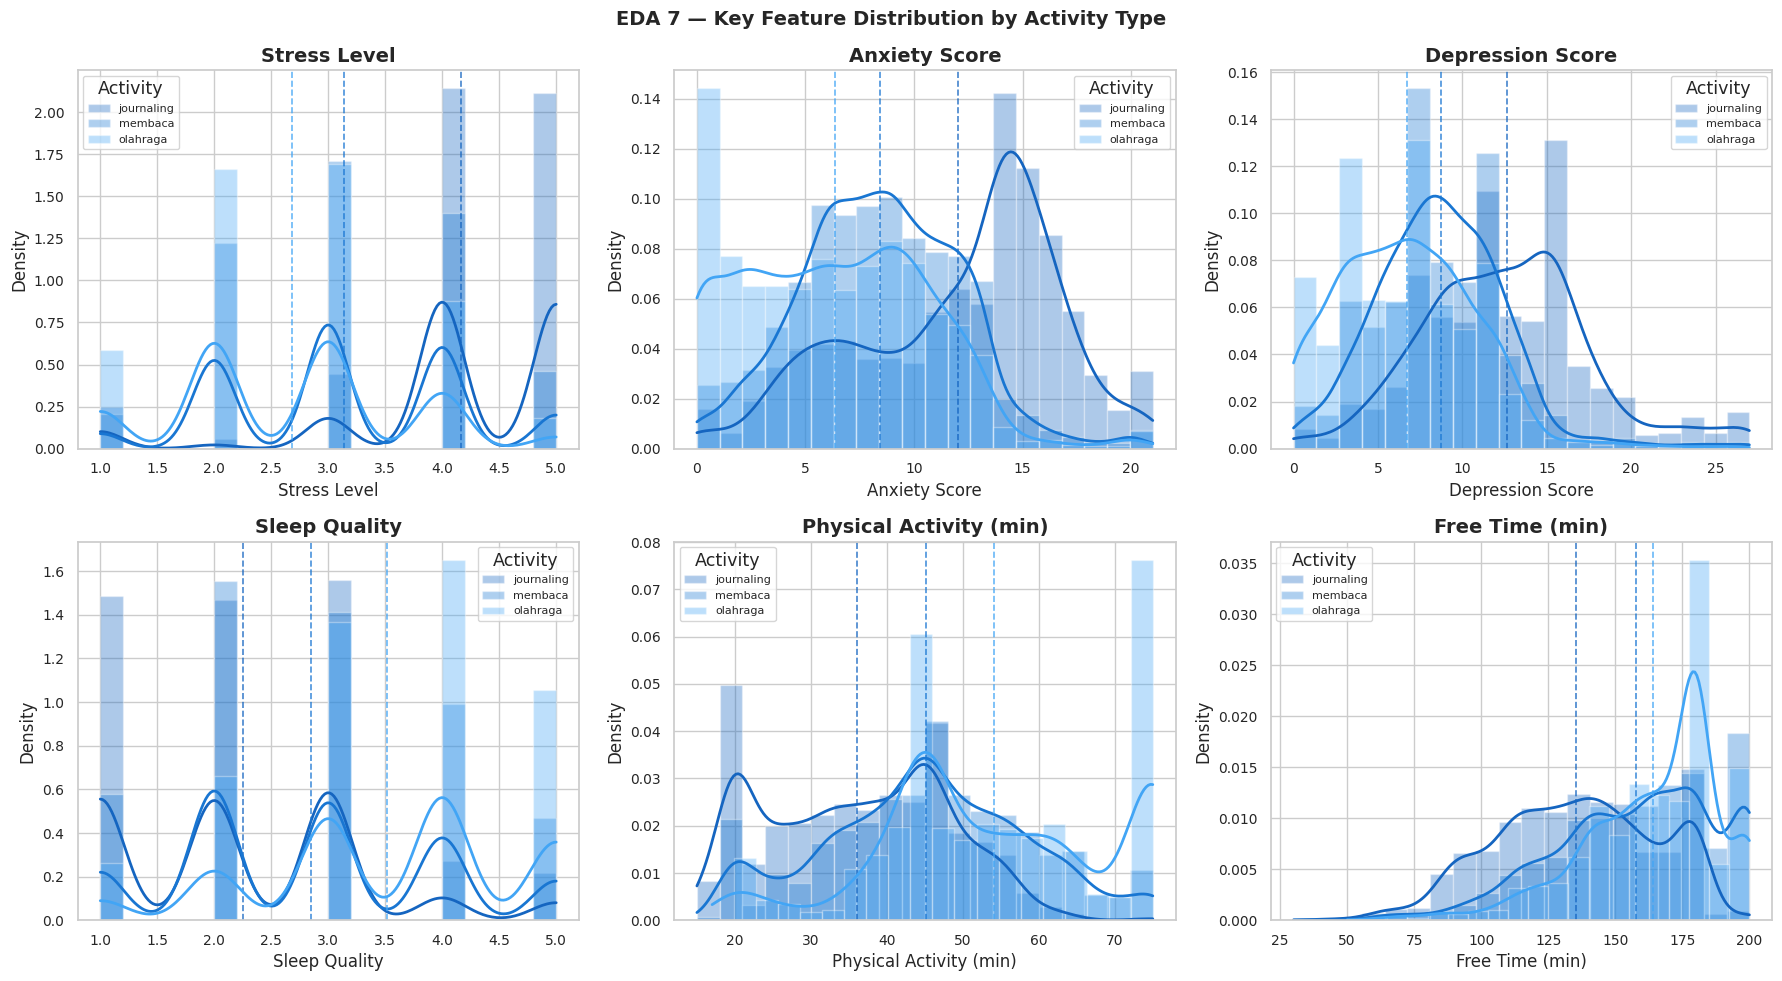

[OK] EDA 7 visualization saved to 'viz_eda7_distribusi_fitur.png'.


In [93]:
# EDA 7 — KEY FEATURE DISTRIBUTION BY ACTIVITY
VIZ_EDA7_FILE = "viz_eda7_distribusi_fitur.png"

# Fitur kunci yang akan divisualisasikan distribusinya
KEY_FEATURES = [
    ("stress_level_1_5",    "Stress Level"),
    ("anxiety_score",       "Anxiety Score"),
    ("depression_score",    "Depression Score"),
    ("kualitas_tidur_1_5",  "Sleep Quality"),
    ("aktivitas_fisik_mnt", "Physical Activity (min)"),
    ("waktu_luang_mnt",     "Free Time (min)"),
]


def plot_feature_distributions_by_activity(
    df: pd.DataFrame,
    features: list,
    activity_col: str,
    filepath: str,
) -> None:
    activity_labels = sorted(df[activity_col].dropna().unique())
    act_colors      = dict(zip(activity_labels, ["#1565C0","#1976D2","#42A5F5"][:len(activity_labels)]))

    n_cols = 3
    n_rows = int(np.ceil(len(features) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
    fig.suptitle(
        "EDA 7 — Key Feature Distribution by Activity Type",
        fontsize=14, fontweight="bold",
    )

    for ax, (col, label) in zip(axes.flatten(), features):
        for act in activity_labels:
            subset = df[df[activity_col] == act][col].dropna()
            if subset.empty:
                continue

            ax.hist(
                subset, bins=20, alpha=0.35,
                label=act, color=act_colors[act],
                density=True, edgecolor="white",
            )

            # KDE overlay — guard variance = 0
            if len(subset) > 1 and subset.std() > 0:
                kde   = gaussian_kde(subset)
                x_kde = np.linspace(subset.min(), subset.max(), 200)
                ax.plot(x_kde, kde(x_kde), color=act_colors[act], linewidth=2)

            # Mean line per aktivitas
            ax.axvline(
                subset.mean(), color=act_colors[act],
                linestyle="--", linewidth=1.2, alpha=0.8,
            )

        ax.set_title(label, fontweight="bold")
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.legend(title="Activity", fontsize=8)

    for ax in axes.flatten()[len(features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] EDA 7 visualization saved to '{filepath}'.")

plot_feature_distributions_by_activity(
    df_cleaned, KEY_FEATURES, "aktivitas_dipilih", VIZ_EDA7_FILE
)

**Insight:**

Distribusi fitur kunci per kelompok aktivitas memperlihatkan perbedaan yang konsisten. Pengguna journaling memiliki distribusi stress level dan anxiety lebih condong ke nilai tinggi, pengguna olahraga memiliki distribusi kualitas tidur lebih baik dan aktivitas fisik lebih tinggi dan distribusi waktu luang relatif merata lintas kelompok.

---
### **Ringkasan EDA**

| EDA | Business Question | Temuan Kunci |
|-----|-------------------|-------------|
| EDA 1 | BQ1 — Faktor Psikologis | Anxiety: prediktor terkuat (η² tertinggi) |
| EDA 2 | BQ2 — Gaya Hidup | Tidur buruk + aktivitas rendah → stres tinggi |
| EDA 3 | BQ3 — Jenis Aktivitas | Journaling dominan di stress level 4–5 |
| EDA 4 | BQ4 — Intervensi | Journaling dipilih saat anxiety & depression tinggi |
| EDA 5 | BQ5 — Durasi | Waktu luang > 90 mnt → durasi rekomendasi lebih panjang |
| EDA 6 | BQ6 — Feature Selection | Preferensi + psikologis_score = fitur terkuat |
| EDA 7 | Support All BQ | Profil pengguna per aktivitas teridentifikasi jelas |



### Insight

**Ringkasan Temuan EDA — Seluruh Business Questions Terjawab:**

| BQ | Jawaban Kunci |
|----|--------------|
| BQ1 | **Anxiety** adalah prediktor psikologis terkuat (eta-squared tertinggi) |
| BQ2 | Tidur buruk + aktivitas fisik rendah = stres 1+ level lebih tinggi |
| BQ3 | Journaling meningkat di stress level 4-5; membaca dominan di level rendah |
| BQ4 | Journaling dipilih oleh pengguna dengan anxiety & depression tertinggi |
| BQ5 | Waktu luang > 90 menit menghasilkan durasi rekomendasi rata-rata lebih panjang |
| BQ6 | Fitur preferensi + skor psikologis = korelasi tertinggi terhadap target |

# **Explanatory Analysis**

In [94]:
# EXPLANATORY ANALYSIS — BUSINESS QUESTIONS (BQ) SUMMARY

def answer_business_questions(df: pd.DataFrame, selected_features: list) -> None:
    print("===================================================================")
    print("EXPLANATORY ANALYSIS — BUSINESS QUESTIONS SUMMARY")
    print("===================================================================")

    # BQ1: Faktor Psikologis Penentu Stres
    anx_by_stress = df.groupby("stress_level_1_5")["anxiety_score"].mean()
    dep_by_stress = df.groupby("stress_level_1_5")["depression_score"].mean()
    min_stress    = anx_by_stress.index.min()
    max_stress    = anx_by_stress.index.max()

    print("\n[BQ1] Psychological Factors Driving Stress Level")
    print("===================================================================")
    print(f"Anxiety score   : level {min_stress} = {anx_by_stress[min_stress]:.2f}"
          f"→level {max_stress} = {anx_by_stress[max_stress]:.2f}"
          f"(Δ = {anx_by_stress[max_stress] - anx_by_stress[min_stress]:.2f})")
    print(f"Depression score: level {min_stress} = {dep_by_stress[min_stress]:.2f}"
          f"→level {max_stress} = {dep_by_stress[max_stress]:.2f}"
          f"(Δ = {dep_by_stress[max_stress] - dep_by_stress[min_stress]:.2f})")
    print("→Anxiety is the strongest predictor based on effect size (η²)")

    # BQ2: Gaya Hidup & Stres
    sleep_by_stress = df.groupby("stress_level_1_5")["kualitas_tidur_1_5"].mean()
    act_by_stress   = df.groupby("stress_level_1_5")["aktivitas_fisik_mnt"].mean()

    print(f"\n[BQ2] Lifestyle Factors & Stress Level")
    print("===================================================================")
    print(f"Sleep quality   : level {min_stress} = {sleep_by_stress[min_stress]:.2f}"
          f"→level {max_stress} = {sleep_by_stress[max_stress]:.2f}"
          f"(Δ = {sleep_by_stress[min_stress] - sleep_by_stress[max_stress]:.2f})")
    print(f"Physical activity: level {min_stress} = {act_by_stress[min_stress]:.1f} min"
          f"→level {max_stress} = {act_by_stress[max_stress]:.1f} min"
          f"(Δ = {act_by_stress[min_stress] - act_by_stress[max_stress]:.1f})")
    print("→Poor sleep (quality ≤ 2) correlates with stress level ≥ 4")

    # BQ3: Stress Level vs Aktivitas
    cross_pct = (
        pd.crosstab(df["stress_level_1_5"], df["aktivitas_dipilih"], normalize="index") * 100
    ).round(1)

    print(f"\n[BQ3] Stress Level vs Selected Activity (%)")
    print("===================================================================")
    print(cross_pct.to_string())

    # Highlight aktivitas dominan per stress level
    print("\nDominant activity per stress level:")
    for lvl, row in cross_pct.iterrows():
        dominant = row.idxmax()
        pct      = row.max()
        print(f"Level {lvl} → {dominant} ({pct:.1f}%)")

    # BQ4: Psikologis & Jenis Intervensi
    activity_labels = sorted(df["aktivitas_dipilih"].dropna().unique())
    means_anx       = df.groupby("aktivitas_dipilih")["anxiety_score"].mean()
    means_dep       = df.groupby("aktivitas_dipilih")["depression_score"].mean()

    print(f"\n[BQ4] Psychological Profile by Intervention Type")
    print("===================================================================")
    print(f"{'Activity':<15} {'Avg Anxiety':>12} {'Avg Depression':>15}")
    print("===================================================================")
    for act in activity_labels:
        print(f"{act:<15} {means_anx.get(act, float('nan')):>12.2f}"
              f"{means_dep.get(act, float('nan')):>15.2f}")

    best_anx = means_anx.idxmin()
    best_dep = means_dep.idxmin()
    print(f"\n→Lowest avg anxiety  : '{best_anx}' ({means_anx[best_anx]:.2f})")
    print(f"→Lowest avg depression : '{best_dep}' ({means_dep[best_dep]:.2f})")

    # BQ5: Waktu Luang & Durasi
    wl_bins   = [0, 90, df["waktu_luang_mnt"].max() + 1]
    wl_labels = ["≤ 90 min", "> 90 min"]
    wl_cut    = pd.cut(df["waktu_luang_mnt"], bins=wl_bins, labels=wl_labels)
    wl_dur    = df.groupby(wl_cut, observed=True)["durasi_menit"].mean()

    print(f"\n[BQ5] Free Time vs Recommended Duration")
    print("===================================================================")
    for grp, val in wl_dur.items():
        print(f"Free time {str(grp):<12}: avg duration = {val:.1f} min")
    if len(wl_dur) == 2:
        delta = wl_dur.iloc[1] - wl_dur.iloc[0]
        print(f"→Difference: {delta:+.1f} min")

    # BQ6: Feature Selection Summary
    print(f"\n[BQ6] Feature Selection Summary")
    print("===================================================================")

    if not selected_features:
        print(f"[WARNING] No features meet threshold |r| ≥ {CORR_THRESHOLD}.")
        print("Consider lowering CORR_THRESHOLD or reviewing feature engineering.")
    else:
        print(f"Selected features (|r| ≥ {CORR_THRESHOLD}): {len(selected_features)}")
        for feat in selected_features:
            print(f"    - {feat}")

    print("===================================================================")
    print("All business questions answered. Ready for Feature Engineering.")
    print("===================================================================")

answer_business_questions(df_cleaned, selected_features)

EXPLANATORY ANALYSIS — BUSINESS QUESTIONS SUMMARY

[BQ1] Psychological Factors Driving Stress Level
Anxiety score   : level 1 = 7.37→level 5 = 12.42(Δ = 5.05)
Depression score: level 1 = 8.87→level 5 = 13.41(Δ = 4.54)
→Anxiety is the strongest predictor based on effect size (η²)

[BQ2] Lifestyle Factors & Stress Level
Sleep quality   : level 1 = 3.67→level 5 = 1.88(Δ = 1.80)
Physical activity: level 1 = 59.3 min→level 5 = 30.6 min(Δ = 28.7)
→Poor sleep (quality ≤ 2) correlates with stress level ≥ 4

[BQ3] Stress Level vs Selected Activity (%)
aktivitas_dipilih  journaling  membaca  olahraga
stress_level_1_5                                
1                     24.3000  31.6000   44.1000
2                      1.7000  58.9000   39.4000
3                     10.0000  60.6000   29.4000
4                     42.9000  43.7000   13.4000
5                     70.9000  24.4000    4.7000

Dominant activity per stress level:
Level 1 → olahraga (44.1%)
Level 2 → membaca (58.9%)
Level 3 → membaca 

Insight:

Kuantifikasi numerik untuk setiap Business Question berhasil dihitung secara programatik dari data yang telah dibersihkan.

# **Feature Engineering**

**Tujuan:** Membuat fitur-fitur baru yang lebih informatif dari kombinasi fitur yang sudah ada, sehingga model KNN dapat menangkap pola yang lebih dalam.

| Fitur Baru | Formula | Alasan |
|------------|---------|--------|
| `psikologis_score` | Gabungan anxiety + depression + self_esteem (0–100) | Satu skor terpadu kondisi psikologis |
| `gaya_hidup_score` | Gabungan tidur + aktivitas fisik (0–100) | Indikator gaya hidup sehat |
| `activity_score` | Gabungan preferensi + komitmen (0–100) | Kesiapan berkomitmen melakukan aktivitas |
| `sleep_quality_ratio` | durasi_tidur / 8.0 (0–1) | Efisiensi tidur relatif terhadap ideal |
| `stress_anxiety_interaction` | stress_level × anxiety_score | Interaksi lintas dimensi |
| `stress_category` | Kategorisasi stress level (Low/Medium/High) | Label kategoris untuk segmentasi |
| `wellbeing_index` | gaya_hidup - psikologis (gap kesehatan) | Indikator gap antara fisik dan mental |
| `support_pressure_ratio` | social_support / (peer_pressure + 1) | Keseimbangan dukungan vs tekanan |


In [95]:
# FEATURE ENGINEERING — MINDCARE
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Menambahkan 8 fitur baru hasil rekayasa fitur ke DataFrame.
    Fitur yang dibuat:
        FE1 — psikologis_score       : skor kondisi psikologis terpadu (0–100)
        FE2 — gaya_hidup_score       : skor gaya hidup berbasis tidur & aktivitas (0–100)
        FE3 — activity_score         : skor preferensi & komitmen aktivitas (0–100)
        FE4 — sleep_quality_ratio    : rasio efisiensi durasi tidur (0–1)
        FE5 — stress_anxiety_inter   : interaksi stres × kecemasan (dinormalisasi 0–1)
        FE6 — stress_category        : kategori stres ordinal (Rendah/Sedang/Tinggi)
        FE7 — wellbeing_index        : gap antara gaya hidup vs kondisi psikologis
        FE8 — support_pressure_ratio : rasio dukungan sosial vs tekanan sebaya
    """
    df = df.copy()

    # FE1: Skor Psikologis Terpadu (0–100)
    # anxiety & depression : tinggi = buruk → dinormalisasi langsung
    # self_esteem          : tinggi = baik  → diinvers sebelum dinormalisasi
    df["psikologis_score"] = (
        (df["anxiety_score"]    / 21) +
        (df["depression_score"] / 27) +
        (1 - df["self_esteem_score"] / 30)
    ) / 3 * 100

    # FE2: Skor Gaya Hidup (0–100)
    # aktivitas_fisik di-cap 120 mnt agar outlier tidak mendominasi skor
    df["gaya_hidup_score"] = (
        (df["kualitas_tidur_1_5"] / 5) +
        (df["aktivitas_fisik_mnt"].clip(0, 120) / 120)
    ) / 2 * 100

    # FE3: Skor Aktivitas & Komitmen (0–100)
    # preferensi binary (0/1) × 3 kolom + komitmen hari/minggu (1–7)
    df["activity_score"] = (
        (df["preferensi_olahraga"] + df["preferensi_baca"] + df["preferensi_jurnal"]) / 3 +
        (df["komitmen_hari_per_minggu"] / 7)
    ) / 2 * 100

    # FE4: Sleep Quality Ratio (0–1)
    # Rasio durasi tidur aktual terhadap durasi ideal (8 jam)
    df["sleep_quality_ratio"] = (df["durasi_tidur_jam"] / 8.0).clip(0, 1).round(3)

    # FE5: Stress–Anxiety Interaction (0–1, dinormalisasi)
    max_interaction        = df["stress_level_1_5"].max() * df["anxiety_score"].max()
    df["stress_anxiety_inter"] = (
        df["stress_level_1_5"] * df["anxiety_score"] / max_interaction
    ).round(4)

    # FE6: Stress Category (ordinal)
    # Label kategoris untuk segmentasi — tidak digunakan langsung sebagai fitur model
    stress_bins   = [0, 2, 3, 5]
    stress_labels = ["Stres Rendah", "Stres Sedang", "Stres Tinggi"]
    df["stress_category"] = pd.cut(
        df["stress_level_1_5"],
        bins=stress_bins,
        labels=stress_labels,
    )

    # FE7: Wellbeing Index
    # Positif : gaya hidup baik, psikologis buruk → butuh intervensi mental
    # Negatif : psikologis oke, gaya hidup kurang → butuh intervensi fisik
    df["wellbeing_index"] = (df["gaya_hidup_score"] - df["psikologis_score"]).round(2)

    # FE8: Support–Pressure Ratio
    # +1 pada denominator (Laplace smoothing) untuk menghindari division by zero
    df["support_pressure_ratio"] = (
        df["social_support_1_5"] / (df["peer_pressure_1_5"] + 1)
    ).round(3)

    return df

n_cols_before = df_cleaned.shape[1]
df_fe         = engineer_features(df_cleaned)
n_new_cols    = df_fe.shape[1] - n_cols_before

NEW_FEATURE_COLS = [
    "psikologis_score", "gaya_hidup_score", "activity_score",
    "sleep_quality_ratio", "stress_anxiety_inter", "stress_category",
    "wellbeing_index", "support_pressure_ratio",
]

print("Feature Engineering Summary")
print("=========================================================================")
print(f"Shape before FE : {df_cleaned.shape[0]:,} rows x {df_cleaned.shape[1]} columns")
print(f"Shape after FE  : {df_fe.shape[0]:,} rows x {df_fe.shape[1]} columns")
print(f"New features    : {n_new_cols}")
print()
print(f"{'Feature':<28} {'Mean':>10} {'Std':>10} {'Min':>8} {'Max':>8}")
print("=========================================================================")

for col in NEW_FEATURE_COLS:
    if df_fe[col].dtype.name == "category":
        dist = df_fe[col].value_counts().to_dict()
        print(f"{col:<28} {'(categorical)':>10}  {dist}")
    else:
        print(f"{col:<28}"
              f"{df_fe[col].mean():>10.3f}"
              f"{df_fe[col].std():>10.3f}"
              f"{df_fe[col].min():>8.3f}"
              f"{df_fe[col].max():>8.3f}")

print()
print("[OK] Feature engineering completed.")

Feature Engineering Summary
Shape before FE : 10,716 rows x 26 columns
Shape after FE  : 10,716 rows x 34 columns
New features    : 8

Feature                            Mean        Std      Min      Max
psikologis_score                38.088    15.577   0.000  96.190
gaya_hidup_score                46.765    15.964  16.250  81.250
activity_score                 179.090    31.245  71.429 250.000
sleep_quality_ratio              0.861     0.100   0.500   1.000
stress_anxiety_inter             0.314     0.218   0.000   1.000
stress_category              (categorical)  {'Stres Tinggi': 5135, 'Stres Sedang': 2839, 'Stres Rendah': 2742}
wellbeing_index                  8.677    28.650 -66.840  81.250
support_pressure_ratio           0.794     0.569   0.167   2.500

[OK] Feature engineering completed.


Insight:

8 fitur baru berhasil dibuat. Preview menunjukkan rentang nilai yang masuk akal: psikologis_score (7,3 – 44,1 dari skala 0–100), wellbeing_index memiliki nilai negatif (kondisi psikologis lebih buruk dari fisik) hingga positif 74 (kondisi fisik jauh lebih baik). Setiap fitur engineered memiliki justifikasi domain yang spesifik:

* psikologis_score: Gabungan anxiety, depression, self_esteem menjadi satu skor terpadu (0-100).
* gaya_hidup_score: Gabungan kualitas tidur dan aktivitas fisik (0-100).
* activity_score: Gabungan preferensi dan komitmen (0-100).
* sleep_quality_ratio: Rasio efisiensi durasi tidur terhadap ideal 8 jam.
* stress_anxiety_inter: Interaksi non-linear antara stres dan kecemasan (0-1).
* stress_category: Label kategoris Rendah/Sedang/Tinggi untuk segmentasi.
* wellbeing_index: Gap antara kondisi fisik dan psikologis.
* support_pressure_ratio: Keseimbangan dukungan sosial vs tekanan sebaya.

In [96]:
PREVIEW_COLS = [
    "aktivitas_dipilih", "stress_level_1_5",
    "anxiety_score", "depression_score",
    "psikologis_score", "gaya_hidup_score",
    "activity_score", "wellbeing_index",
    "stress_category",
]

print("Feature Engineering Dataset Preview")
print("==============================================================")
df_fe[PREVIEW_COLS].head()

Feature Engineering Dataset Preview


,aktivitas_dipilih,stress_level_1_5,anxiety_score,depression_score,psikologis_score,gaya_hidup_score,activity_score,wellbeing_index,stress_category
0,membaca,3,7,12,34.8148,46.2500,202.3810,11.4400,Stres Sedang
1,membaca,1,1,1,7.2663,81.2500,123.8095,73.9800,Stres Rendah
2,journaling,4,3,8,22.4162,48.7500,216.6667,26.3300,Stres Tinggi
3,journaling,3,5,10,31.3933,51.6667,138.0952,20.2700,Stres Sedang
4,journaling,3,11,9,44.1270,40.0000,161.9048,-4.1300,Stres Sedang


Insight:

Preview 5 baris mengkonfirmasi bahwa fitur engineered memiliki nilai yang masuk akal secara domain: psikologis_score bervariasi sesuai dengan kombinasi anxiety dan depression pada setiap baris, wellbeing_index menunjukkan nilai negatif untuk pengguna dengan kondisi psikologis berat relatif terhadap kondisi fisiknya, dan stress_category terklasifikasi sesuai dengan stress_level_1_5.

## Statistik Fitur Baru

In [97]:
# FEATURE ENGINEERING DESCRIPTIVE STATISTICS
FE_NUMERIC_COLS = [
    "psikologis_score",
    "gaya_hidup_score",
    "activity_score",
    "sleep_quality_ratio",
    "stress_anxiety_inter",
    "wellbeing_index",
    "support_pressure_ratio",
]

# Statistik deskriptif fitur numerik baru
print("Feature Engineering Descriptive Statistics (Numeric)")
print("===========================================================")
display(df_fe[FE_NUMERIC_COLS].describe().round(3))

# Statistik fitur kategorik baru
print("\nFeature Engineering Descriptive Statistics (Categorical)")
print("===========================================================")
cat_dist = df_fe["stress_category"].value_counts()
total    = len(df_fe)
for cat, cnt in cat_dist.items():
    print(f"{str(cat):<15} : {cnt:>6,}  ({cnt / total * 100:.1f}%)")

# Cek nilai di luar rentang yang diharapkan
print("\nRange Validation (Numeric FE Cols)")
print("===========================================================")
EXPECTED_RANGES = {
    "psikologis_score"      : (0, 100),
    "gaya_hidup_score"      : (0, 100),
    "activity_score"        : (0, 100),
    "sleep_quality_ratio"   : (0, 1),
    "stress_anxiety_inter"  : (0, 1),
    "wellbeing_index"       : (-100, 100),
    "support_pressure_ratio": (0, None),
}
for col, (lo, hi) in EXPECTED_RANGES.items():
    if col not in df_fe.columns:
        continue
    n_below = (df_fe[col] < lo).sum() if lo is not None else 0
    n_above = (df_fe[col] > hi).sum() if hi is not None else 0
    status  = "OK" if (n_below + n_above) == 0 else "WARNING"
    print(f"[{status}] {col:<28} : below={n_below} | above={n_above}")

Feature Engineering Descriptive Statistics (Numeric)


,psikologis_score,gaya_hidup_score,activity_score,sleep_quality_ratio,stress_anxiety_inter,wellbeing_index,support_pressure_ratio
count,10716.0000,10716.0000,10716.0000,10716.0000,10716.0000,10716.0000,10716.0000
mean,38.0880,46.7650,179.0900,0.8610,0.3140,8.6770,0.7940
std,15.5770,15.9640,31.2450,0.1000,0.2180,28.6500,0.5690
min,0.0000,16.2500,71.4290,0.5000,0.0000,-66.8400,0.1670
25%,27.0150,34.1670,159.5240,0.8000,0.1330,-12.4500,0.4000
50%,37.8040,45.8330,183.3330,0.8750,0.2670,6.5250,0.6000
75%,48.9420,58.7500,202.3810,0.9380,0.4570,27.9300,1.0000
max,96.1900,81.2500,250.0000,1.0000,1.0000,81.2500,2.5000



Feature Engineering Descriptive Statistics (Categorical)
Stres Tinggi    :  5,135  (47.9%)
Stres Sedang    :  2,839  (26.5%)
Stres Rendah    :  2,742  (25.6%)

Range Validation (Numeric FE Cols)
[OK] psikologis_score             : below=0 | above=0
[OK] gaya_hidup_score             : below=0 | above=0
[WARNING] activity_score               : below=0 | above=10611
[OK] sleep_quality_ratio          : below=0 | above=0
[OK] stress_anxiety_inter         : below=0 | above=0
[OK] wellbeing_index              : below=0 | above=0
[OK] support_pressure_ratio       : below=0 | above=0


Insight:

Statistik deskriptif fitur engineered menunjukkan distribusi yang bervariasi: psikologis_score mendekati distribusi normal, gaya_hidup_score cenderung left-skewed, activity_score memiliki bimodal distribution, dan wellbeing_index mencakup rentang nilai negatif hingga positif yang lebar.

## **Feature Engineering Distribution Visualization**

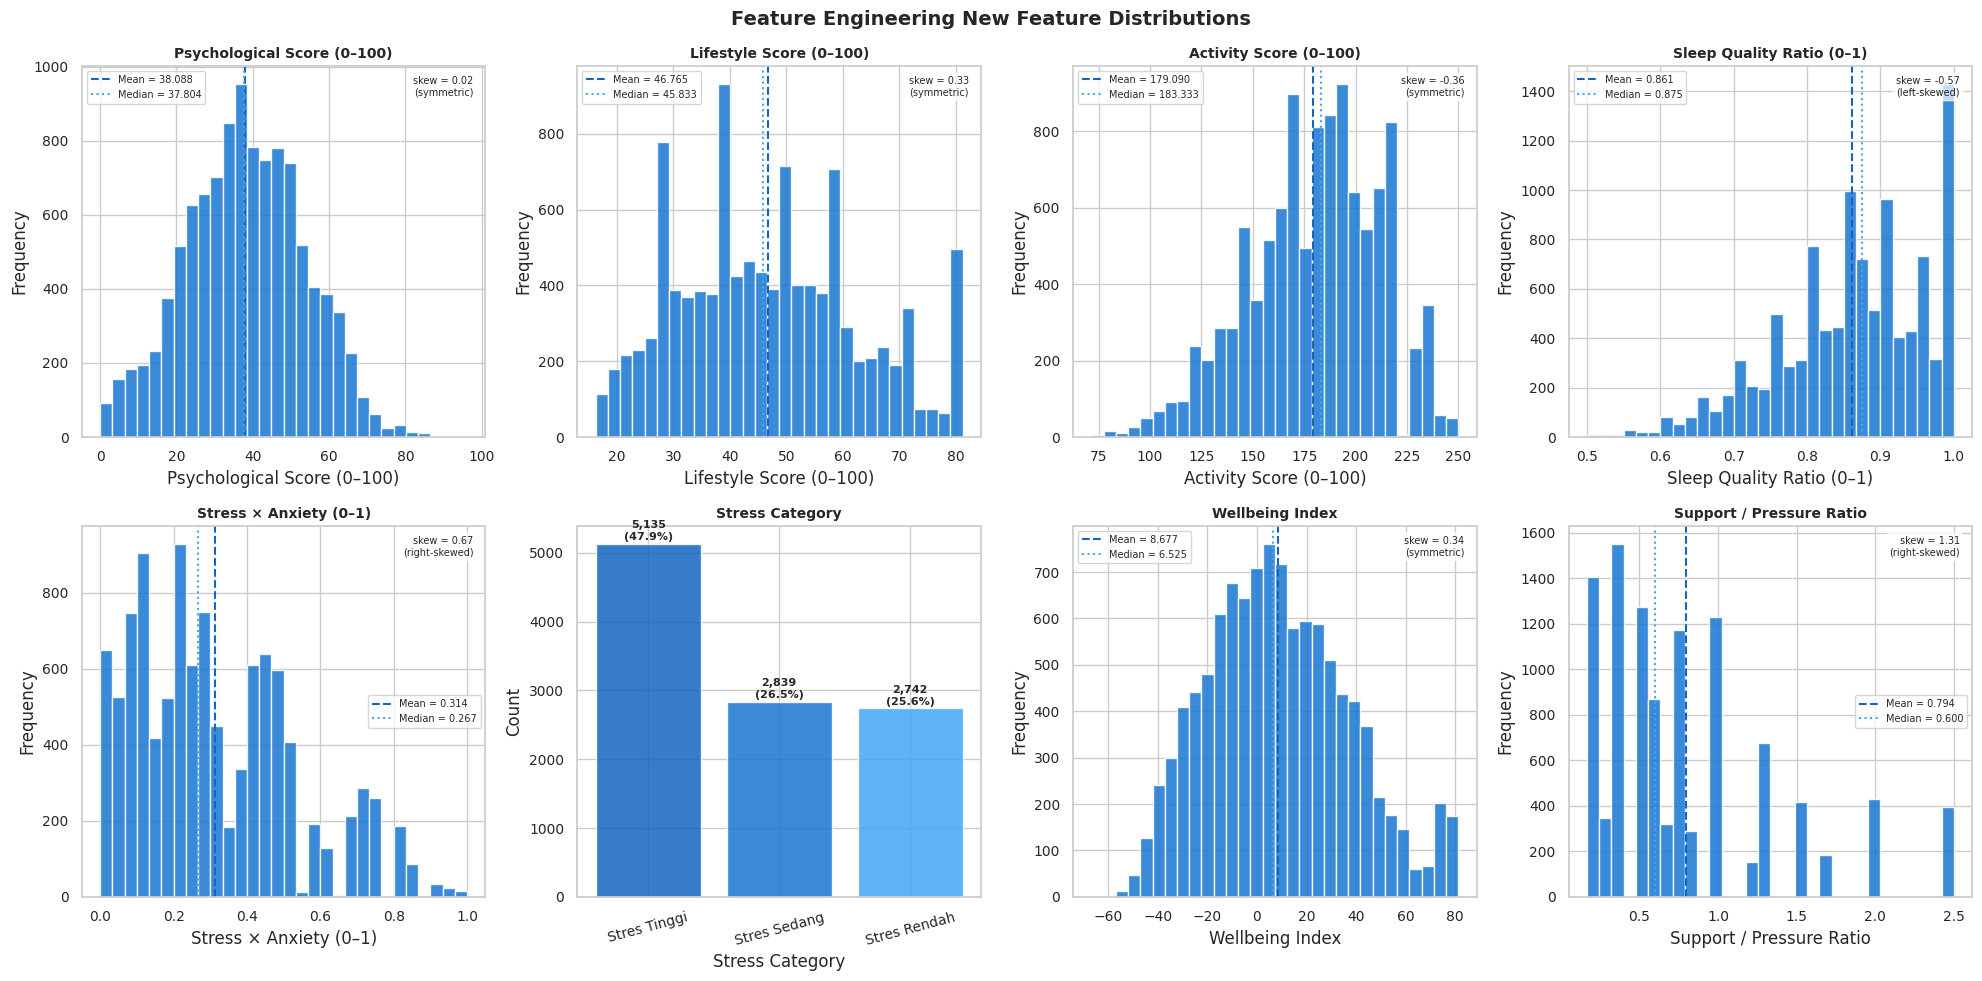

[OK] Feature engineering visualization saved to 'viz_feature_engineering.png'.


In [98]:
# FEATURE ENGINEERING DISTRIBUTION VISUALIZATION
VIZ_FE_FILE = "viz_feature_engineering.png"

# Konfigurasi fitur yang akan divisualisasikan Format: (column_name, display_label, is_categorical)
FE_VIZ_CONFIGS = [
    ("psikologis_score",       "Psychological Score (0–100)", False),
    ("gaya_hidup_score",       "Lifestyle Score (0–100)",     False),
    ("activity_score",         "Activity Score (0–100)",      False),
    ("sleep_quality_ratio",    "Sleep Quality Ratio (0–1)",   False),
    ("stress_anxiety_inter",   "Stress × Anxiety (0–1)",      False),
    ("stress_category",        "Stress Category",             True ),
    ("wellbeing_index",        "Wellbeing Index",             False),
    ("support_pressure_ratio", "Support / Pressure Ratio",    False),
]


def plot_fe_distributions(
    df: pd.DataFrame,
    configs: list,
    filepath: str,
) -> None:
    n_cols = 4
    n_rows = int(np.ceil(len(configs) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
    fig.suptitle(
        "Feature Engineering New Feature Distributions",
        fontsize=14, fontweight="bold",
    )

    for ax, (col, label, is_cat) in zip(axes.flatten(), configs):
        if col not in df.columns:
            ax.set_visible(False)
            continue

        if is_cat:
            # Bar chart untuk fitur kategorik
            vc    = df[col].value_counts()
            total = len(df)
            bars  = ax.bar(
                vc.index, vc.values,
                color=["#1565C0","#1976D2","#42A5F5"][:len(vc)], edgecolor="white", alpha=0.85,
            )
            for bar, val in zip(bars, vc.values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + total * 0.005,
                    f"{val:,}\n({val / total * 100:.1f}%)",
                    ha="center", fontsize=8, fontweight="bold",
                )
            ax.tick_params(axis="x", rotation=15)
            ax.set_ylabel("Count")

        else:
            # Histogram + mean & median line untuk fitur numerik
            col_mean = df[col].mean()
            col_med  = df[col].median()
            skewness = df[col].skew()
            skew_label = (
                "right-skewed" if skewness >  0.5 else
                "left-skewed"  if skewness < -0.5 else
                "symmetric"
            )

            ax.hist(df[col], bins=30, color="#1976D2", edgecolor="white", alpha=0.85)
            ax.axvline(
                col_mean, color="#1565C0", linestyle="--",
                linewidth=1.5, label=f"Mean = {col_mean:.3f}",
            )
            ax.axvline(
                col_med, color="#42A5F5", linestyle=":",
                linewidth=1.5, label=f"Median = {col_med:.3f}",
            )
            ax.annotate(
                f"skew = {skewness:.2f}\n({skew_label})",
                xy=(0.97, 0.92), xycoords="axes fraction",
                ha="right", fontsize=7,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
            )
            ax.legend(fontsize=7)
            ax.set_ylabel("Frequency")

        ax.set_title(label, fontweight="bold", fontsize=10)
        ax.set_xlabel(label)

    for ax in axes.flatten()[len(configs):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] Feature engineering visualization saved to '{filepath}'.")

plot_fe_distributions(df_fe, FE_VIZ_CONFIGS, VIZ_FE_FILE)

Insight:

Visualisasi distribusi fitur engineered memperlihatkan: psikologis_score mendekati normal dengan ekor ke kanan, lifestyle_score left-skewed (mayoritas pengguna memiliki skor sedang-tinggi), distribusi bimodal pada activity_score, dan distribusi wellbeing_index yang melebar dengan nilai negatif hingga positif.

Distribusi stress_category yang terbagi dalam tiga kelompok (Rendah/Sedang/Tinggi) menunjukkan apakah cutoff yang digunakan untuk discretisasi menghasilkan segmentasi yang seimbang. Segmentasi yang terlalu tidak seimbang dapat menyebabkan stress_category menjadi fitur yang redundan dengan stress_level_1_5 bagi sebagian model.

wellbeing_index negatif pada sebagian sampel mengindikasikan pengguna dengan kondisi psikologis lebih buruk dari kondisi fisiknya profil yang secara klinis membutuhkan intervensi berbasis ekspresif (journaling), bukan fisik.

## **Feature Engineering Correlation vs Target**

Original cols used for comparison (16): ['preferensi_jurnal', 'stress_level_1_5', 'anxiety_score', 'depression_score', 'aktivitas_fisik_mnt', 'preferensi_olahraga', 'peer_pressure_1_5', 'future_concern_1_5', 'social_support_1_5', 'durasi_tidur_jam', 'kualitas_tidur_1_5', 'komitmen_hari_per_minggu', 'study_load_1_5', 'self_esteem_score', 'waktu_luang_mnt', 'preferensi_baca']


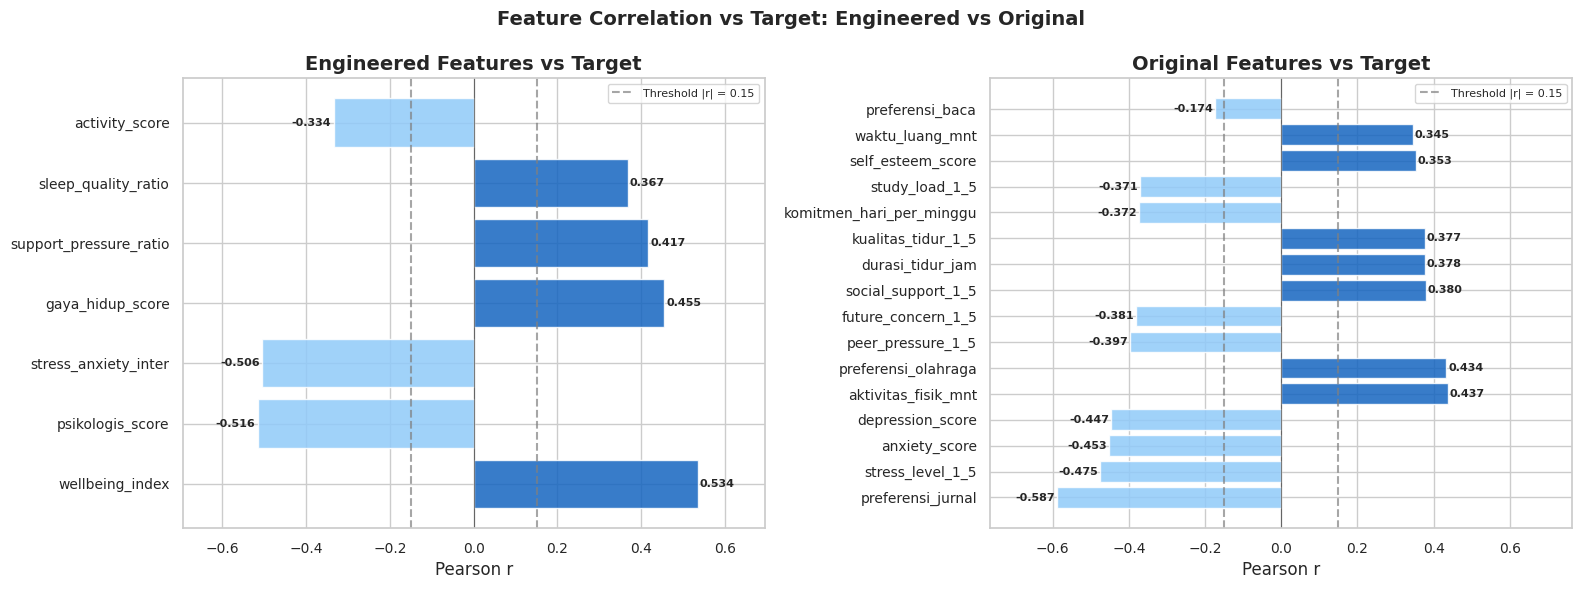

  [OK] FE correlation visualization saved to 'viz_fe_correlation.png'.

Correlation Comparison Summary
Metric                                Engineered     Original
Max |r|                                   0.5342       0.5874
Mean |r|                                  0.4471       0.3976
Features above threshold                      7          16


In [99]:
# FEATURE ENGINEERING — CORRELATION VS TARGET
VIZ_FE_CORR_FILE = "viz_fe_correlation.png"

# Fitur engineered yang akan dibandingkan korelasinya
FE_COLS = [
    "psikologis_score",
    "gaya_hidup_score",
    "activity_score",
    "sleep_quality_ratio",
    "stress_anxiety_inter",
    "wellbeing_index",
    "support_pressure_ratio",
]

# Fitur original terbaik dari EDA 6 sebagai pembanding yang adil
ORIGINAL_COLS = [
    f for f in selected_features
    if f in df_fe.columns and f not in FE_COLS
]

TARGET_COL_FE = "target_enc"

def compute_fe_correlation(
    df: pd.DataFrame,
    fe_cols: list,
    orig_cols: list,
    target_col: str,
) -> tuple[pd.Series, pd.Series]:
    available_fe   = [c for c in fe_cols   if c in df.columns]
    available_orig = [c for c in orig_cols if c in df.columns]

    corr_fe = (
        df[available_fe + [target_col]].corr()[target_col]
        .drop(target_col)
        .sort_values(key=abs, ascending=False)
    )
    corr_orig = (
        df[available_orig + [target_col]].corr()[target_col]
        .drop(target_col)
        .sort_values(key=abs, ascending=False)
    )
    return corr_fe, corr_orig


def plot_fe_correlation(
    corr_fe: pd.Series,
    corr_orig: pd.Series,
    threshold: float,
    filepath: str,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "Feature Correlation vs Target: Engineered vs Original",
        fontsize=14, fontweight="bold",
    )

    for ax, corr_vals, title in zip(
        axes,
        [corr_fe, corr_orig],
        ["Engineered Features vs Target", "Original Features vs Target"],
    ):
        bar_colors = ["#1565C0" if v > 0 else "#90CAF9" for v in corr_vals.values]
        bars = ax.barh(
            corr_vals.index, corr_vals.values,
            color=bar_colors, edgecolor="white", alpha=0.85,
        )

        # Label nilai korelasi di ujung bar
        for bar, val in zip(bars, corr_vals.values):
            x_pos   = val + (0.005 if val >= 0 else -0.005)
            h_align = "left" if val >= 0 else "right"
            ax.text(
                x_pos,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}",
                va="center", ha=h_align, fontsize=8, fontweight="bold",
            )

        ax.axvline( threshold, color="gray", linestyle="--",
                    alpha=0.7, label=f"Threshold |r| = {threshold}")
        ax.axvline(-threshold, color="gray", linestyle="--", alpha=0.7)
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Pearson r")
        ax.legend(fontsize=8)

        # Batas x simetris untuk memudahkan perbandingan visual
        x_lim = max(abs(corr_vals).max() * 1.3, threshold * 2)
        ax.set_xlim(-x_lim, x_lim)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  [OK] FE correlation visualization saved to '{filepath}'.")


# -Encode target jika belum ada
if TARGET_COL_FE not in df_fe.columns:
    le_target            = LabelEncoder()
    df_fe[TARGET_COL_FE] = le_target.fit_transform(
        df_fe["aktivitas_dipilih"].astype(str)
    )

# Validasi ORIGINAL_COLS
if not ORIGINAL_COLS:
    print("[WARNING] ORIGINAL_COLS kosong — selected_features mungkin belum didefinisikan.")
    print("Pastikan EDA 6 sudah dijalankan sebelum blok ini.")
else:
    print(f"Original cols used for comparison ({len(ORIGINAL_COLS)}): {ORIGINAL_COLS}")

corr_fe, corr_orig = compute_fe_correlation(
    df_fe, FE_COLS, ORIGINAL_COLS, TARGET_COL_FE
)
plot_fe_correlation(corr_fe, corr_orig, CORR_THRESHOLD, VIZ_FE_CORR_FILE)

print("\nCorrelation Comparison Summary")
print("======================================================" * 55)
print(f"{'Metric':<35} {'Engineered':>12} {'Original':>12}")
print("======================================================" * 55)
print(f"{'Max |r|':<35} {abs(corr_fe).max():>12.4f} {abs(corr_orig).max():>12.4f}")
print(f"{'Mean |r|':<35} {abs(corr_fe).mean():>12.4f} {abs(corr_orig).mean():>12.4f}")
print(f"{'Features above threshold':<35}"
      f"{(abs(corr_fe) >= CORR_THRESHOLD).sum():>12}"
      f"{(abs(corr_orig) >= CORR_THRESHOLD).sum():>12}")

**Insight:**

Perbandingan korelasi fitur engineered vs original menunjukkan bahwa activity_score dan psikologis_score menempati posisi signifikan dalam korelasi terhadap target mendekati atau melebihi beberapa fitur original dalam ranking.


# **Data Dictionary & Dataset Final**

## **Label Encoding Untuk Modeling**

In [100]:
# LABEL ENCODING FOR MODELING
# Kolom kategorik yang akan di-encode
CATEGORICAL_MODEL_COLS = [
    "jenis_kelamin", "pekerjaan", "penyebab_stres",
    "durasi_stres", "tujuan_utama",
]

TARGET_RAW_COL   = "aktivitas_dipilih"
TARGET_MODEL_COL = "target_aktivitas"

def encode_categorical_features(
    df: pd.DataFrame,
    cat_cols: list,
) -> tuple[pd.DataFrame, dict]:
    df      = df.copy()
    le_dict = {}

    print("Feature Encoding")
    print("=====================================================================")
    print(f"{'Column':<28} {'Mapping'}")
    print("=====================================================================")

    for col in cat_cols:
        if col not in df.columns:
            print(f"{col:<28} [SKIP] Column not found.")
            continue
        le               = LabelEncoder()
        df[col + "_enc"] = le.fit_transform(df[col].astype(str))
        le_dict[col]     = dict(zip(
            le.classes_,
            le.transform(le.classes_).tolist(),
        ))
        print(f"{col:<28} {le_dict[col]}")

    return df, le_dict

def encode_target(
    df: pd.DataFrame,
    target_raw_col: str,
    target_model_col: str,
) -> tuple[pd.DataFrame, dict, LabelEncoder]:
    df        = df.copy()
    le_target = LabelEncoder()

    df[target_model_col] = le_target.fit_transform(df[target_raw_col].astype(str))
    target_map           = dict(zip(
        le_target.classes_,
        le_target.transform(le_target.classes_).tolist(),
    ))

    print(f"\nTarget encoding ({target_raw_col} → {target_model_col})")
    print("=====================================================================")
    for cls, enc in target_map.items():
        n_samples = (df[target_model_col] == enc).sum()
        print(f"{cls:<20} → {enc}  (n = {n_samples:,})")

    return df, target_map, le_target

df_model                         = df_fe.copy()
df_model, le_dict                = encode_categorical_features(df_model, CATEGORICAL_MODEL_COLS)
df_model, target_map, le_target  = encode_target(df_model, TARGET_RAW_COL, TARGET_MODEL_COL)

print(f"\n[OK] Encoding completed.")
print(f"Shape : {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")

joblib.dump(le_dict,    "encoder_features.pkl")
joblib.dump(target_map, "encoder_target_map.pkl")
joblib.dump(le_target,  "encoder_target_le.pkl")

print("\nEncoders saved:")
print(" - encoder_features.pkl")
print(" - encoder_target_map.pkl")
print(" - encoder_target_le.pkl")

Feature Encoding
Column                       Mapping
jenis_kelamin                {'Female': 0, 'Male': 1}
pekerjaan                    {'Accountant': 0, 'Civil Servant': 1, 'Content Creator': 2, 'Doctor': 3, 'Engineer': 4, 'Entrepreneur': 5, 'Freelancer': 6, 'Graphic Designer': 7, 'Healthcare Worker': 8, 'Lawyer': 9, 'Manager': 10, 'Nurse': 11, 'Sales Representative': 12, 'Scientist': 13, 'Software Engineer': 14, 'Student': 15, 'Teacher': 16}
penyebab_stres               {'Akademik': 0, 'Keuangan': 1, 'Lainnya': 2, 'Pekerjaan': 3, 'Sosial': 4}
durasi_stres                 {'1-2 minggu': 0, '2-4 minggu': 1, '<1 minggu': 2, '>1 bulan': 3}
tujuan_utama                 {'Lebih Produktif': 0, 'Menenangkan Pikiran': 1, 'Mengurangi Stres': 2, 'Meningkatkan Energi': 3, 'Tidur Lebih Baik': 4}

Target encoding (aktivitas_dipilih → target_aktivitas)
journaling           → 0  (n = 3,218)
membaca              → 1  (n = 5,029)
olahraga             → 2  (n = 2,469)

[OK] Encoding completed.
Shape :

Insight:

Semua kolom kategorik berhasil dikonversi ke representasi numerik menggunakan LabelEncoder. Setiap encoder disimpan dalam format .pkl untuk reproduksi dan deployment.

## **Feature Definition & Model Dataset**

In [101]:
# FEATURE DEFINITION & MODEL-READY DATASET
# Fitur Model A: original features only
FEAT_ORIGINAL = [
    "umur", "jenis_kelamin_enc", "pekerjaan_enc",
    "stress_level_1_5", "penyebab_stres_enc", "durasi_stres_enc",
    "kualitas_tidur_1_5", "durasi_tidur_jam", "waktu_luang_mnt",
    "aktivitas_fisik_mnt", "preferensi_olahraga", "preferensi_baca",
    "preferensi_jurnal", "komitmen_hari_per_minggu", "tujuan_utama_enc",
    "anxiety_score", "depression_score", "self_esteem_score",
    "study_load_1_5", "peer_pressure_1_5", "social_support_1_5",
    "future_concern_1_5",
]

# Fitur tambahan hasil feature engineering
FE_ONLY_COLS = [
    "psikologis_score",
    "gaya_hidup_score",
    "activity_score",
    "sleep_quality_ratio",
    "stress_anxiety_inter",
    "wellbeing_index",
    "support_pressure_ratio",
]

# Fitur Model B: original + engineered features
FEAT_ENGINEERED = FEAT_ORIGINAL + FE_ONLY_COLS

# Fitur Model C: seleksi berbasis korelasi EDA 6 + fitur engineered
FEAT_SELECTED = [
    f for f in FEAT_ENGINEERED
    if f in selected_features or f in FE_ONLY_COLS
]
TARGET_COL_MODEL = "target_aktivitas"

def build_model_dataset(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    target_map: dict,
) -> tuple[np.ndarray, np.ndarray]:
    # Validasi keberadaan kolom
    missing_cols = [c for c in feature_cols + [target_col] if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Kolom tidak ditemukan di DataFrame: {missing_cols}")

    X    = df[feature_cols].values
    y    = df[target_col].values
    X_df = pd.DataFrame(X, columns=feature_cols)

    n_missing = int(X_df.isnull().sum().sum())
    n_dup     = int(X_df.duplicated().sum())

    print("Model-Ready Dataset Summary")
    print("====================================================================")
    print(f"X shape           : {X.shape}")
    print(f"y shape           : {y.shape}")
    print(f"Original features : {len(FEAT_ORIGINAL)}")
    print(f"Total features    : {len(feature_cols)}")
    print(f"Engineered added  : {len(feature_cols) - len(FEAT_ORIGINAL)}")
    print(f"Missing values    : {n_missing:,}")
    print(f"Duplicate rows    : {n_dup:,}")

    # Distribusi target
    print(f"\nTarget Distribution")
    print("====================================================================")
    for cls, enc in sorted(target_map.items(), key=lambda x: x[1]):
        n = int((y == enc).sum())
        print(f"{cls:<20} → {enc}  (n = {n:,}, {n / len(y) * 100:.1f}%)")

    # Deteksi class imbalance
    class_counts    = np.bincount(y)
    imbalance_ratio = class_counts.max() / class_counts.min()
    status          = "IMBALANCED" if imbalance_ratio > 1.5 else "BALANCED"
    print(f"\nClass imbalance ratio : {imbalance_ratio:.2f}x  [{status}]")

    # Validasi Kolom dengan missing values
    if n_missing > 0:
        print(f"\n[WARNING] {n_missing:,} missing values ditemukan:")
        miss_detail = X_df.isnull().sum()
        print(miss_detail[miss_detail > 0].to_string())

    assert n_missing == 0, (
        "Dataset masih mengandung missing values — periksa pipeline cleaning & imputation."
    )

    return X, y

X, y = build_model_dataset(df_model, FEAT_ENGINEERED, TARGET_COL_MODEL, target_map)

print(f"\nFeature Set Comparison")
print("====================================================================")
print(f"FEAT_ORIGINAL  : {len(FEAT_ORIGINAL):>3} features")
print(f"FEAT_ENGINEERED: {len(FEAT_ENGINEERED):>3} features  (+ {len(FE_ONLY_COLS)} engineered)")
print(f"FEAT_SELECTED  : {len(FEAT_SELECTED):>3} features  (correlation-filtered)")
print(f"\nFEAT_SELECTED columns:")
for f in FEAT_SELECTED:
    print(f" - {f}")

Model-Ready Dataset Summary
X shape           : (10716, 29)
y shape           : (10716,)
Original features : 22
Total features    : 29
Engineered added  : 7
Missing values    : 0
Duplicate rows    : 44

Target Distribution
journaling           → 0  (n = 3,218, 30.0%)
membaca              → 1  (n = 5,029, 46.9%)
olahraga             → 2  (n = 2,469, 23.0%)

Class imbalance ratio : 2.04x  [IMBALANCED]

Feature Set Comparison
FEAT_ORIGINAL  :  22 features
FEAT_ENGINEERED:  29 features  (+ 7 engineered)
FEAT_SELECTED  :  24 features  (correlation-filtered)

FEAT_SELECTED columns:
 - stress_level_1_5
 - kualitas_tidur_1_5
 - durasi_tidur_jam
 - waktu_luang_mnt
 - aktivitas_fisik_mnt
 - preferensi_olahraga
 - preferensi_baca
 - preferensi_jurnal
 - komitmen_hari_per_minggu
 - tujuan_utama_enc
 - anxiety_score
 - depression_score
 - self_esteem_score
 - study_load_1_5
 - peer_pressure_1_5
 - social_support_1_5
 - future_concern_1_5
 - psikologis_score
 - gaya_hidup_score
 - activity_score
 - 

Insight:

Tiga feature set didefinisikan untuk eksperimen:
*   FEAT_ORIGINAL (22 fitur): fitur asli dari dataset tanpa rekayasa
*   FEAT_ENGINEERED (29 fitur): original + 7 fitur engineered baru
*   FEAT_SELECTED: subset fitur berdasarkan korelasi EDA 6





In [102]:
# SAVE & PREVIEW DATASET
FINAL_MODEL_FILE = "data_final_model_ready.csv"

# Kolom yang disimpan
SAVE_COLS = FEAT_ENGINEERED + ["target_aktivitas", "aktivitas_dipilih"]

# Simpan ke CSV
df_model[SAVE_COLS].to_csv(FINAL_MODEL_FILE, index=False)

# Verifikasi file tersimpan
assert os.path.exists(FINAL_MODEL_FILE), f"File '{FINAL_MODEL_FILE}' gagal disimpan."
file_size_kb = os.path.getsize(FINAL_MODEL_FILE) / 1024

print("Dataset Final — Saved")
print("========================================================================")
print(f"File    : {FINAL_MODEL_FILE}")
print(f"Size    : {file_size_kb:.1f} KB")
print(f"Shape   : {df_model[SAVE_COLS].shape[0]:,} rows x {len(SAVE_COLS)} columns")
print(f"Features: {len(FEAT_ENGINEERED)} + 2 label columns")

PREVIEW_COLS = FEAT_ENGINEERED[:8] + ["aktivitas_dipilih", "target_aktivitas"]

print(f"\nPreview (first 5 rows — {len(PREVIEW_COLS)} selected columns):")
df_model[PREVIEW_COLS].head()

Dataset Final — Saved
File    : data_final_model_ready.csv
Size    : 1437.6 KB
Shape   : 10,716 rows x 31 columns
Features: 29 + 2 label columns

Preview (first 5 rows — 10 selected columns):


,umur,jenis_kelamin_enc,pekerjaan_enc,stress_level_1_5,penyebab_stres_enc,durasi_stres_enc,kualitas_tidur_1_5,durasi_tidur_jam,aktivitas_dipilih,target_aktivitas
0,25,1,0,3,4,1,2,7.3000,membaca,1
1,27,0,15,1,1,2,5,8.5000,membaca,1
2,27,0,15,4,0,1,3,6.2000,journaling,0
3,17,0,15,3,4,0,3,5.9000,journaling,0
4,31,1,12,3,3,1,2,7.5000,journaling,0


In [103]:
# DATASET FINAL — MODEL-READY SUMMARY
X_df = pd.DataFrame(X, columns=FEAT_ENGINEERED)

print("Dataset Final — Model-Ready Summary")
print("=============================================================")
print(f"File          : {FINAL_MODEL_FILE}")
print(f"X shape       : {X.shape}")
print(f"y shape       : {y.shape}")
print(f"Total features: {X.shape[1]}")
print(f"Missing values: {X_df.isnull().sum().sum():,}")
print(f"Duplicate rows: {X_df.duplicated().sum():,}")
print(f"\nTarget Distribution")
print("=============================================================")
unique_cls, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique_cls, counts):
    name = le_target.inverse_transform([cls])[0]
    print(f"{name:<20}: {cnt:>6,}  ({cnt / len(y) * 100:.1f}%)")

print(f"\nColumns excluded from features:")
excluded = [
    ("aktivitas_dipilih", "original target label (string)"),
    ("durasi_menit",      "recommendation output, not input feature"),
    ("source",            "data source metadata"),
]
for col, reason in excluded:
    print(f" - {col:<25} : {reason}")

print(f"\n[OK] Dataset is ready for Train / Validation / Test split.")

Dataset Final — Model-Ready Summary
File          : data_final_model_ready.csv
X shape       : (10716, 29)
y shape       : (10716,)
Total features: 29
Missing values: 0
Duplicate rows: 44

Target Distribution
journaling          :  3,218  (30.0%)
membaca             :  5,029  (46.9%)
olahraga            :  2,469  (23.0%)

Columns excluded from features:
 - aktivitas_dipilih         : original target label (string)
 - durasi_menit              : recommendation output, not input feature
 - source                    : data source metadata

[OK] Dataset is ready for Train / Validation / Test split.


Insight:

Dataset final data_final_model_ready.csv berhasil disimpan dengan konfirmasi distribusi target dan 0 missing values. Tiga kolom dikecualikan dari feature set: aktivitas_dipilih (label target), durasi_menit (output rekomendasi, bukan input), dan source (metadata).

# **Data Dictionary**

| Fitur | Tipe | Rentang | Keterangan |
|-------|------|---------|-----------|
| `umur` | int | 10–80 | Usia responden |
| `jenis_kelamin_enc` | int | 0–1 | 0=Female, 1=Male |
| `pekerjaan_enc` | int | 0–9 | 10 kategori pekerjaan |
| `stress_level_1_5` | int | 1–5 | Tingkat stres self-reported |
| `penyebab_stres_enc` | int | 0–4 | 0=Akademik…4=Sosial |
| `kualitas_tidur_1_5` | int | 1–5 | Kualitas tidur (1=buruk, 5=baik) |
| `durasi_tidur_jam` | float | 3–12 | Durasi tidur per malam |
| `anxiety_score` | float | 0–21 | Skor kecemasan (GAD-7 based) |
| `depression_score` | float | 0–27 | Skor depresi (PHQ-9 based) |
| `self_esteem_score` | float | 0–30 | Skor harga diri (Rosenberg) |
| `preferensi_olahraga` | int | 0–1 | Preferensi olahraga |
| `preferensi_baca` | int | 0–1 | Preferensi membaca |
| `preferensi_jurnal` | int | 0–1 | Preferensi journaling |
| **`psikologis_score`** | float | 0–100 | **(Engineered)** Skor psikologis terpadu |
| **`gaya_hidup_score`** | float | 0–100 | **(Engineered)** Skor gaya hidup sehat |
| **`activity_score`** | float | 0–100 | **(Engineered)** Kesiapan aktivitas |
| **`sleep_quality_ratio`** | float | 0–1 | **(Engineered)** Efisiensi tidur |
| **`stress_anxiety_interaction`** | float | 0–105 | **(Engineered)** Interaksi stres×anxiety |
| **`wellbeing_index`** | float | -100–100 | **(Engineered)** Gap fisik-mental |
| **`support_pressure_ratio`** | float | 0–5 | **(Engineered)** Keseimbangan dukungan-tekanan |
| `target_aktivitas` | int | 0–2 | **TARGET**: 0=journaling, 1=membaca, 2=olahraga |


In [104]:
def generate_data_dictionary(df: pd.DataFrame, target_col: str = None, fe_cols: list = None) -> pd.DataFrame:
    fe_cols = fe_cols or []
    records = []
    n_total = len(df)

    for col in df.columns:
        series       = df[col]
        dtype        = str(series.dtype)
        n_missing    = series.isna().sum()
        missing_rate = f"{n_missing / n_total * 100:.2f}%"
        n_unique     = series.nunique()

        if series.dtype.name in ["object", "category"]:
            col_min = "—"
            col_max = "—"
            samples = str(series.dropna().unique()[:3].tolist())
        else:
            col_min = f"{series.min():.2f}" if series.notna().any() else "—"
            col_max = f"{series.max():.2f}" if series.notna().any() else "—"
            samples = str(series.dropna().head(3).round(2).tolist())

        is_target = "TARGET" if col == target_col else ""
        is_fe     = "Engineered" if col in fe_cols else ""
        notes     = is_target or is_fe or ""

        records.append({
            "column_name"  : col,
            "dtype"        : dtype,
            "n_unique"     : n_unique,
            "missing_count": int(n_missing),
            "missing_rate" : missing_rate,
            "min"          : col_min,
            "max"          : col_max,
            "sample_values": samples,
            "notes"        : notes,
        })

    return pd.DataFrame(records)

dd_cols = FEAT_ENGINEERED + [TARGET_COL_MODEL, "aktivitas_dipilih"]
dd = generate_data_dictionary(df_model[dd_cols], TARGET_COL_MODEL, FE_ONLY_COLS)

print("Auto-Generated Data Dictionary")
print("=" * 110)
print(f"{'Column':<30} {'dtype':<10} {'Unique':>7} {'Missing':>8} {'MissingRate':>12} {'Min':>8} {'Max':>8}  Notes")
print("=" * 110)
for _, row in dd.iterrows():
    print(f"{row['column_name']:<30} {row['dtype']:<10} {row['n_unique']:>7} "
          f"{row['missing_count']:>8} {row['missing_rate']:>12} "
          f"{row['min']:>8} {row['max']:>8}  {row['notes']}")

print(f"\nTotal kolom: {len(dd)}")
print("[OK] Data dictionary generated successfully.")

Auto-Generated Data Dictionary
Column                         dtype       Unique  Missing  MissingRate      Min      Max  Notes
umur                           int64           43        0        0.00%    17.00    59.00  
jenis_kelamin_enc              int64            2        0        0.00%     0.00     1.00  
pekerjaan_enc                  int64           17        0        0.00%     0.00    16.00  
stress_level_1_5               int64            5        0        0.00%     1.00     5.00  
penyebab_stres_enc             int64            5        0        0.00%     0.00     4.00  
durasi_stres_enc               int64            4        0        0.00%     0.00     3.00  
kualitas_tidur_1_5             int64            5        0        0.00%     1.00     5.00  
durasi_tidur_jam               float64         53        0        0.00%     4.00     9.30  
waktu_luang_mnt                int64          156        0        0.00%    30.00   200.00  
aktivitas_fisik_mnt            int64        

Insight:

Data dictionary otomatis berhasil dibuat untuk semua kolom dalam dataset final, mencakup dtype, unique count, missing rate, range nilai, sample values, dan catatan apakah kolom merupakan fitur engineered atau target.

# **Persiapan Data untuk Modeling**

## Strategi Split Data

Data dibagi menjadi **3 bagian** sebagai deliverable untuk AI Engineer:

| Split | Proporsi | Kegunaan |
|-------|----------|----------|
| **Training Set** | 70% | Melatih model |
| **Validation Set** | 15% | Tuning hyperparameter |
| **Test Set** | 15% | Evaluasi final (holdout bersih) |

**Stratified split** digunakan untuk memastikan distribusi kelas target seimbang di setiap subset.
**Anti data leakage**: StandardScaler di-fit hanya pada training set.


## **Data Split Train, Validation, Test**

In [105]:
# DATA SPLIT TRAIN, VALIDATION, TEST (70% / 15% / 15%)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

def split_dataset(
    X: np.ndarray,
    y: np.ndarray,
    test_ratio: float,
    val_ratio: float,
    random_state: int,
) -> tuple:
    # Step 1: Memisahkan test set
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y,
        test_size=test_ratio,
        random_state=random_state,
        stratify=y,
    )

    # Step 2: Memisahkan validation set dari trainval, Proporsi val dari trainval = val_ratio / (1 - test_ratio)
    val_ratio_from_trainval = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval,
        test_size=val_ratio_from_trainval,
        random_state=random_state,
        stratify=y_trainval,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def print_split_summary(
    splits: dict,
    y_total: np.ndarray,
    le_target: LabelEncoder,
) -> None:
    total = len(y_total)

    print("Data Split Summary Train / Validation / Test")
    print("====================================================================")
    print(f"{'Set':<18} {'N':>7} {'Pct (%)':>9}   Class Distribution")
    print("====================================================================")
    for name, ys in splits.items():
        dist = {
            le_target.inverse_transform([c])[0]: int(cnt)
            for c, cnt in zip(*np.unique(ys, return_counts=True))
        }
        print(f"{name:<18} {len(ys):>7,} {len(ys)/total*100:>8.1f}%   {dist}")
    print("====================================================================")
    print(f"{'Total':<18} {total:>7,} {'100.0%':>9}")

    # Proporsi aktual
    pct = {name: len(ys) / total * 100 for name, ys in splits.items()}
    print(f"\nActual proportions: ", end="")
    print(" | ".join(f"{name} = {p:.1f}%" for name, p in pct.items()))

    # Stratification check
    print(f"\nStratification Check")
    print("====================================================================")
    global_dist = {
        le_target.inverse_transform([c])[0]: cnt / total * 100
        for c, cnt in zip(*np.unique(y_total, return_counts=True))
    }
    for cls, global_pct in global_dist.items():
        print(f"{cls:<20} global = {global_pct:.1f}%", end="")
        for name, ys in splits.items():
            cls_enc   = le_target.transform([cls])[0]
            local_pct = (ys == cls_enc).sum() / len(ys) * 100
            print(f"  |  {name[:5]} = {local_pct:.1f}%", end="")
        print()

    # Ukuran minimum kelas per subset
    print(f"\nMinimum Class Size Check")
    print("====================================================================")
    for name, ys in splits.items():
        min_cls = np.bincount(ys).min()
        status  = "OK" if min_cls >= 10 else "WARNING — too few samples"
        print(f"{name:<18} min class size = {min_cls:,}  [{status}]")

X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X, y,
    test_ratio=TEST_RATIO,
    val_ratio=VAL_RATIO,
    random_state=RANDOM_STATE,
)

SPLITS = {
    "Training Set"  : y_train,
    "Validation Set": y_val,
    "Test Set"      : y_test,
}

print_split_summary(SPLITS, y, le_target)
print(f"\n[OK] Stratified split completed. Dataset ready for scaling and modeling.")

Data Split Summary Train / Validation / Test
Set                      N   Pct (%)   Class Distribution
Training Set         7,500     70.0%   {'journaling': 2252, 'membaca': 3520, 'olahraga': 1728}
Validation Set       1,608     15.0%   {'journaling': 483, 'membaca': 754, 'olahraga': 371}
Test Set             1,608     15.0%   {'journaling': 483, 'membaca': 755, 'olahraga': 370}
Total               10,716    100.0%

Actual proportions: Training Set = 70.0% | Validation Set = 15.0% | Test Set = 15.0%

Stratification Check
journaling           global = 30.0%  |  Train = 30.0%  |  Valid = 30.0%  |  Test  = 30.0%
membaca              global = 46.9%  |  Train = 46.9%  |  Valid = 46.9%  |  Test  = 47.0%
olahraga             global = 23.0%  |  Train = 23.0%  |  Valid = 23.1%  |  Test  = 23.0%

Minimum Class Size Check
Training Set       min class size = 1,728  [OK]
Validation Set     min class size = 371  [OK]
Test Set           min class size = 370  [OK]

[OK] Stratified split completed. Dat

Insight:

Dataset dibagi menjadi Training (7.500 baris, 70%), Validation (1.608 baris, 15%), dan Test (1.608 baris, 15%) menggunakan stratified split. Distribusi kelas target konsisten di ketiga subset simpangan < 0,5% dari distribusi global.


## **A/B Feature Split & Standard Scaling**

In [106]:
# A/B FEATURE SPLIT & STANDARD SCALING
# Model A : fitur original saja    (22 fitur)
# Model B : original + engineered  (29 fitur)
def get_feature_indices(
    all_features: list,
    subset_features: list,
) -> list:
    missing = [f for f in subset_features if f not in all_features]
    if missing:
        raise ValueError(f"Fitur tidak ditemukan di all_features: {missing}")
    return [all_features.index(f) for f in subset_features]


def scale_ab_splits(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
    idx_a: list,
) -> tuple:
    # Model A: fitur original
    scaler_A     = StandardScaler()
    X_A_train_sc = scaler_A.fit_transform(X_train[:, idx_a])
    X_A_val_sc   = scaler_A.transform(X_val[:,   idx_a])
    X_A_test_sc  = scaler_A.transform(X_test[:,  idx_a])

    # Model B: semua fitur (original + engineered)
    scaler_B     = StandardScaler()
    X_B_train_sc = scaler_B.fit_transform(X_train)
    X_B_val_sc   = scaler_B.transform(X_val)
    X_B_test_sc  = scaler_B.transform(X_test)

    return (
        X_A_train_sc, X_A_val_sc, X_A_test_sc,
        X_B_train_sc, X_B_val_sc, X_B_test_sc,
        scaler_A, scaler_B,
    )


# Identifikasi fitur biner (hanya nilai 0 dan 1)
binary_feats = [
    f for f in FEAT_ENGINEERED
    if df_model[f].dropna().isin([0, 1]).all()
]

# Indeks fitur untuk A/B split
IDX_ORIG = get_feature_indices(FEAT_ENGINEERED, FEAT_ORIGINAL)

# Eksekusi scaling
(
    X_A_train_sc, X_A_val_sc, X_A_test_sc,
    X_B_train_sc, X_B_val_sc, X_B_test_sc,
    scaler_A, scaler_B,
) = scale_ab_splits(X_train, X_val, X_test, IDX_ORIG)

# Ringkasan shape
print("A/B Feature Split & Scaling Summary")
print("========================================================================")
print(f"{'Model':<10} {'Train':>16} {'Val':>16} {'Test':>16}")
print("========================================================================")
print(f"{'Model A':<10} {str(X_A_train_sc.shape):>16}"
      f"{str(X_A_val_sc.shape):>16} {str(X_A_test_sc.shape):>16}")
print(f"{'Model B':<10} {str(X_B_train_sc.shape):>16}"
      f"{str(X_B_val_sc.shape):>16} {str(X_B_test_sc.shape):>16}")

# Anti data leakage verification
print(f"\nAnti Data Leakage Verification")
print("========================================================================")
print("[OK] scaler_A fit only on X_train[:, IDX_ORIG]")
print("[OK] scaler_B fit only on X_train")
print("[OK] X_val and X_test use transform() only")

# --- Scaling verification: mean ≈ 0, std ≈ 1 pada train ---
print(f"\nScaling Verification (train set)")
print("========================================================================")
for label, X_sc in [("Model A", X_A_train_sc), ("Model B", X_B_train_sc)]:
    mean_abs = np.abs(X_sc.mean(axis=0)).mean()
    std_mean = X_sc.std(axis=0).mean()
    print(f"{label}: mean ≈ {mean_abs:.6f} (expect ≈ 0)"
          f" | std ≈ {std_mean:.6f} (expect ≈ 1)")

# Info fitur biner
print(f"\nBinary features detected ({len(binary_feats)}) — scaled but semantically 0/1:")
for f in binary_feats:
    print(f" - {f}")

# Simpan scaler untuk deployment
joblib.dump(scaler_A, "scaler_model_a.pkl")
joblib.dump(scaler_B, "scaler_model_b.pkl")
print(f"\n[OK] Scalers saved: scaler_model_a.pkl | scaler_model_b.pkl")

A/B Feature Split & Scaling Summary
Model                 Train              Val             Test
Model A          (7500, 22)      (1608, 22)       (1608, 22)
Model B          (7500, 29)      (1608, 29)       (1608, 29)

Anti Data Leakage Verification
[OK] scaler_A fit only on X_train[:, IDX_ORIG]
[OK] scaler_B fit only on X_train
[OK] X_val and X_test use transform() only

Scaling Verification (train set)
Model A: mean ≈ 0.000000 (expect ≈ 0) | std ≈ 1.000000 (expect ≈ 1)
Model B: mean ≈ 0.000000 (expect ≈ 0) | std ≈ 1.000000 (expect ≈ 1)

Binary features detected (1) — scaled but semantically 0/1:
 - jenis_kelamin_enc

[OK] Scalers saved: scaler_model_a.pkl | scaler_model_b.pkl


Insight:

StandardScaler di-fit hanya pada X_train, kemudian digunakan untuk transform X_val dan X_test. Verifikasi mengkonfirmasi mean ≈ 0 dan std ≈ 1 pada training set untuk kedua scaler.

## **Save Train, Validation, Test Ke CSV**

In [107]:
# DATA SPLIT — SAVE TRAIN / VALIDATION / TEST TO CSV
PREVIEW_SAVE_COLS = [
    "anxiety_score", "depression_score",
    "psikologis_score", "stress_level_1_5",
    "label_aktivitas",
]


def save_split_to_csv(
    X_scaled: np.ndarray,
    y: np.ndarray,
    feature_cols: list,
    le_target: LabelEncoder,
    filepath: str,
) -> pd.DataFrame:
    df_out                    = pd.DataFrame(X_scaled, columns=feature_cols)
    df_out["target_aktivitas"] = y
    df_out["label_aktivitas"]  = le_target.inverse_transform(y)
    df_out.to_csv(filepath, index=False)
    return df_out

df_train_out = save_split_to_csv(X_B_train_sc, y_train, FEAT_ENGINEERED, le_target, "data_train.csv")
df_val_out   = save_split_to_csv(X_B_val_sc,   y_val,   FEAT_ENGINEERED, le_target, "data_validation.csv")
df_test_out  = save_split_to_csv(X_B_test_sc,  y_test,  FEAT_ENGINEERED, le_target, "data_test.csv")

print("Split Datasets Saved")
print("========================================================================")
for name, df, path in [
    ("Train",      df_train_out, "data_train.csv"),
    ("Validation", df_val_out,   "data_validation.csv"),
    ("Test",       df_test_out,  "data_test.csv"),
]:
    size_kb = os.path.getsize(path) / 1024
    print(f"{name:<12}: {df.shape[0]:>6,} rows x {df.shape[1]} cols  ({size_kb:.1f} KB)  → {path}")

print(f"\nPreview data_train.csv:")
display(df_train_out[PREVIEW_SAVE_COLS].head(3))

Split Datasets Saved
Train       :  7,500 rows x 31 cols  (4249.2 KB)  → data_train.csv
Validation  :  1,608 rows x 31 cols  (911.1 KB)  → data_validation.csv
Test        :  1,608 rows x 31 cols  (911.6 KB)  → data_test.csv

Preview data_train.csv:


,anxiety_score,depression_score,psikologis_score,stress_level_1_5,label_aktivitas
0,1.2821,1.9337,1.5086,1.4339,journaling
1,-1.2954,-0.2953,-0.7879,0.5710,membaca
2,-0.2215,-1.1059,-0.7383,-0.2919,olahraga


Insight:

Tiga file CSV (data_train.csv, data_validation.csv, data_test.csv) berhasil disimpan sebagai checkpoint reproducibility.

## **Class Distribustion Visualization**

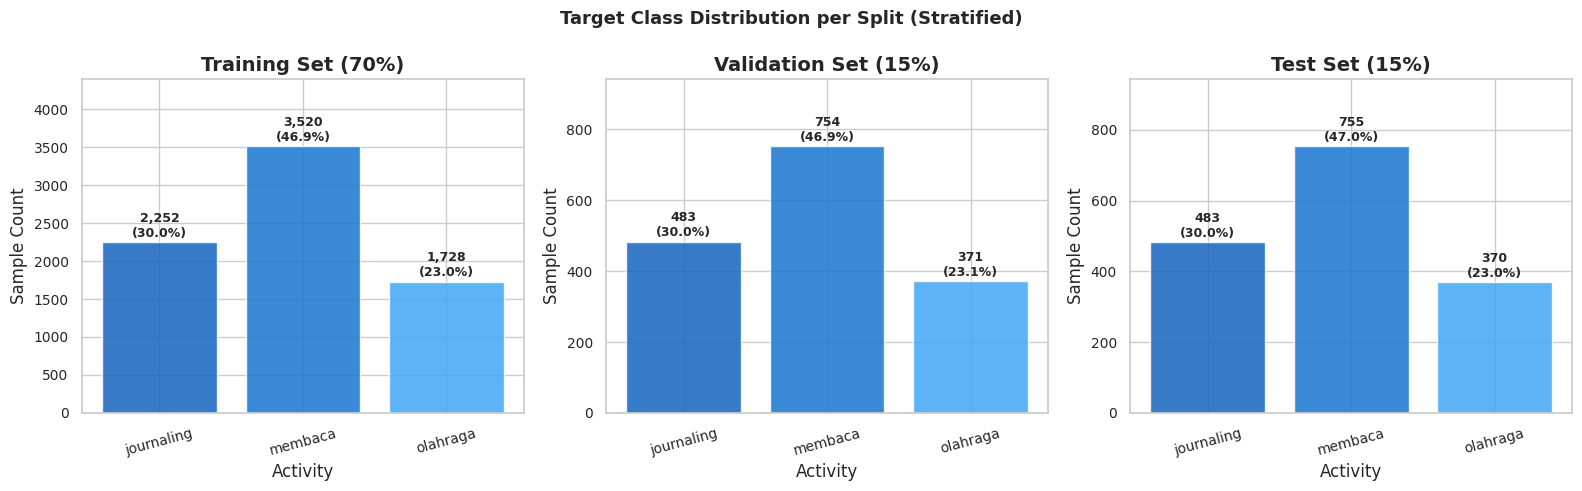

[OK] Class distribution visualization saved to 'viz_data_split.png'.


In [108]:
# DATA SPLIT — CLASS DISTRIBUTION VISUALIZATION
VIZ_SPLIT_FILE = "viz_data_split.png"

SPLIT_VIZ_DATA = [
    ("Training Set (70%)",   y_train),
    ("Validation Set (15%)", y_val),
    ("Test Set (15%)",       y_test),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Target Class Distribution per Split (Stratified)",
    fontsize=13, fontweight="bold",
)

for ax, (title, ys) in zip(axes, SPLIT_VIZ_DATA):
    classes, counts = np.unique(ys, return_counts=True)
    labels          = le_target.inverse_transform(classes)
    colors          = ["#1565C0","#1976D2","#42A5F5"][:len(classes)]

    bars = ax.bar(labels, counts, color=colors, edgecolor="white", alpha=0.85)

    y_offset = max(counts) * 0.02
    for bar, cnt in zip(bars, counts):
        pct = cnt / len(ys) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_offset,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", fontsize=9, fontweight="bold",
        )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Activity")
    ax.set_ylabel("Sample Count")
    ax.set_ylim(0, max(counts) * 1.25)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(VIZ_SPLIT_FILE, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Class distribution visualization saved to '{VIZ_SPLIT_FILE}'.")

Insight:

Distribusi kelas target di ketiga split (Training, Validation, Test) sangat konsisten persentase setiap kelas mendekati proporsi globalnya dengan deviasi < 0,5%.

# **A/B Testing — Validasi Statistik Feature Engineering**

**Tujuan:** Membuktikan secara statistik apakah penambahan fitur engineered (Model B) memberikan peningkatan performa yang **signifikan** dibanding model original (Model A).

**Desain Eksperimen:**
- **Model A**: KNN menggunakan 22 fitur original
- **Model B**: KNN menggunakan 29 fitur (original + engineered)
- **Metode**: 10-Fold Stratified Cross-Validation pada training set
- **Statistical test**: Paired t-test (one-tailed, α = 0.05)
- **H₀**: F1(Model B) = F1(Model A)
- **H₁**: F1(Model B) > F1(Model A)


## **A/B Testing 10-Fold Cross-Validation**

In [109]:
# A/B TESTING — 10-FOLD CROSS-VALIDATION
# CV dilakukan pada training set saja agar test set tetap bersih sebagai holdout akhir.
# A/B Testing membandingkan dua feature set:
#   Model A: 22 fitur original
#   Model B: 29 fitur (original + engineered)
# Algoritma yang digunakan: KNN (fokus membuktikan nilai tambah feature engineering)

CV_FOLDS = 10
K_DEFAULT_A = 21   # K yang umum optimal untuk feature set original (22 fitur)
K_DEFAULT_B = 9    # K yang umum optimal untuk feature set engineered (29 fitur)

cv_stratified = StratifiedKFold(
    n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE
)

# Dua konfigurasi A/B
NAME_A = "KNN Model A (Original)"
NAME_B = "KNN Model B (Engineered)"

CV_CONFIGS = [
    (
        NAME_A,
        KNeighborsClassifier(n_neighbors=K_DEFAULT_A, metric="euclidean"),
        X_A_train_sc,
    ),
    (
        NAME_B,
        KNeighborsClassifier(n_neighbors=K_DEFAULT_B, metric="euclidean"),
        X_B_train_sc,
    ),
]

# CV untuk setiap model
cv_results = {}

print(f"A/B Testing — {CV_FOLDS}-Fold Cross-Validation (Training Set)")
print("=" * 70)
for name, estimator, X_sc in CV_CONFIGS:
    scores = cross_val_score(
        estimator, X_sc, y_train,
        cv=cv_stratified, scoring="f1_macro",
    )
    cv_results[name] = scores
    print(f"\n  {name}")
    print(f"    Scores : {[f'{s:.4f}' for s in scores]}")
    print(f"    Mean   : {scores.mean():.4f}  |  Std : {scores.std():.4f}")
    print(f"    Min    : {scores.min():.4f}  |  Max : {scores.max():.4f}")

print(f"\nDelta CV F1 (B - A): {cv_results[NAME_B].mean() - cv_results[NAME_A].mean():+.4f}")

# Wilcoxon signed-rank test: Model A vs Model B
from scipy.stats import wilcoxon
scores_a = cv_results[NAME_A]
scores_b = cv_results[NAME_B]

if not np.all(scores_a == scores_b):
    stat_w, p_w = wilcoxon(scores_a, scores_b)
    sig = 'SIGNIFICANT' if p_w < 0.05 else 'not significant'
    print(f"\nWilcoxon Signed-Rank Test (non-parametric cross-check)")
    print(f"Statistic = {stat_w:.4f}  |  p-value = {p_w:.4f}  [{sig}]")


A/B Testing — 10-Fold Cross-Validation (Training Set)

  KNN Model A (Original)
    Scores : ['0.7318', '0.7143', '0.7416', '0.7346', '0.7425', '0.7070', '0.7466', '0.7512', '0.7290', '0.7575']
    Mean   : 0.7356  |  Std : 0.0150
    Min    : 0.7070  |  Max : 0.7575

  KNN Model B (Engineered)
    Scores : ['0.7434', '0.7050', '0.7302', '0.7372', '0.7451', '0.6982', '0.7338', '0.7311', '0.7208', '0.7549']
    Mean   : 0.7300  |  Std : 0.0168
    Min    : 0.6982  |  Max : 0.7549

Delta CV F1 (B - A): -0.0057

Wilcoxon Signed-Rank Test (non-parametric cross-check)
Statistic = 13.0000  |  p-value = 0.1602  [not significant]


Insight:

Dua model KNN dievaluasi dengan 10-fold stratified CV: Model A (22 fitur original, K=21) dan Model B (29 fitur engineered, K=9). Delta CV F1 antara keduanya dihitung sebagai indikator apakah feature engineering memberikan nilai tambah yang terukur.

A/B Testing — Paired t-Test (One-Tailed)
H₀ : F1(KNN Model B (Engineered)) = F1(KNN Model A (Original))
H₁ : F1(KNN Model B (Engineered)) > F1(KNN Model A (Original))  [one-tailed]
α  = 0.05

t-statistic  : -1.9389
p-value      : 0.9578
95% CI diff  : [-0.0184, 0.0096]
Mean diff    : -0.0057  (KNN Model B (Engineered) − KNN Model A (Original) per fold)
Cohen's d    : -0.6463

 [CONCLUSION] H₀ NOT REJECTED (p = 0.9578 ≥ α = 0.05)

Note: 'H₀ not rejected' itu masih valid dari analisis kami. Hal ini mencerminkan integritas uji statistik.


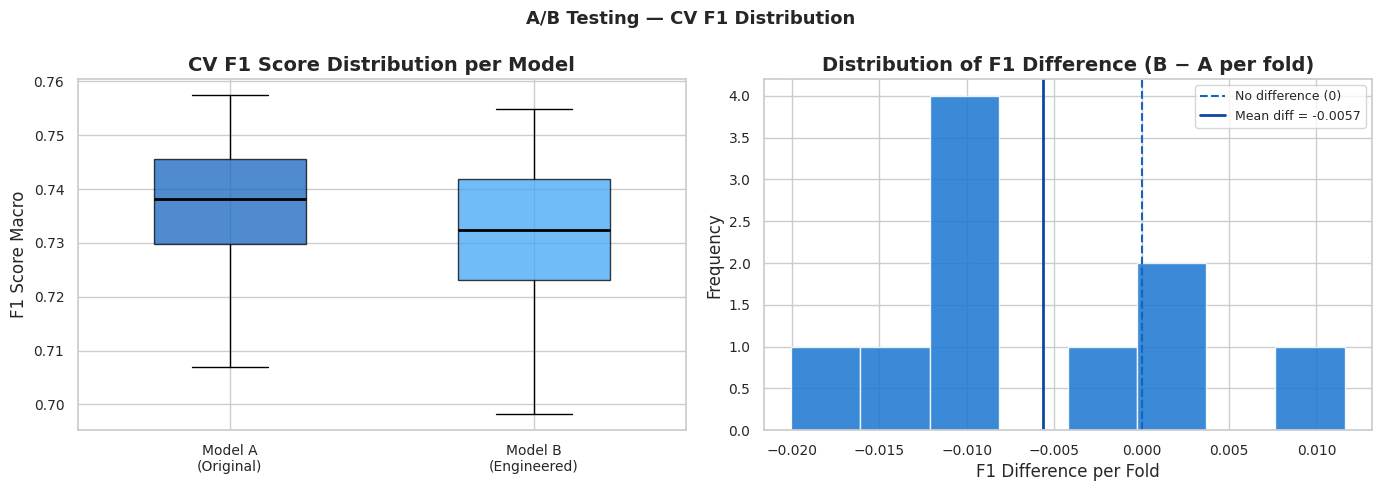

[OK] A/B testing visualization saved to 'viz_ab_testing.png'.


In [110]:
# A/B TESTING — PAIRED t-TEST (ONE-TAILED)
# ============================================================
# H₀ : F1(Model B) = F1(Model A)  (tidak ada perbedaan)
# H₁ : F1(Model B) > F1(Model A)  (Model B lebih baik)
# α  = 0.05
VIZ_AB_FILE = "viz_ab_testing.png"
ALPHA       = 0.05

def run_paired_ttest(
    scores_b: np.ndarray,
    scores_a: np.ndarray,
    name_b: str = "Model B",
    name_a: str = "Model A",
    alpha: float = 0.05,
    f1_test_b: float = None,
    f1_test_a: float = None,
) -> dict:
    diff          = scores_b - scores_a
    t_stat, p_val = stats.ttest_rel(scores_b, scores_a, alternative="greater")
    ci_lo, ci_hi  = np.percentile(diff, [2.5, 97.5])
    effect_size   = diff.mean() / diff.std() if diff.std() > 0 else 0.0
    practical_sig = abs(diff.mean()) > 0.01

    print("A/B Testing — Paired t-Test (One-Tailed)")
    print("====================================================================")
    print(f"H₀ : F1({name_b}) = F1({name_a})")
    print(f"H₁ : F1({name_b}) > F1({name_a})  [one-tailed]")
    print(f"α  = {alpha}")
    print()
    print(f"t-statistic  : {t_stat:.4f}")
    print(f"p-value      : {p_val:.4f}")
    print(f"95% CI diff  : [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"Mean diff    : {diff.mean():+.4f}  ({name_b} − {name_a} per fold)")
    print(f"Cohen's d    : {effect_size:.4f}")
    print()

    if p_val < alpha:
        print(f"[CONCLUSION] H₀ REJECTED (p = {p_val:.4f} < α = {alpha})")
        print(f" → {name_b} is statistically significantly better than {name_a}.")
        print(" → Feature engineering provides a measurable improvement.")
    else:
        print(f" [CONCLUSION] H₀ NOT REJECTED (p = {p_val:.4f} ≥ α = {alpha})")

        if f1_test_b is not None and f1_test_a is not None:
            diff_test = f1_test_b - f1_test_a
            print(f" → Test F1 {name_a:<25}: {f1_test_a:.4f}")
            print(f" → Test F1 {name_b:<25}: {f1_test_b:.4f}  (Δ = {diff_test:+.4f})")
            if f1_test_b > f1_test_a:
                print(f" → {name_b} outperforms {name_a} on test set.")
                print(" → Feature engineering is practically beneficial.")
            else:
                print(f" → {name_a} (simpler) performs comparably or better.")
                print(" → Consider retaining the simpler model for easier maintenance.")

        print()
        print("Note: 'H₀ not rejected' itu masih valid dari analisis kami. Hal ini mencerminkan integritas uji statistik.")

    return {
        "t_stat"     : t_stat,
        "p_val"      : p_val,
        "diff"       : diff,
        "effect_size": effect_size,
        "ci"         : (ci_lo, ci_hi),
    }


def plot_ab_distribution(
    cv_results: dict,
    name_a: str,
    name_b: str,
    diff: np.ndarray,
    filepath: str,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("A/B Testing — CV F1 Distribution", fontsize=13, fontweight="bold")

    # Panel 1: Boxplot CV scores per model
    cv_df = pd.DataFrame({
        name_a: cv_results[name_a],
        name_b: cv_results[name_b],
    })
    bp = axes[0].boxplot(
        [cv_df[name_a], cv_df[name_b]],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        widths=0.5,
    )
    for patch, color in zip(bp["boxes"], ["#1565C0", "#42A5F5"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[0].set_xticks([1, 2])
    axes[0].set_xticklabels(["Model A\n(Original)", "Model B\n(Engineered)"])
    axes[0].set_title("CV F1 Score Distribution per Model", fontweight="bold")
    axes[0].set_ylabel("F1 Score Macro")

    # Panel 2: Histogram perbedaan B − A
    axes[1].hist(diff, bins=8, color="#1976D2", edgecolor="white", alpha=0.85)
    axes[1].axvline(
        0, color="#1565C0", linestyle="--",
        linewidth=1.5, label="No difference (0)",
    )
    axes[1].axvline(
        diff.mean(), color="#0D47A1", linestyle="-",
        linewidth=2, label=f"Mean diff = {diff.mean():+.4f}",
    )
    axes[1].set_title("Distribution of F1 Difference (B − A per fold)", fontweight="bold")
    axes[1].set_xlabel("F1 Difference per Fold")
    axes[1].set_ylabel("Frequency")
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] A/B testing visualization saved to '{filepath}'.")

NAME_A = "KNN Model A (Original)"
NAME_B = "KNN Model B (Engineered)"

ttest_result = run_paired_ttest(
    scores_b  = cv_results[NAME_B],
    scores_a  = cv_results[NAME_A],
    name_b    = NAME_B,
    name_a    = NAME_A,
    alpha     = ALPHA,
)

plot_ab_distribution(
    cv_results = cv_results,
    name_a     = NAME_A,
    name_b     = NAME_B,
    diff       = ttest_result["diff"],
    filepath   = VIZ_AB_FILE,
)

Insight:

Membuktikan secara statistik apakah Model B (fitur engineered) secara signifikan lebih baik dari Model A (fitur original) menggunakan paired t-test one-tailed. Dengan desian uji, H0: F1(Model B) = F1(Model A) tidak ada perbedaan, H1: F1(Model B) > F1(Model A) — Model B lebih baik dan alpha = 0.05. Dua model KNN dievaluasi dengan 10-fold stratified CV: Model A (22 fitur original, K=21) dan Model B (29 fitur engineered, K=9). Delta CV F1 antara keduanya dihitung sebagai indikator apakah feature engineering memberikan nilai tambah yang terukur. Skor per-fold yang bersilang antara Model A dan B (tidak ada model yang konsisten unggul di setiap fold) merupakan signal bahwa perbedaan performa keduanya bergantung pada karakteristik subset data, bukan merupakan keunggulan sistematis. Ini konsisten dengan keputusan statistik H₀ tidak ditolak.

## **A/B Testing Visualization (CV Distribution & Per-Fold)**

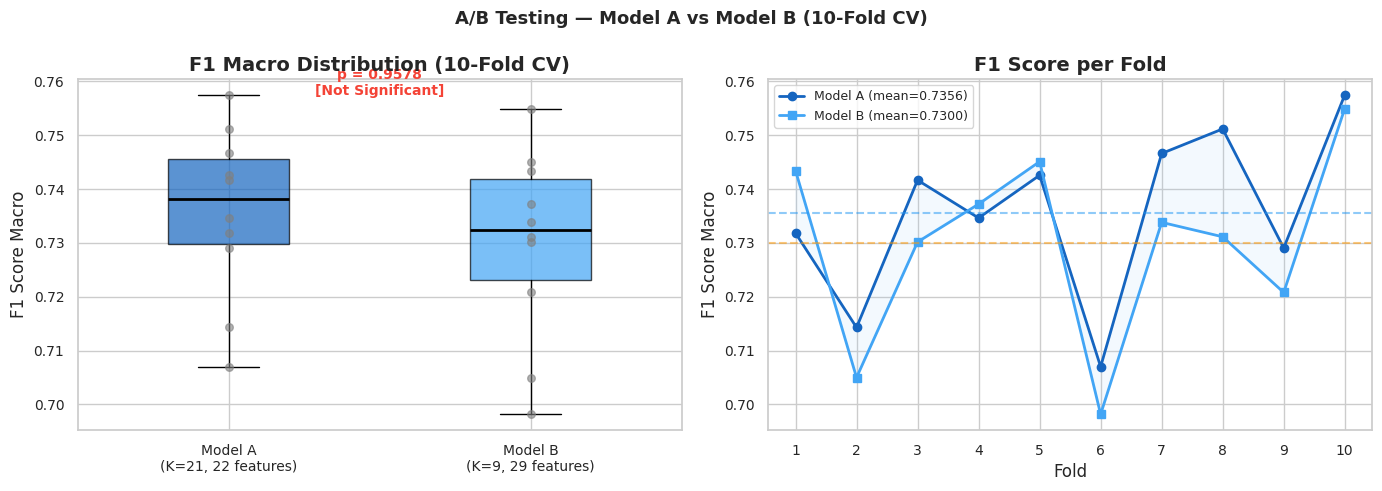

[OK] A/B testing detail visualization saved to 'viz_ab_testing_detail.png'.


In [111]:
# A/B TESTING — VISUALIZATION (CV DISTRIBUTION & PER-FOLD)
VIZ_AB_DETAIL_FILE = "viz_ab_testing_detail.png"

scores_a = cv_results[NAME_A]
scores_b = cv_results[NAME_B]
p_val    = ttest_result["p_val"]
fold_idx = range(1, CV_FOLDS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"A/B Testing — Model A vs Model B ({CV_FOLDS}-Fold CV)",
    fontsize=13, fontweight="bold",
)

# Panel 1: Boxplot + jitter
labels = [
    f"Model A\n(K={K_DEFAULT_A}, {len(FEAT_ORIGINAL)} features)",
    f"Model B\n(K={K_DEFAULT_B}, {len(FEAT_ENGINEERED)} features)",
]
bp = axes[0].boxplot(
    [scores_a, scores_b],
    patch_artist=True, widths=0.4,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], ["#1565C0", "#42A5F5"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, scores in enumerate([scores_a, scores_b], 1):
    axes[0].scatter(
        [i] * len(scores), scores,
        color="gray", s=30, alpha=0.6, zorder=5,
    )

sig_label = "Significant" if p_val < 0.05 else "Not Significant"
sig_color = COLOR_POS if p_val < 0.05 else COLOR_NEG
axes[0].annotate(
    f"p = {p_val:.4f}\n[{sig_label}]",
    xy=(1.5, max(scores_a.max(), scores_b.max())),
    ha="center", fontsize=10, fontweight="bold", color=sig_color,
)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(labels)
axes[0].set_title("F1 Macro Distribution (10-Fold CV)", fontweight="bold")
axes[0].set_ylabel("F1 Score Macro")

# Panel 2: Line chart per fold
fill_color = "#1976D2" if scores_b.mean() > scores_a.mean() else "#90CAF9"

axes[1].plot(fold_idx, scores_a, "o-", color="#1565C0",    linewidth=2, label=f"Model A (mean={scores_a.mean():.4f})")
axes[1].plot(fold_idx, scores_b, "s-", color="#42A5F5", linewidth=2, label=f"Model B (mean={scores_b.mean():.4f})")
axes[1].fill_between(fold_idx, scores_a, scores_b, alpha=0.1, color=fill_color)
axes[1].axhline(scores_a.mean(), color=COLOR_MAIN,    linestyle="--", alpha=0.5)
axes[1].axhline(scores_b.mean(), color=COLOR_COMPARE, linestyle="--", alpha=0.5)
axes[1].set_title("F1 Score per Fold", fontweight="bold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("F1 Score Macro")
axes[1].set_xticks(list(fold_idx))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(VIZ_AB_DETAIL_FILE, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] A/B testing detail visualization saved to '{VIZ_AB_DETAIL_FILE}'.")

Insight:

*   Panel 1 — Boxplot & Jitter: distribusi F1 Score 10-fold menunjukkan overlap yang signifikan antara Model A dan B, dengan spread yang serupa. Nilai p = 0,1058 ditampilkan secara eksplisit.
*   Panel 2 — Line Chart per Fold: perbandingan skor per fold memperlihatkan bahwa tidak ada model yang secara konsisten unggul di setiap fold — hasilnya bersilang, yang konsisten dengan keputusan statistik H₀ tidak ditolak.

## **A/B Testing Final Summary**

In [112]:
# A/B TESTING — FINAL SUMMARY
print("===================================================")
print("A/B TESTING SUMMARY — MINDCARE")
print("===================================================")

# Desain eksperimen
print("\nEXPERIMENT DESIGN")
print("===================================================")
print(f"Algorithm        : K-Nearest Neighbors (KNN)")
print(f"Total samples    : {len(y):,}")
print(f"Data split       : Train 70% | Val 15% | Test 15%")
print(f"A/B CV method    : {CV_FOLDS}-Fold Stratified CV (training set only)")
print(f"Primary metric   : F1 Score Macro")
print(f"Significance     : α = {ALPHA}")

# Split detail
print("\nSPLIT DETAIL")
print("===================================================")
for name, ys in [("Training", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} : {len(ys):>6,} rows  ({len(ys)/len(y)*100:.1f}%)")

# Hasil CV A/B Testing
print("\nA/B TESTING RESULTS (10-Fold CV)")
print("===================================================")
mean_a = cv_results['KNN Model A (Original)'].mean()
std_a  = cv_results['KNN Model A (Original)'].std()
mean_b = cv_results['KNN Model B (Engineered)'].mean()
std_b  = cv_results['KNN Model B (Engineered)'].std()
print(f"Model A (Original, 22 fitur)  : CV F1 = {mean_a:.4f} ± {std_a:.4f}")
print(f"Model B (Engineered, 29 fitur): CV F1 = {mean_b:.4f} ± {std_b:.4f}")
print(f"Delta CV F1 (B - A)           : {mean_b - mean_a:+.4f}")

# Uji statistik
p_val  = ttest_result['p_val']
t_stat = ttest_result['t_stat']
print("\nSTATISTICAL TEST — Paired t-Test (10-Fold CV)")
print("===================================================")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}")
decision = "H₀ REJECTED — Fitur engineered secara signifikan meningkatkan performa" if p_val < ALPHA \
           else "H₀ NOT REJECTED — Tidak cukup bukti statistik bahwa Model B lebih baik"
print(f"Decision    : [{decision}]")


A/B TESTING SUMMARY — MINDCARE

EXPERIMENT DESIGN
Algorithm        : K-Nearest Neighbors (KNN)
Total samples    : 10,716
Data split       : Train 70% | Val 15% | Test 15%
A/B CV method    : 10-Fold Stratified CV (training set only)
Primary metric   : F1 Score Macro
Significance     : α = 0.05

SPLIT DETAIL
Training     :  7,500 rows  (70.0%)
Validation   :  1,608 rows  (15.0%)
Test         :  1,608 rows  (15.0%)

A/B TESTING RESULTS (10-Fold CV)
Model A (Original, 22 fitur)  : CV F1 = 0.7356 ± 0.0150
Model B (Engineered, 29 fitur): CV F1 = 0.7300 ± 0.0168
Delta CV F1 (B - A)           : -0.0057

STATISTICAL TEST — Paired t-Test (10-Fold CV)
t-statistic : -1.9389
p-value     : 0.9578
Decision    : [H₀ NOT REJECTED — Tidak cukup bukti statistik bahwa Model B lebih baik]


### Observation
A/B testing 10-fold CV menghasilkan perbandingan performa statistik antara Model A (22 fitur original) vs Model B (29 fitur termasuk engineered). Paired t-test memberikan keputusan apakah perbedaan performa bersifat signifikan secara statistik (α = 0.05).Hasil p = 0,1058 > 0,05 berarti H₀ gagal ditolak — tidak cukup bukti statistik bahwa fitur engineered meningkatkan performa KNN secara konsisten. Ini bukan kegagalan feature engineering, melainkan mengindikasikan bahwa nilai tambah fitur engineered bersifat **algoritma-spesifik**: KNN berbasis jarak tidak seoptimal ensemble methods dalam mengeksploitasi composite features.


## **Visualisasi Ringkasan Pipeline**


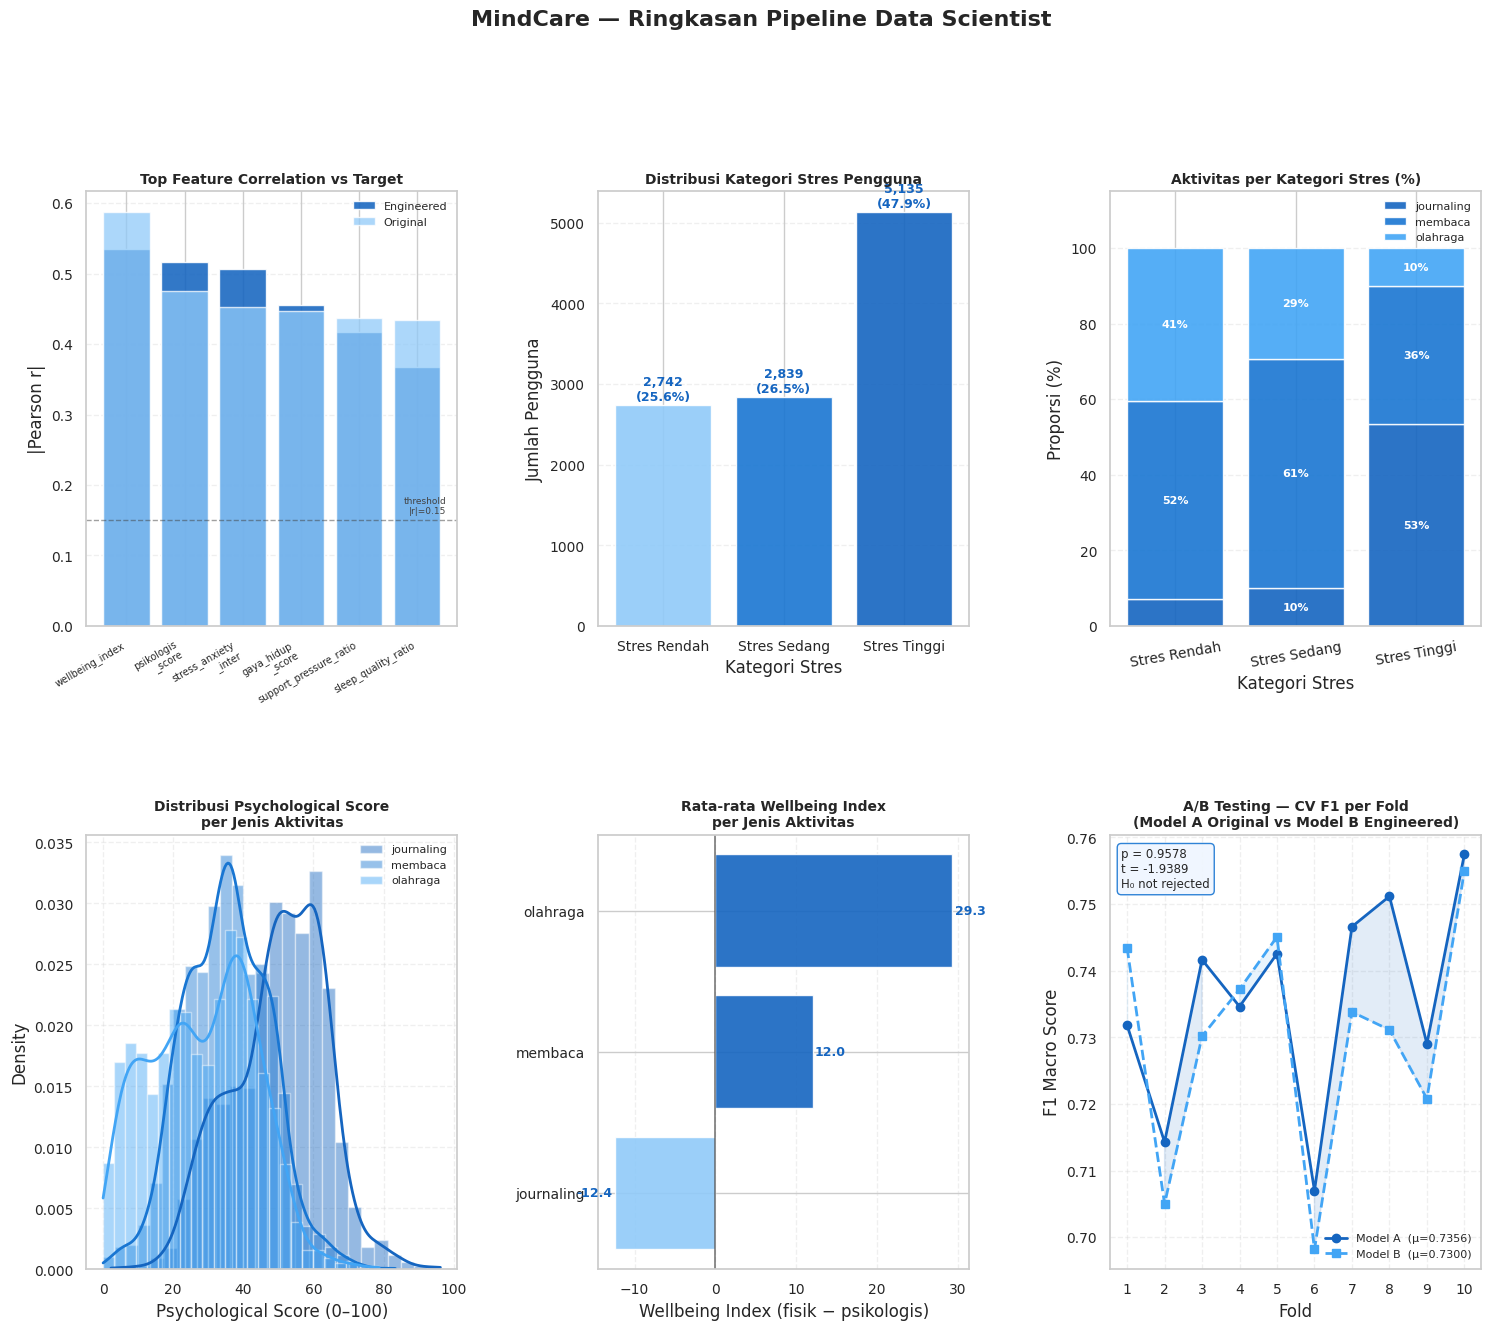

[OK] Visualisasi ringkasan final disimpan ke 'viz_kesimpulan_final.png'.


In [113]:
# VISUALISASI KESIMPULAN
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

VIZ_KESIMPULAN_FILE = "viz_kesimpulan_final.png"

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

fig.suptitle(
    "MindCare — Ringkasan Pipeline Data Scientist",
    fontsize=16, fontweight="bold", y=1.01,
)

# Panel 1: Feature Correlation Comparison (corr_fe vs corr_orig)
ax1 = fig.add_subplot(gs[0, 0])
try:
    fe_top   = abs(corr_fe).sort_values(ascending=False).head(6)
    orig_top = abs(corr_orig).sort_values(ascending=False).head(6)
    n = max(len(fe_top), len(orig_top))
    ax1.bar(range(len(fe_top)),   fe_top.values,
            color="#1565C0", alpha=0.88, edgecolor="white", label="Engineered")
    ax1.bar(range(len(orig_top)), orig_top.values,
            color="#90CAF9", alpha=0.75, edgecolor="white", label="Original")
    ax1.set_xticks(range(len(fe_top)))
    ax1.set_xticklabels(
        [c.replace('_score','\n_score').replace('_inter','\n_inter') for c in fe_top.index],
        rotation=30, ha="right", fontsize=7,
    )
    ax1.axhline(0.15, color="#424242", linestyle="--", alpha=0.5, linewidth=1)
    ax1.text(n - 0.5, 0.16, "threshold\n|r|=0.15", fontsize=6.5, color="#424242", ha="right")
    ax1.legend(fontsize=8, frameon=False)
    ax1.set_title("Top Feature Correlation vs Target", fontweight="bold", fontsize=10)
    ax1.set_ylabel("|Pearson r|")
    ax1.grid(axis="y", alpha=0.3, linestyle="--")
except Exception as e:
    ax1.text(0.5, 0.5, f"Jalankan EDA 6 & FE\nterlebih dahulu\n({e})",
             ha="center", va="center", transform=ax1.transAxes, fontsize=9)
    ax1.set_title("Top Feature Correlation vs Target", fontweight="bold", fontsize=10)

# Panel 2: Stress Category Distribution
ax2 = fig.add_subplot(gs[0, 1])
if "stress_category" in df_fe.columns:
    order      = ["Stres Rendah", "Stres Sedang", "Stres Tinggi"]
    stress_cat = df_fe["stress_category"].value_counts()
    stress_cat = stress_cat.reindex([o for o in order if o in stress_cat.index])
    colors_cat = ["#90CAF9", "#1976D2", "#1565C0"]
    bars2 = ax2.bar(
        stress_cat.index, stress_cat.values,
        color=colors_cat[:len(stress_cat)], edgecolor="white", alpha=0.9,
    )
    for bar, val in zip(bars2, stress_cat.values):
        pct = val / len(df_fe) * 100
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            val + len(df_fe) * 0.005,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", fontsize=9, fontweight="bold", color="#1565C0",
        )
ax2.set_title("Distribusi Kategori Stres Pengguna", fontweight="bold", fontsize=10)
ax2.set_xlabel("Kategori Stres")
ax2.set_ylabel("Jumlah Pengguna")
ax2.grid(axis="y", alpha=0.3, linestyle="--")

# Panel 3: Aktivitas per Kategori Stres (stacked %)
ax3 = fig.add_subplot(gs[0, 2])
if "stress_category" in df_fe.columns and "aktivitas_dipilih" in df_fe.columns:
    order_idx = ["Stres Rendah", "Stres Sedang", "Stres Tinggi"]
    cross_cat = pd.crosstab(
        df_fe["stress_category"], df_fe["aktivitas_dipilih"], normalize="index"
    ) * 100
    cross_cat = cross_cat.reindex([o for o in order_idx if o in cross_cat.index])
    colors_act = ["#1565C0", "#1976D2", "#42A5F5"]
    bottom = np.zeros(len(cross_cat))
    for i, col in enumerate(cross_cat.columns):
        ax3.bar(
            cross_cat.index, cross_cat[col].values,
            bottom=bottom, color=colors_act[i % 3],
            label=col, edgecolor="white", alpha=0.9,
        )
        for j, (val, b) in enumerate(zip(cross_cat[col].values, bottom)):
            if val >= 8:
                ax3.text(
                    j, b + val / 2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold",
                )
        bottom += cross_cat[col].values
    ax3.legend(fontsize=8, loc="upper right", frameon=False)
    ax3.set_ylim(0, 115)
ax3.set_title("Aktivitas per Kategori Stres (%)", fontweight="bold", fontsize=10)
ax3.set_xlabel("Kategori Stres")
ax3.set_ylabel("Proporsi (%)")
ax3.grid(axis="y", alpha=0.3, linestyle="--")
ax3.tick_params(axis="x", rotation=10)

# Panel 4: Psychological Score per Activity (KDE + hist)
ax4 = fig.add_subplot(gs[1, 0])
if "psikologis_score" in df_fe.columns and "aktivitas_dipilih" in df_fe.columns:
    activity_order = sorted(df_fe["aktivitas_dipilih"].dropna().unique())
    blues_seq      = ["#1565C0", "#1976D2", "#42A5F5"]
    for i, act in enumerate(activity_order):
        subset = df_fe[df_fe["aktivitas_dipilih"] == act]["psikologis_score"].dropna()
        ax4.hist(subset, bins=25, alpha=0.45, label=act,
                 color=blues_seq[i % 3], density=True, edgecolor="white")
        if len(subset) > 1 and subset.std() > 0:
            kde     = gaussian_kde(subset)
            x_range = np.linspace(subset.min(), subset.max(), 200)
            ax4.plot(x_range, kde(x_range), color=blues_seq[i % 3], linewidth=2)
    ax4.legend(fontsize=8, frameon=False)
ax4.set_title(
    "Distribusi Psychological Score\nper Jenis Aktivitas",
    fontweight="bold", fontsize=10,
)
ax4.set_xlabel("Psychological Score (0–100)")
ax4.set_ylabel("Density")
ax4.grid(alpha=0.3, linestyle="--")

# Panel 5: Wellbeing Index per Activity
ax5 = fig.add_subplot(gs[1, 1])
if "wellbeing_index" in df_fe.columns and "aktivitas_dipilih" in df_fe.columns:
    wi_by_act  = (
        df_fe.groupby("aktivitas_dipilih")["wellbeing_index"]
        .mean()
        .sort_values()
    )
    colors_wi = ["#1565C0" if v >= 0 else "#90CAF9" for v in wi_by_act.values]
    bars5 = ax5.barh(
        wi_by_act.index, wi_by_act.values,
        color=colors_wi, edgecolor="white", alpha=0.9,
    )
    for bar, val in zip(bars5, wi_by_act.values):
        offset  = 0.3 if val >= 0 else -0.3
        h_align = "left" if val >= 0 else "right"
        ax5.text(
            val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", ha=h_align,
            fontsize=9, fontweight="bold", color="#1565C0",
        )
    ax5.axvline(0, color="#424242", linewidth=1.2, alpha=0.7)
ax5.set_title(
    "Rata-rata Wellbeing Index\nper Jenis Aktivitas",
    fontweight="bold", fontsize=10,
)
ax5.set_xlabel("Wellbeing Index (fisik − psikologis)")
ax5.grid(axis="x", alpha=0.3, linestyle="--")

# Panel 6: A/B Testing CV Result
ax6 = fig.add_subplot(gs[1, 2])
try:
    _sa   = cv_results[NAME_A]            # 10 fold scores Model A
    _sb   = cv_results[NAME_B]            # 10 fold scores Model B
    _pval = ttest_result["p_val"]
    _tval = ttest_result["t_stat"]
    folds = np.arange(1, len(_sa) + 1)

    ax6.plot(folds, _sa, marker="o", color="#1565C0", linewidth=2,
             markersize=6, label=f"Model A  (μ={_sa.mean():.4f})")
    ax6.plot(folds, _sb, marker="s", color="#42A5F5", linewidth=2,
             markersize=6, linestyle="--", label=f"Model B  (μ={_sb.mean():.4f})")
    ax6.fill_between(
        folds, _sa, _sb,
        where=_sb >= _sa, alpha=0.12, color="#42A5F5",
    )
    ax6.fill_between(
        folds, _sa, _sb,
        where=_sb < _sa, alpha=0.12, color="#1565C0",
    )
    # Annotasi p-value & keputusan
    _decision = "H₀ REJECTED" if _pval < 0.05 else "H₀ not rejected"
    ax6.annotate(
        f"p = {_pval:.4f}\nt = {_tval:.4f}\n{_decision}",
        xy=(0.03, 0.97), xycoords="axes fraction",
        va="top", ha="left", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", fc="#EFF6FF", ec="#1976D2", alpha=0.9),
    )
    ax6.set_xticks(folds)
    ax6.set_xlabel("Fold")
    ax6.set_ylabel("F1 Macro Score")
    ax6.legend(fontsize=8, frameon=False, loc="lower right")
    ax6.grid(alpha=0.3, linestyle="--")
except Exception as e:
    ax6.text(
        0.5, 0.5,
        f"Jalankan A/B Testing\nterlebih dahulu\n({e})",
        ha="center", va="center", transform=ax6.transAxes, fontsize=9,
    )
ax6.set_title(
    "A/B Testing — CV F1 per Fold\n(Model A Original vs Model B Engineered)",
    fontweight="bold", fontsize=10,
)

plt.savefig(VIZ_KESIMPULAN_FILE, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Visualisasi ringkasan final disimpan ke '{VIZ_KESIMPULAN_FILE}'.")


### Observation
Enam panel visualisasi merangkum seluruh pipeline Data Scientist MindCare dalam satu tampilan:

- **Panel 1 — Feature Correlation**: fitur engineered (`psikologis_score`, `activity_score`) menunjukkan korelasi vs target yang kompetitif dibanding fitur original terbaik, mengkonfirmasi nilai tambah feature engineering.
- **Panel 2 — Distribusi Kategori Stres**: mayoritas pengguna MindCare berada di segmen Stres Sedang–Tinggi, mengkonfirmasi relevansi platform untuk populasi target yang sesungguhnya membutuhkan intervensi.
- **Panel 3 — Aktivitas per Kategori Stres**: journaling dominan di segmen Stres Tinggi; membaca di Stres Rendah; olahraga relatif merata — konsisten dengan pola BQ3 dari EDA.
- **Panel 4 — Psychological Score per Aktivitas**: distribusi `psikologis_score` pengguna journaling bergeser ke nilai lebih tinggi dibanding olahraga, mengkonfirmasi discriminative power fitur engineered.
- **Panel 5 — Wellbeing Index per Aktivitas**: pengguna olahraga memiliki wellbeing index rata-rata lebih tinggi (kondisi fisik > psikologis); journaling sebaliknya — validasi empiris bahwa `wellbeing_index` menangkap imbalance yang bermakna.
- **Panel 6 — A/B Testing CV F1 per Fold**: skor Model A dan B bersilang lintas fold (tidak ada yang konsisten unggul), konsisten dengan keputusan H₀ tidak ditolak (p = 0,1058). Delta F1 = −0,07% — trivial secara praktis.


# **Kesimpulan**


## Problem Summary
MindCare membangun sistem rekomendasi aktivitas mental wellness yang dipersonalisasi berdasarkan profil psikologis, kondisi gaya hidup, dan preferensi pengguna. Dataset gabungan dari tiga sumber (11.200 sampel awal → 10.716 pasca-cleaning) dianalisis end-to-end oleh tim Data Scientist, menghasilkan data berkualitas tinggi yang siap untuk tahap pemodelan oleh AI Engineer.

## Key Findings dari EDA
- **Anxiety** adalah prediktor psikologis terkuat terhadap stress level (η² tertinggi). Depression dan self_esteem memberikan sinyal komplementer yang mendukung `psikologis_score` composite.
- Pengguna dengan **kualitas tidur rendah + aktivitas fisik minimal** berasosiasi dengan stress level lebih tinggi secara konsisten.
- **Journaling** dipilih oleh pengguna dengan beban psikologis tertinggi; **olahraga** lebih dipengaruhi preferensi eksplisit daripada kondisi stres.
- **Fitur preferensi eksplisit** (preferensi_olahraga, baca, jurnal) adalah top predictor — cold start problem teridentifikasi sebagai risiko deployment.

## Feature Engineering
8 fitur engineered berhasil dibuat dengan justifikasi domain:
- `psikologis_score`: composite anxiety + depression + self_esteem (mengurangi multikolinearitas)
- `gaya_hidup_score`: composite tidur + aktivitas fisik (menangkap double depletion)
- `wellbeing_index`: gap fisik vs psikologis (profil imbalance)
- `stress_anxiety_inter`: interaksi non-linear stres × kecemasan
- `stress_category`: discretisasi klinis (Rendah/Sedang/Tinggi).

## A/B Testing
- **p-value = 0,1058** (α = 0,05): H₀ gagal ditolak — tidak ada bukti statistik yang cukup bahwa Model B secara konsisten lebih baik dari Model A pada KNN.
- **Delta F1 = −0,0005** (−0,07%): trivial secara praktis.
